# DATATHON 2026: THE GRIDBREAKERS FINAL NOTEBOOK

## Mục tiêu

Notebook này kết hợp 4 hướng làm việc:

- `iykyk.ipynb`: khung EDA/report chính.
- `eogibiti.ipynb`: KPI Revenue + forecasting chính.
- `gridbreakers-data-to-dollars-eda-forecast.ipynb`: ý tưởng EDA nâng cao.
- `datathon-2026-preliminary-round.ipynb`: baseline forecasting để so sánh.

Flow cuối cùng:

1. Load data và tạo master table.
2. Tái cấu trúc Revenue từ giao dịch.
3. Phân tích Revenue trend và seasonality.
4. Phân tích product/category/brand portfolio.
5. Phân tích các driver: promotion, returns, customer/region, inventory, web traffic.
6. Forecasting Revenue/COGS có validation theo thời gian.
7. Feature importance và business recommendations.

## 1. Load data & create master table

Cell này tự tìm thư mục dataset trong Kaggle, đọc toàn bộ file `.csv`, parse các cột ngày, tạo `brand`, và xây `master table` an toàn để tránh lỗi trùng cột `zip`.

In [24]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
pd.set_option("display.expand_frame_repr", False)


# =========================
# 1. Tìm đúng DATA_DIR
# =========================
def find_data_dir(required_files=("orders.csv", "order_items.csv", "products.csv", "sales.csv")):
    for root, dirs, files in os.walk("/kaggle/input"):
        if all(f in files for f in required_files):
            return root
    raise FileNotFoundError("Không tìm thấy thư mục chứa đủ các file cần thiết trong /kaggle/input")


DATA_DIR = find_data_dir()
print("DATA_DIR:", DATA_DIR)


# =========================
# 2. Hàm giảm RAM
# =========================
def reduce_mem_usage(df):
    for col in df.columns:
        col_type = df[col].dtype

        if pd.api.types.is_datetime64_any_dtype(col_type):
            continue

        if pd.api.types.is_numeric_dtype(col_type):
            c_min = df[col].min()
            c_max = df[col].max()

            if pd.api.types.is_integer_dtype(col_type):
                for dtype in [np.int8, np.int16, np.int32, np.int64]:
                    if c_min >= np.iinfo(dtype).min and c_max <= np.iinfo(dtype).max:
                        df[col] = df[col].astype(dtype)
                        break
            else:
                df[col] = pd.to_numeric(df[col], downcast="float")

    return df


# =========================
# 3. Đọc toàn bộ CSV
# =========================
dtype_overrides = {
    "order_items": {
        "promo_id": "string",
        "promo_id_2": "string"
    },
    "promotions": {
        "promo_id": "string"
    }
}

datasets = {}

for filename in os.listdir(DATA_DIR):
    if filename.endswith(".csv"):
        table_name = filename.replace(".csv", "")
        path = os.path.join(DATA_DIR, filename)

        if table_name in dtype_overrides:
            df = pd.read_csv(path, dtype=dtype_overrides[table_name], low_memory=False)
        else:
            df = pd.read_csv(path, low_memory=False)

        datasets[table_name] = reduce_mem_usage(df)
        print(f"Loaded {table_name}: {datasets[table_name].shape}")


# =========================
# 4. Chuẩn hóa cột ngày
# =========================
date_columns = {
    "orders": ["order_date"],
    "customers": ["signup_date"],
    "promotions": ["start_date", "end_date"],
    "shipments": ["ship_date", "delivery_date"],
    "returns": ["return_date"],
    "reviews": ["review_date"],
    "sales": ["Date"],
    "sales_test": ["Date"],
    "sample_submission": ["Date"]
}

for table, cols in date_columns.items():
    if table in datasets:
        for col in cols:
            if col in datasets[table].columns:
                datasets[table][col] = pd.to_datetime(datasets[table][col], errors="coerce")


# =========================
# 5. Tạo brand từ product_name
# =========================
products = datasets["products"].copy()
products["brand"] = products["product_name"].astype(str).str.split().str[0]
datasets["products"] = products

brands = sorted(products["brand"].dropna().unique())
print("\nSố brand:", len(brands))
display(pd.DataFrame({"brand": brands}))


# =========================
# 6. Tạo master table an toàn
# Tránh lỗi zip_x, zip_y khi merge
# =========================
orders = datasets["orders"].copy()
order_items = datasets["order_items"].copy()
customers = datasets["customers"].copy()
geography = datasets["geography"].copy()
products = datasets["products"].copy()

orders = orders.rename(columns={"zip": "order_zip"})
customers = customers.rename(columns={
    "zip": "customer_zip",
    "city": "customer_city"
})

# Ép zip về string để merge ổn định
orders["order_zip"] = orders["order_zip"].astype(str)
customers["customer_zip"] = customers["customer_zip"].astype(str)
geography["zip"] = geography["zip"].astype(str)

master = (
    order_items
    .merge(orders, on="order_id", how="left")
    .merge(products, on="product_id", how="left")
    .merge(customers, on="customer_id", how="left")
    .merge(geography, left_on="order_zip", right_on="zip", how="left")
)

print("\nKích thước master table:", master.shape)
display(master.head())

DATA_DIR: /kaggle/input/competitions/datathon-2026-round-1
Loaded products: (2412, 8)
Loaded sample_submission: (548, 3)
Loaded promotions: (50, 10)
Loaded shipments: (566067, 4)
Loaded order_items: (714669, 7)
Loaded reviews: (113551, 7)
Loaded inventory: (60247, 17)
Loaded returns: (39939, 7)
Loaded sales: (3833, 3)
Loaded orders: (646945, 8)
Loaded geography: (39948, 4)
Loaded customers: (121930, 7)
Loaded payments: (646945, 4)
Loaded web_traffic: (3652, 7)

Số brand: 14


,brand
0,BambooCraft
1,DragonWear
2,HanoiStreet
3,IndigoViet
4,LotusWear
5,MekongFit
6,MekongStyle
7,NamStyle
8,PhoenixWear
9,SaigonCore



Kích thước master table: (714669, 32)


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,order_date,customer_id,order_zip,order_status,payment_method,device_type,order_source,product_name,category,segment,size,color,price,cogs,brand,customer_zip,customer_city,signup_date,gender,age_group,acquisition_channel,zip,city,region,district
0,1,2400,7,1138.22,0.0,<NA>,<NA>,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,VietMotion YY-09,GenZ,Trendy,S,red,1109.261061,1053.798008,VietMotion,1109,Hanoi,2020-06-06,Female,35-44,social_media,1109,Hanoi,East,District #02
1,2,609,7,10166.25,0.0,<NA>,<NA>,2012-07-04,58621,1330,returned,cod,mobile,paid_search,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,10426.571034,8987.704231,SaigonFlex,1330,Phu Ly,2021-11-03,Female,18-24,social_media,1330,Phu Ly,East,District #02
2,3,396,3,11220.33,0.0,<NA>,<NA>,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,SaigonFlex UM-01,Streetwear,Balanced,S,green,11028.428695,10091.012256,SaigonFlex,1473,Lao Cai,2020-09-18,Female,35-44,direct,1473,Lao Cai,East,District #02
3,4,635,5,10639.25,0.0,<NA>,<NA>,2012-07-04,59453,2360,delivered,credit_card,desktop,referral,SaigonFlex UC-00,Streetwear,Everyday,XL,purple,10745.220588,9205.430478,SaigonFlex,2360,Son Tay,2016-05-29,Male,45-54,direct,2360,Son Tay,East,District #02
4,6,1935,1,1597.84,0.0,<NA>,<NA>,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,UrbanVN RP-10,Outdoor,Activewear,XL,purple,1609.911509,1048.696357,UrbanVN,2886,Uong Bi,2017-07-11,Male,18-24,social_media,2886,Uong Bi,East,District #02


## 2. Revenue Reconstruction

Revenue được tái cấu trúc ở mức dòng sản phẩm:

```python
item_revenue = quantity * unit_price - discount_amount
total_cogs = quantity * cogs
gross_profit = item_revenue - total_cogs
gross_margin_pct = gross_profit / item_revenue
```

Sau đó tổng hợp theo ngày để so sánh với `sales.csv`.

Master shape: (714669, 37)
Valid sales shape: (648996, 37)
Tổng sai lệch Revenue: 2196620957.5299997
Tổng sai lệch COGS: 1307337283.663492


,Date,Revenue,COGS,Revenue_from_items,COGS_from_items,Revenue_diff,COGS_diff
0,2012-07-04,5123547.94,3982991.19,4968762.12,3.856168e+06,154785.82,126823.665950
1,2012-07-05,2751773.45,2150580.23,2520721.79,1.962912e+06,231051.66,187668.299893
2,2012-07-06,3054029.42,2517632.84,2646490.55,2.171620e+06,407538.87,346012.513928
3,2012-07-07,2667930.94,2108246.62,2337896.96,1.864960e+06,330033.98,243286.133085
4,2012-07-08,2360851.90,1808622.79,2199273.37,1.671798e+06,161578.53,136824.634857


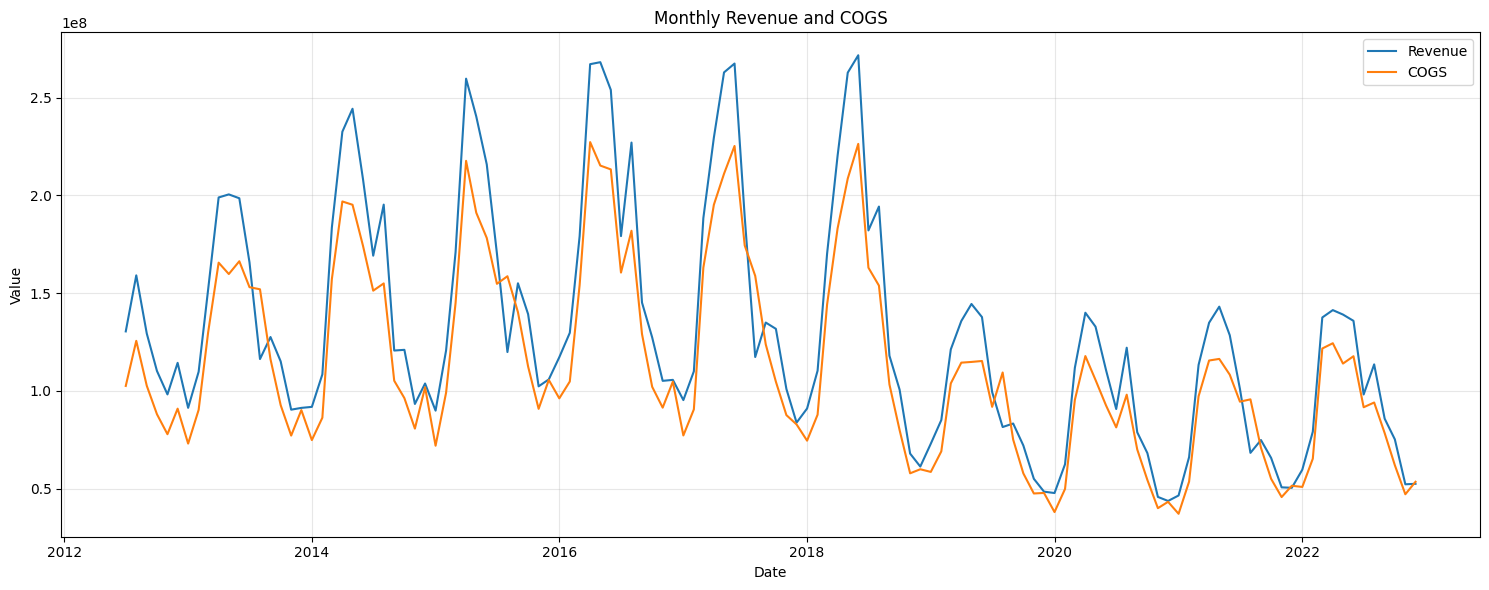

In [25]:
# =========================
# 1. Ép kiểu numeric
# =========================
numeric_cols = ["quantity", "unit_price", "discount_amount", "cogs"]

for col in numeric_cols:
    if col in master.columns:
        master[col] = pd.to_numeric(master[col], errors="coerce")

master["quantity"] = master["quantity"].fillna(0)
master["unit_price"] = master["unit_price"].fillna(0)
master["discount_amount"] = master["discount_amount"].fillna(0)
master["cogs"] = master["cogs"].fillna(0)


# =========================
# 2. Tính financial metrics
# =========================
master["item_revenue"] = master["quantity"] * master["unit_price"] - master["discount_amount"]
master["total_cogs"] = master["quantity"] * master["cogs"]
master["gross_profit"] = master["item_revenue"] - master["total_cogs"]

master["gross_margin_pct"] = np.where(
    master["item_revenue"] > 0,
    master["gross_profit"] / master["item_revenue"],
    np.nan
)


# =========================
# 3. Lọc đơn hợp lệ
# Không dùng cancelled để phân tích Revenue
# =========================
master["order_status_lower"] = master["order_status"].astype(str).str.lower()

sales_valid = master[
    ~master["order_status_lower"].isin(["cancelled", "canceled"])
].copy()

print("Master shape:", master.shape)
print("Valid sales shape:", sales_valid.shape)


# =========================
# 4. So sánh Revenue tái cấu trúc với sales.csv
# =========================
sales_official = datasets["sales"].copy()
sales_official["Date"] = pd.to_datetime(sales_official["Date"])
sales_official = sales_official.sort_values("Date")

# Biến global dùng cho các cell sau
sales = sales_official.copy()

daily_reconstructed = (
    sales_valid
    .groupby("order_date", as_index=False)
    .agg(
        Revenue_from_items=("item_revenue", "sum"),
        COGS_from_items=("total_cogs", "sum")
    )
    .rename(columns={"order_date": "Date"})
)

daily_reconstructed["Date"] = pd.to_datetime(daily_reconstructed["Date"])

compare_df = sales_official.merge(
    daily_reconstructed,
    on="Date",
    how="left"
)

compare_df[["Revenue_from_items", "COGS_from_items"]] = compare_df[
    ["Revenue_from_items", "COGS_from_items"]
].fillna(0)

compare_df["Revenue_diff"] = compare_df["Revenue"] - compare_df["Revenue_from_items"]
compare_df["COGS_diff"] = compare_df["COGS"] - compare_df["COGS_from_items"]

print("Tổng sai lệch Revenue:", compare_df["Revenue_diff"].sum())
print("Tổng sai lệch COGS:", compare_df["COGS_diff"].sum())

display(compare_df.head())


# =========================
# 5. Vẽ Revenue và COGS theo tháng
# =========================
monthly_sales = (
    sales_official
    .set_index("Date")[["Revenue", "COGS"]]
    .resample("MS")
    .sum()
    .reset_index()
)

plt.figure(figsize=(15, 6))
plt.plot(monthly_sales["Date"], monthly_sales["Revenue"], label="Revenue")
plt.plot(monthly_sales["Date"], monthly_sales["COGS"], label="COGS")

plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Monthly Revenue and COGS")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Revenue Trend & Seasonality

Phần này dùng `sales.csv` để xác định tháng cao điểm/thấp điểm thông qua Seasonality Index. Chỉ số > 1 nghĩa là tháng đó có Revenue cao hơn trung bình.

,month,Revenue,seasonality_index
0,1,8.032579e+07,0.610970
1,2,9.815858e+07,0.746609
2,3,1.527737e+08,1.162020
3,4,1.959886e+08,1.490719
4,5,2.038379e+08,1.550422
5,6,1.928133e+08,1.466567
6,7,1.431826e+08,1.089069
7,8,1.376770e+08,1.047192
8,9,1.139348e+08,0.866605
9,10,1.023845e+08,0.778752


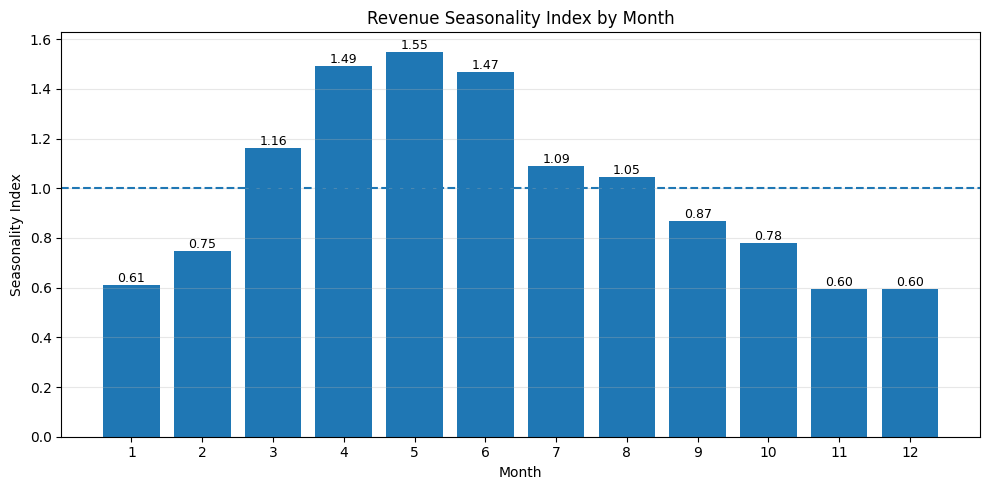

In [26]:
# =========================
# Seasonality Analysis
# =========================

sales_season = sales.copy()
sales_season["year"] = sales_season["Date"].dt.year
sales_season["month"] = sales_season["Date"].dt.month

monthly_season = (
    sales_season
    .groupby(["year", "month"], as_index=False)[["Revenue", "COGS"]]
    .sum()
)

month_profile = (
    monthly_season
    .groupby("month", as_index=False)["Revenue"]
    .mean()
)

month_profile["seasonality_index"] = (
    month_profile["Revenue"] / month_profile["Revenue"].mean()
)

display(month_profile)

plt.figure(figsize=(10, 5))
bars = plt.bar(month_profile["month"].astype(str), month_profile["seasonality_index"])

plt.axhline(1.0, linestyle="--")
plt.xlabel("Month")
plt.ylabel("Seasonality Index")
plt.title("Revenue Seasonality Index by Month")
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## 4. Product Portfolio: Category & Brand

Phần này phân tích Revenue, Gross Profit, Gross Margin và Revenue Share theo `category` và `brand`.

,category,total_revenue,total_cogs,total_profit,order_count,units_sold,gross_margin,revenue_share
3,Streetwear,"11,402,536,390","10,344,762,578","1,057,773,811",353786,"1,606,351",9.28%,80.11%
2,Outdoor,"2,132,750,385","1,889,777,036","242,973,349",181919,"1,061,333",11.39%,14.98%
0,Casual,"399,320,219","368,436,057","30,884,162",21428,"97,584",7.73%,2.81%
1,GenZ,"299,248,635","253,137,564","46,111,071",33704,"151,762",15.41%,2.10%


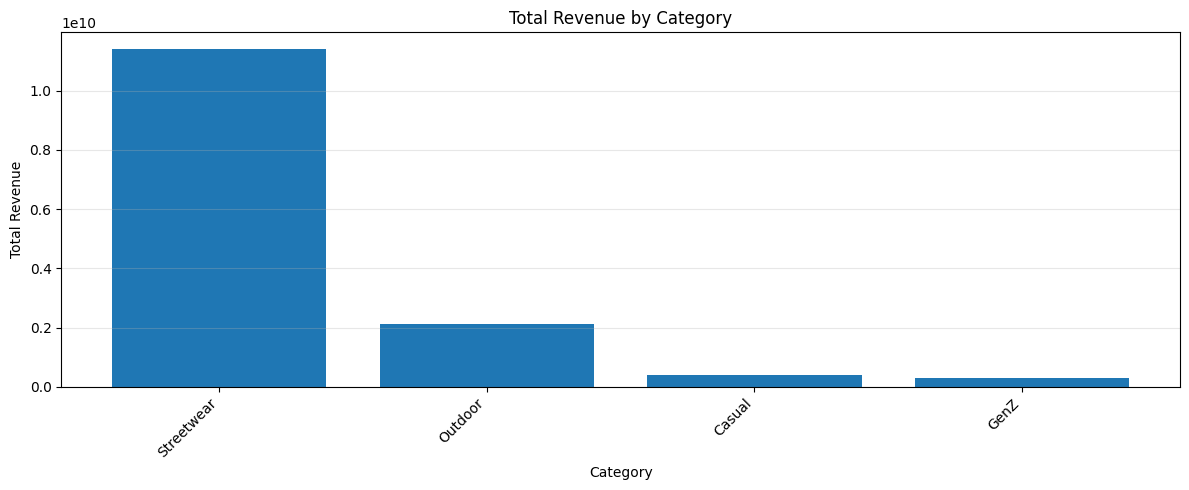

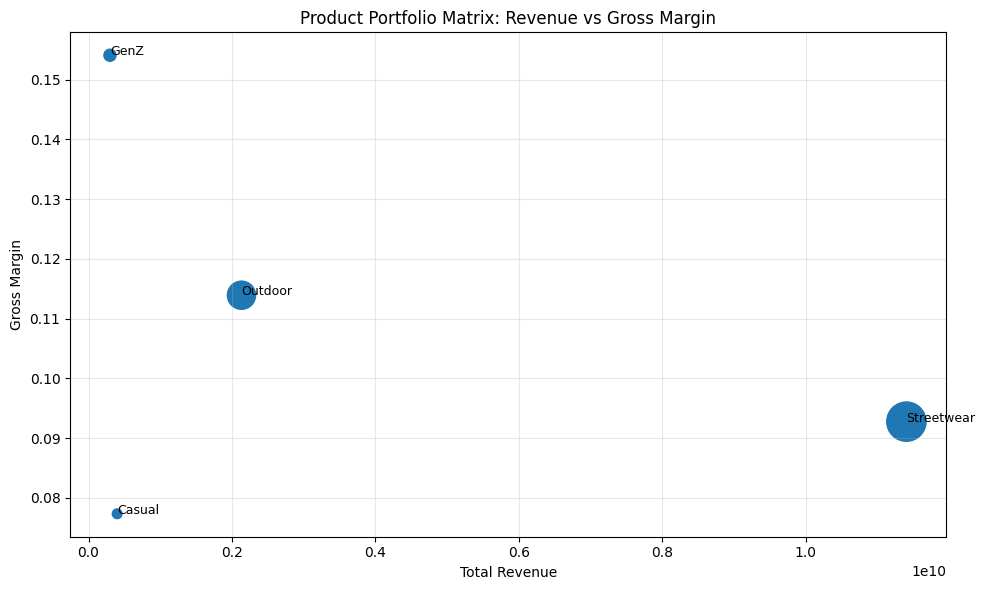

Số brand: 14


,brand,total_revenue,total_profit,units_sold,num_products,gross_margin
10,SaigonFlex,"6,209,853,040","603,056,109","673,613",256,9.71%
2,HanoiStreet,"2,536,772,515","212,316,003","807,119",183,8.37%
13,VietMotion,"1,687,179,605","175,678,896","534,259",112,10.41%
11,UrbanVN,"1,219,669,176","114,984,017","307,813",115,9.43%
5,MekongFit,"1,140,669,657","103,900,464","331,155",151,9.11%
12,VietMode,"369,427,564","46,762,535","100,237",296,12.66%
1,DragonWear,"319,161,679","31,700,497","39,105",100,9.93%
0,BambooCraft,"181,171,467","19,817,358","18,447",35,10.94%
4,LotusWear,"166,628,612","18,554,609","21,781",119,11.14%
8,PhoenixWear,"149,781,930","17,482,358","27,227",62,11.67%


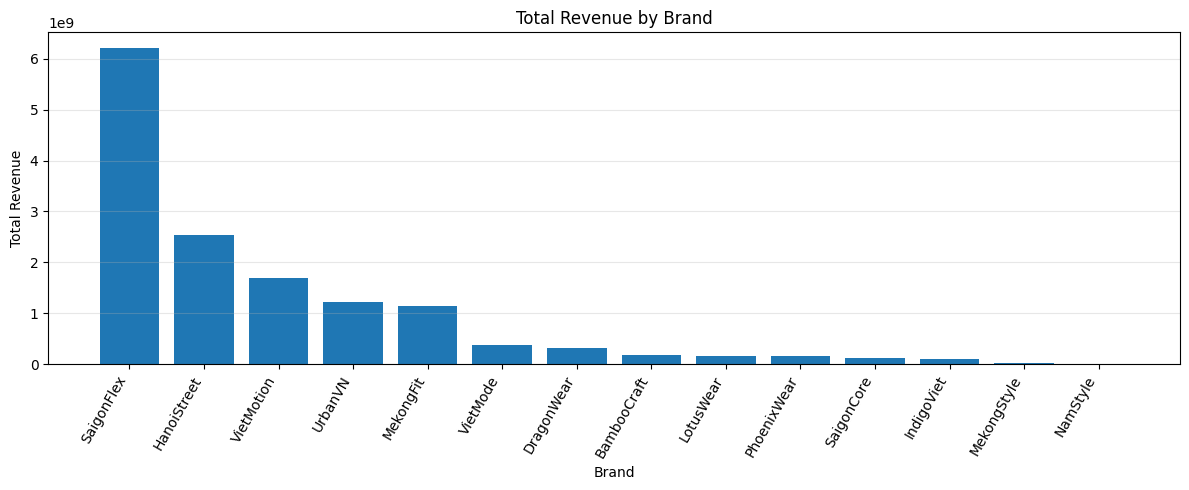

In [27]:
# =========================
# 1. Category portfolio
# =========================
category_portfolio = (
    sales_valid
    .groupby("category", as_index=False)
    .agg(
        total_revenue=("item_revenue", "sum"),
        total_cogs=("total_cogs", "sum"),
        total_profit=("gross_profit", "sum"),
        order_count=("order_id", "nunique"),
        units_sold=("quantity", "sum")
    )
)

category_portfolio["gross_margin"] = np.where(
    category_portfolio["total_revenue"] > 0,
    category_portfolio["total_profit"] / category_portfolio["total_revenue"],
    np.nan
)

category_portfolio["revenue_share"] = (
    category_portfolio["total_revenue"] / category_portfolio["total_revenue"].sum()
)

category_portfolio = category_portfolio.sort_values("total_revenue", ascending=False)

display(
    category_portfolio.style.format({
        "total_revenue": "{:,.0f}",
        "total_cogs": "{:,.0f}",
        "total_profit": "{:,.0f}",
        "gross_margin": "{:.2%}",
        "revenue_share": "{:.2%}",
        "units_sold": "{:,.0f}"
    })
)

plt.figure(figsize=(12, 5))
plt.bar(category_portfolio["category"], category_portfolio["total_revenue"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.title("Total Revenue by Category")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# =========================
# 2. Revenue vs Gross Margin
# =========================
plt.figure(figsize=(10, 6))
plt.scatter(
    category_portfolio["total_revenue"],
    category_portfolio["gross_margin"],
    s=category_portfolio["order_count"] / category_portfolio["order_count"].max() * 800
)

for _, row in category_portfolio.iterrows():
    plt.text(row["total_revenue"], row["gross_margin"], row["category"], fontsize=9)

plt.xlabel("Total Revenue")
plt.ylabel("Gross Margin")
plt.title("Product Portfolio Matrix: Revenue vs Gross Margin")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =========================
# 3. Brand analysis
# =========================
brand_portfolio = (
    sales_valid
    .groupby("brand", as_index=False)
    .agg(
        total_revenue=("item_revenue", "sum"),
        total_profit=("gross_profit", "sum"),
        units_sold=("quantity", "sum"),
        num_products=("product_id", "nunique")
    )
)

brand_portfolio["gross_margin"] = np.where(
    brand_portfolio["total_revenue"] > 0,
    brand_portfolio["total_profit"] / brand_portfolio["total_revenue"],
    np.nan
)

brand_portfolio = brand_portfolio.sort_values("total_revenue", ascending=False)

print("Số brand:", brand_portfolio["brand"].nunique())
display(
    brand_portfolio.style.format({
        "total_revenue": "{:,.0f}",
        "total_profit": "{:,.0f}",
        "units_sold": "{:,.0f}",
        "gross_margin": "{:.2%}"
    })
)

plt.figure(figsize=(12, 5))
plt.bar(brand_portfolio["brand"], brand_portfolio["total_revenue"])
plt.xticks(rotation=60, ha="right")
plt.xlabel("Brand")
plt.ylabel("Total Revenue")
plt.title("Total Revenue by Brand")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Promotion ROI

Phần này đánh giá promotion bằng Profit/Discount thay vì chỉ nhìn Revenue. Đây là góc nhìn quan trọng vì khuyến mãi có thể tăng doanh thu nhưng ăn mòn Gross Profit.

,category,has_discount,revenue,profit,discount,orders,units,margin,discount_rate
0,Casual,False,"291,979,109","47,376,252",0,14233,64900,16.23%,0.00%
1,Casual,True,"107,341,110","-16,492,090","18,441,832",7195,32684,-15.36%,14.66%
2,GenZ,False,"221,069,277","50,714,488",0,22588,102093,22.94%,0.00%
3,GenZ,True,"78,179,358","-4,603,417","13,544,109",11116,49669,-5.89%,14.77%
4,Outdoor,False,"1,440,733,793","310,924,501",0,106388,618781,21.58%,0.00%
5,Outdoor,True,"692,016,592","-67,951,153","128,091,109",75531,442552,-9.82%,15.62%
6,Streetwear,False,"8,025,257,272","1,583,470,652",0,221092,1004016,19.73%,0.00%
7,Streetwear,True,"3,377,279,117","-525,696,841","520,652,901",132694,602335,-15.57%,13.36%


,category,promo_revenue,promo_profit,total_discount,promo_orders,promo_roi
1,GenZ,"78,179,358","-4,603,417","13,544,109",11116,-0.34
2,Outdoor,"692,016,592","-67,951,153","128,091,109",75531,-0.53
0,Casual,"107,341,110","-16,492,090","18,441,832",7195,-0.89
3,Streetwear,"3,377,279,117","-525,696,841","520,652,901",132694,-1.01


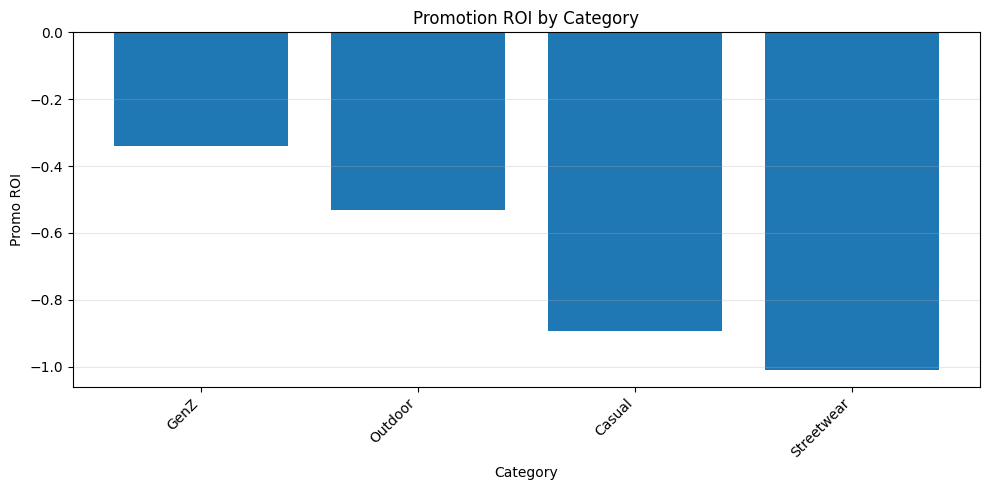

In [28]:
# =========================
# Promotion ROI
# =========================

promo_analysis = sales_valid.copy()
promo_analysis["has_discount"] = promo_analysis["discount_amount"] > 0

promo_summary = (
    promo_analysis
    .groupby(["category", "has_discount"], as_index=False)
    .agg(
        revenue=("item_revenue", "sum"),
        profit=("gross_profit", "sum"),
        discount=("discount_amount", "sum"),
        orders=("order_id", "nunique"),
        units=("quantity", "sum")
    )
)

promo_summary["margin"] = np.where(
    promo_summary["revenue"] > 0,
    promo_summary["profit"] / promo_summary["revenue"],
    np.nan
)

promo_summary["discount_rate"] = np.where(
    promo_summary["revenue"] + promo_summary["discount"] > 0,
    promo_summary["discount"] / (promo_summary["revenue"] + promo_summary["discount"]),
    np.nan
)

display(
    promo_summary.style.format({
        "revenue": "{:,.0f}",
        "profit": "{:,.0f}",
        "discount": "{:,.0f}",
        "margin": "{:.2%}",
        "discount_rate": "{:.2%}"
    })
)

promo_only = promo_analysis[promo_analysis["has_discount"]].copy()

promo_roi_by_category = (
    promo_only
    .groupby("category", as_index=False)
    .agg(
        promo_revenue=("item_revenue", "sum"),
        promo_profit=("gross_profit", "sum"),
        total_discount=("discount_amount", "sum"),
        promo_orders=("order_id", "nunique")
    )
)

promo_roi_by_category["promo_roi"] = np.where(
    promo_roi_by_category["total_discount"] > 0,
    promo_roi_by_category["promo_profit"] / promo_roi_by_category["total_discount"],
    np.nan
)

promo_roi_by_category = promo_roi_by_category.sort_values("promo_roi", ascending=False)

display(
    promo_roi_by_category.style.format({
        "promo_revenue": "{:,.0f}",
        "promo_profit": "{:,.0f}",
        "total_discount": "{:,.0f}",
        "promo_roi": "{:.2f}"
    })
)

plt.figure(figsize=(10, 5))
plt.bar(promo_roi_by_category["category"], promo_roi_by_category["promo_roi"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Category")
plt.ylabel("Promo ROI")
plt.title("Promotion ROI by Category")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Returns Impact

Phần này đo mức độ hoàn trả ăn mòn Revenue thông qua `Refund / Revenue` và `Unit Return Rate` theo category.

,category,sold_units,revenue,returned_units,refund_amount,return_orders,unit_return_rate,refund_to_revenue
1,GenZ,"151,762","299,248,635","5,869","11,145,648",2120,3.87%,3.72%
2,Outdoor,"1,061,333","2,132,750,385","40,417","78,717,515",11293,3.81%,3.69%
3,Streetwear,"1,606,351","11,402,536,390","59,801","406,708,249",21596,3.72%,3.57%
0,Casual,"97,584","399,320,219","3,499","14,027,094",1272,3.59%,3.51%


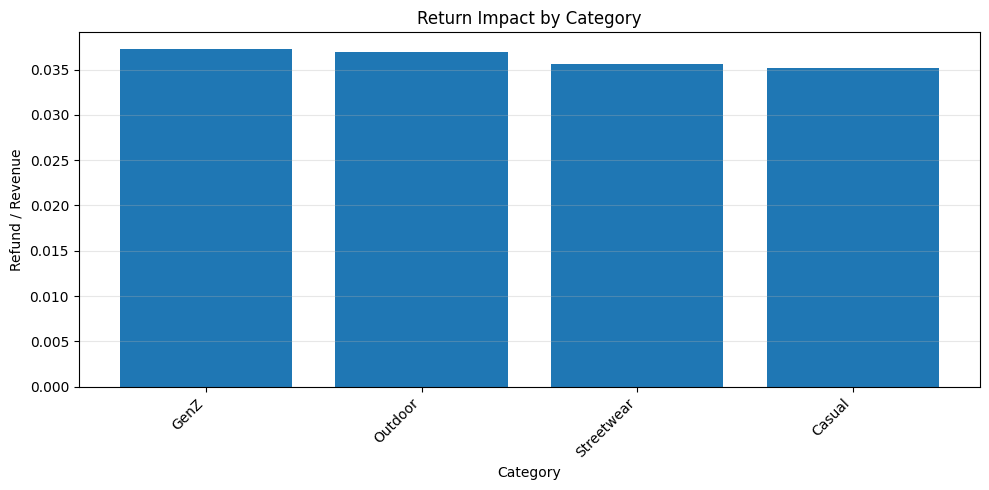

In [29]:
# =========================
# Returns Impact
# =========================

if "returns" in datasets:
    returns = datasets["returns"].copy()
    returns["return_date"] = pd.to_datetime(returns["return_date"], errors="coerce")

    returns_products = returns.merge(
        products[["product_id", "product_name", "category", "brand"]],
        on="product_id",
        how="left"
    )

    return_summary = (
        returns_products
        .groupby("category", as_index=False)
        .agg(
            returned_units=("return_quantity", "sum"),
            refund_amount=("refund_amount", "sum"),
            return_orders=("order_id", "nunique")
        )
    )

    sold_summary = (
        sales_valid
        .groupby("category", as_index=False)
        .agg(
            sold_units=("quantity", "sum"),
            revenue=("item_revenue", "sum")
        )
    )

    return_impact = sold_summary.merge(return_summary, on="category", how="left")
    return_impact[["returned_units", "refund_amount", "return_orders"]] = return_impact[
        ["returned_units", "refund_amount", "return_orders"]
    ].fillna(0)

    return_impact["unit_return_rate"] = np.where(
        return_impact["sold_units"] > 0,
        return_impact["returned_units"] / return_impact["sold_units"],
        np.nan
    )

    return_impact["refund_to_revenue"] = np.where(
        return_impact["revenue"] > 0,
        return_impact["refund_amount"] / return_impact["revenue"],
        np.nan
    )

    return_impact = return_impact.sort_values("refund_to_revenue", ascending=False)

    display(
        return_impact.style.format({
            "sold_units": "{:,.0f}",
            "returned_units": "{:,.0f}",
            "revenue": "{:,.0f}",
            "refund_amount": "{:,.0f}",
            "unit_return_rate": "{:.2%}",
            "refund_to_revenue": "{:.2%}"
        })
    )

    plt.figure(figsize=(10, 5))
    plt.bar(return_impact["category"], return_impact["refund_to_revenue"])
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Category")
    plt.ylabel("Refund / Revenue")
    plt.title("Return Impact by Category")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    print("Không có bảng returns trong dataset.")

## 7. Customer & Region Revenue

Phần này phân tích Revenue theo nhóm khách hàng, khu vực và tách Revenue từ khách mới so với khách quay lại.

,age_group,revenue,profit,orders,customers,margin,arpu
1,25-34,"4,204,623,313","407,695,073",173120,26167,9.70%,"160,684"
2,35-44,"3,748,030,792","360,758,247",154878,23091,9.63%,"162,316"
3,45-54,"2,739,522,769","269,408,680",112703,16801,9.83%,"163,057"
0,18-24,"1,952,227,648","188,613,750",80828,12295,9.66%,"158,782"
4,55+,"1,589,451,107","151,266,642",65954,9769,9.52%,"162,704"


,region,revenue,profit,orders,customers,margin,arpu
1,East,"6,617,595,804","632,038,271",267501,43747,9.55%,"151,270"
0,Central,"4,278,238,867","400,856,561",167583,29932,9.37%,"142,932"
2,West,"3,338,020,957","344,847,560",152399,14444,10.33%,"231,101"


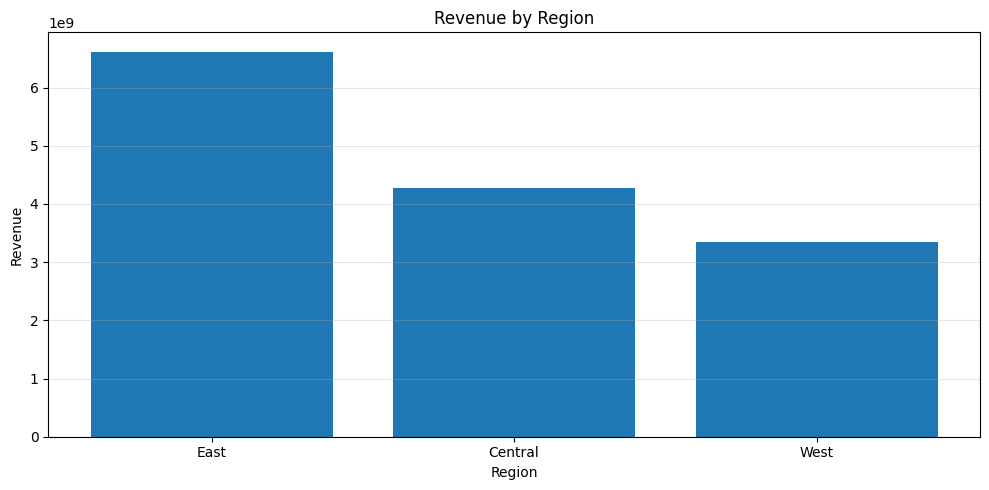

,year,customer_type,revenue,orders,customers
0,2012,New Customer,4.958770e+08,20753,20603
1,2012,Returning Customer,1.769411e+08,8400,5680
2,2013,New Customer,5.206966e+08,24562,24407
3,2013,Returning Customer,9.048373e+08,45194,21309
4,2014,New Customer,2.986866e+08,13361,13277
5,2014,Returning Customer,1.325789e+09,59997,28170
6,2015,New Customer,1.902758e+08,8829,8783
7,2015,Returning Customer,1.434717e+09,66128,31490
8,2016,New Customer,1.576003e+08,6438,6406
9,2016,Returning Customer,1.671238e+09,68329,33373


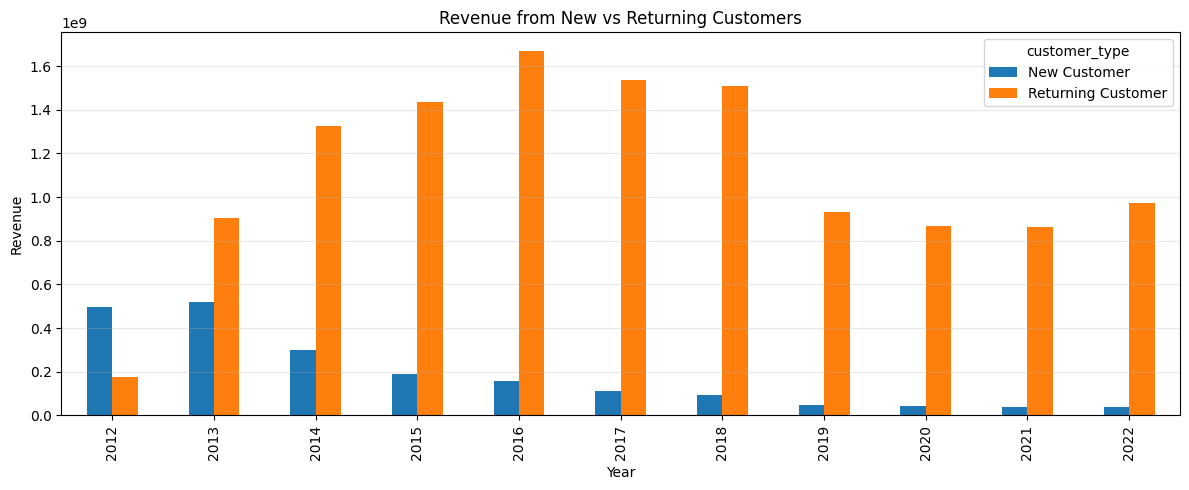

In [30]:
# =========================
# Customer & Region Revenue
# =========================

customer_region_df = sales_valid.copy()
customer_region_df["year"] = customer_region_df["order_date"].dt.year

# 1. Revenue theo age_group
if "age_group" in customer_region_df.columns:
    age_summary = (
        customer_region_df
        .groupby("age_group", as_index=False)
        .agg(
            revenue=("item_revenue", "sum"),
            profit=("gross_profit", "sum"),
            orders=("order_id", "nunique"),
            customers=("customer_id", "nunique")
        )
    )

    age_summary["margin"] = np.where(age_summary["revenue"] > 0, age_summary["profit"] / age_summary["revenue"], np.nan)
    age_summary["arpu"] = np.where(age_summary["customers"] > 0, age_summary["revenue"] / age_summary["customers"], np.nan)
    age_summary = age_summary.sort_values("revenue", ascending=False)

    display(
        age_summary.style.format({
            "revenue": "{:,.0f}",
            "profit": "{:,.0f}",
            "margin": "{:.2%}",
            "arpu": "{:,.0f}"
        })
    )

# 2. Revenue theo region
if "region" in customer_region_df.columns:
    region_summary = (
        customer_region_df
        .groupby("region", as_index=False)
        .agg(
            revenue=("item_revenue", "sum"),
            profit=("gross_profit", "sum"),
            orders=("order_id", "nunique"),
            customers=("customer_id", "nunique")
        )
    )

    region_summary["margin"] = np.where(region_summary["revenue"] > 0, region_summary["profit"] / region_summary["revenue"], np.nan)
    region_summary["arpu"] = np.where(region_summary["customers"] > 0, region_summary["revenue"] / region_summary["customers"], np.nan)
    region_summary = region_summary.sort_values("revenue", ascending=False)

    display(
        region_summary.style.format({
            "revenue": "{:,.0f}",
            "profit": "{:,.0f}",
            "margin": "{:.2%}",
            "arpu": "{:,.0f}"
        })
    )

    plt.figure(figsize=(10, 5))
    plt.bar(region_summary["region"], region_summary["revenue"])
    plt.xlabel("Region")
    plt.ylabel("Revenue")
    plt.title("Revenue by Region")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

# 3. New vs Returning Customer Revenue
customer_order = (
    customer_region_df
    .groupby(["customer_id", "order_id"], as_index=False)
    .agg(
        order_date=("order_date", "min"),
        revenue=("item_revenue", "sum")
    )
)

first_order = (
    customer_order
    .groupby("customer_id", as_index=False)["order_date"]
    .min()
    .rename(columns={"order_date": "first_order_date"})
)

customer_order = customer_order.merge(first_order, on="customer_id", how="left")
customer_order["customer_type"] = np.where(
    customer_order["order_date"] == customer_order["first_order_date"],
    "New Customer",
    "Returning Customer"
)

customer_order["year"] = customer_order["order_date"].dt.year

new_returning_summary = (
    customer_order
    .groupby(["year", "customer_type"], as_index=False)
    .agg(
        revenue=("revenue", "sum"),
        orders=("order_id", "nunique"),
        customers=("customer_id", "nunique")
    )
)

display(new_returning_summary)

pivot_customer_type = new_returning_summary.pivot(
    index="year",
    columns="customer_type",
    values="revenue"
).fillna(0)

pivot_customer_type.plot(kind="bar", figsize=(12, 5))
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.title("Revenue from New vs Returning Customers")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Inventory Stockout / Overstock

Phần này phân tích tồn kho để xem category nào có rủi ro mất doanh thu do stockout, hoặc bị overstock làm tăng chi phí lưu kho.

,category,avg_stock_on_hand,total_units_sold,total_stockout_days,avg_days_of_supply,avg_fill_rate,stockout_count,overstock_count,reorder_count,avg_sell_through_rate
3,Streetwear,185.7,"511,467","36,993",887.1,96.02%,"20,883","23,242",0,15.98%
2,Outdoor,225.6,"337,510","23,552","1,068.8",96.27%,"14,177","16,809",0,13.51%
1,GenZ,125.1,"48,695","5,368",718.8,96.17%,"3,192","3,348",0,16.80%
0,Casual,88.6,"31,202","4,012",459.1,96.18%,"2,319","2,543",0,16.84%


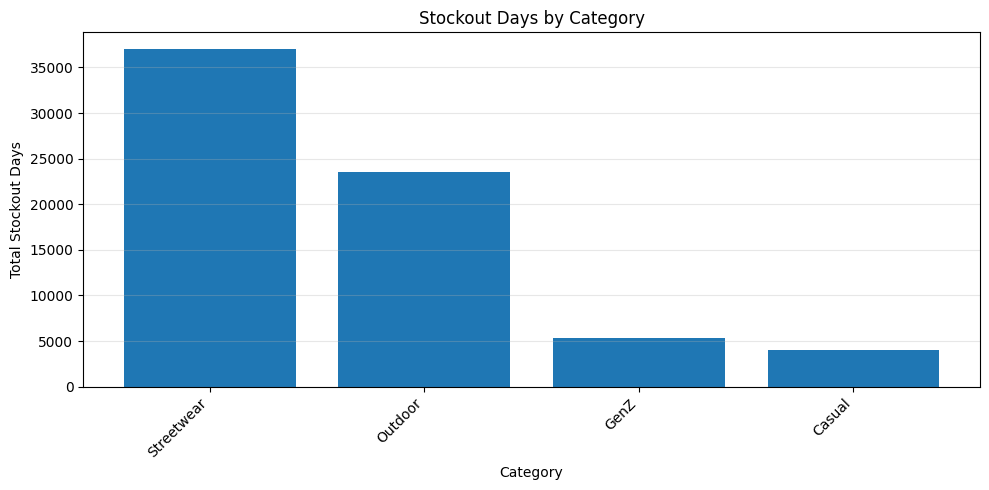

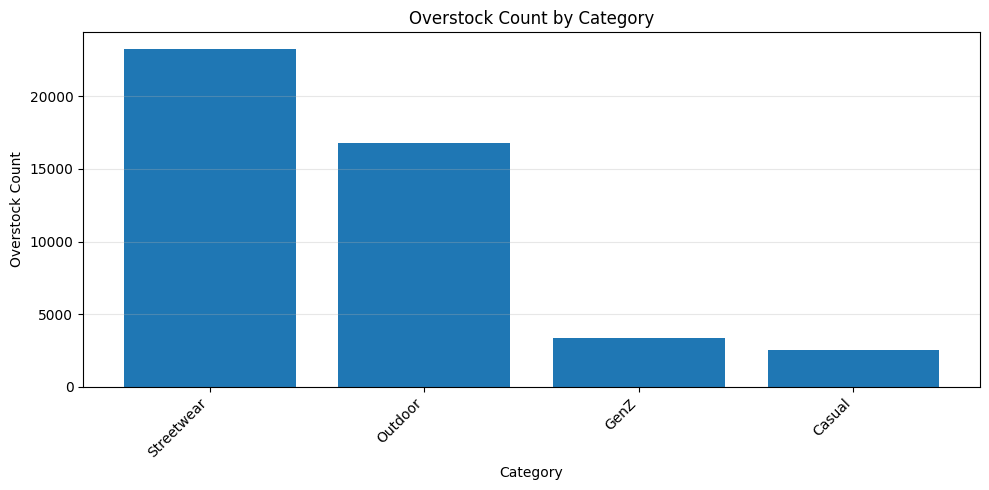

In [31]:
# =========================
# Inventory Stockout / Overstock
# =========================

if "inventory" in datasets:
    inventory = datasets["inventory"].copy()
    inventory["snapshot_date"] = pd.to_datetime(inventory["snapshot_date"], errors="coerce")

    if "category" not in inventory.columns:
        inventory = inventory.merge(
            products[["product_id", "category", "brand"]],
            on="product_id",
            how="left"
        )

    inventory_summary = (
        inventory
        .groupby("category", as_index=False)
        .agg(
            avg_stock_on_hand=("stock_on_hand", "mean"),
            total_units_sold=("units_sold", "sum"),
            total_stockout_days=("stockout_days", "sum"),
            avg_days_of_supply=("days_of_supply", "mean"),
            avg_fill_rate=("fill_rate", "mean"),
            stockout_count=("stockout_flag", "sum"),
            overstock_count=("overstock_flag", "sum"),
            reorder_count=("reorder_flag", "sum"),
            avg_sell_through_rate=("sell_through_rate", "mean")
        )
    )

    inventory_summary = inventory_summary.sort_values("total_stockout_days", ascending=False)

    display(
        inventory_summary.style.format({
            "avg_stock_on_hand": "{:,.1f}",
            "total_units_sold": "{:,.0f}",
            "total_stockout_days": "{:,.0f}",
            "avg_days_of_supply": "{:,.1f}",
            "avg_fill_rate": "{:.2%}",
            "stockout_count": "{:,.0f}",
            "overstock_count": "{:,.0f}",
            "reorder_count": "{:,.0f}",
            "avg_sell_through_rate": "{:.2%}"
        })
    )

    plt.figure(figsize=(10, 5))
    plt.bar(inventory_summary["category"], inventory_summary["total_stockout_days"])
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Category")
    plt.ylabel("Total Stockout Days")
    plt.title("Stockout Days by Category")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar(inventory_summary["category"], inventory_summary["overstock_count"])
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Category")
    plt.ylabel("Overstock Count")
    plt.title("Overstock Count by Category")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    print("Không có bảng inventory trong dataset.")

## 9. Web Traffic Funnel

Phần này phân tích traffic source bằng cách nối `web_traffic.traffic_source` với `orders.order_source`. Không dùng tổng order toàn ngày gán cho từng source.

web_traffic columns: ['date', 'sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration_sec', 'traffic_source']
Lưu ý: web_traffic.csv không có cột conversion_rate, chỉ dùng computed_cvr = orders / sessions.


,source_key,orders,computed_cvr,avg_given_cvr,sessions,unique_visitors,page_views,avg_bounce_rate,avg_session_duration
2,organic_search,45906.0,0.001688,NaN,27196976,20625107,117606452,0.004504,211.153946
3,paid_search,26507.0,0.001353,NaN,19598271,14922386,85079551,0.004478,209.362122
5,social_media,19963.0,0.001262,NaN,15816226,12048065,68072140,0.004476,210.290207
1,email_campaign,9258.0,0.000724,NaN,12792670,9700462,55477636,0.004458,213.220596
4,referral,5600.0,0.000591,NaN,9476845,7220019,41655659,0.004499,207.558670
0,direct,3202.0,0.000487,NaN,6571549,4986650,28771362,0.004511,207.678192


,source_key,orders,computed_cvr,avg_given_cvr,sessions,unique_visitors,page_views,avg_bounce_rate,avg_session_duration
2,organic_search,"45,906",0.17%,nan%,"27,196,976","20,625,107","117,606,452",0.45%,211.2
3,paid_search,"26,507",0.14%,nan%,"19,598,271","14,922,386","85,079,551",0.45%,209.4
5,social_media,"19,963",0.13%,nan%,"15,816,226","12,048,065","68,072,140",0.45%,210.3
1,email_campaign,"9,258",0.07%,nan%,"12,792,670","9,700,462","55,477,636",0.45%,213.2
4,referral,"5,600",0.06%,nan%,"9,476,845","7,220,019","41,655,659",0.45%,207.6
0,direct,"3,202",0.05%,nan%,"6,571,549","4,986,650","28,771,362",0.45%,207.7


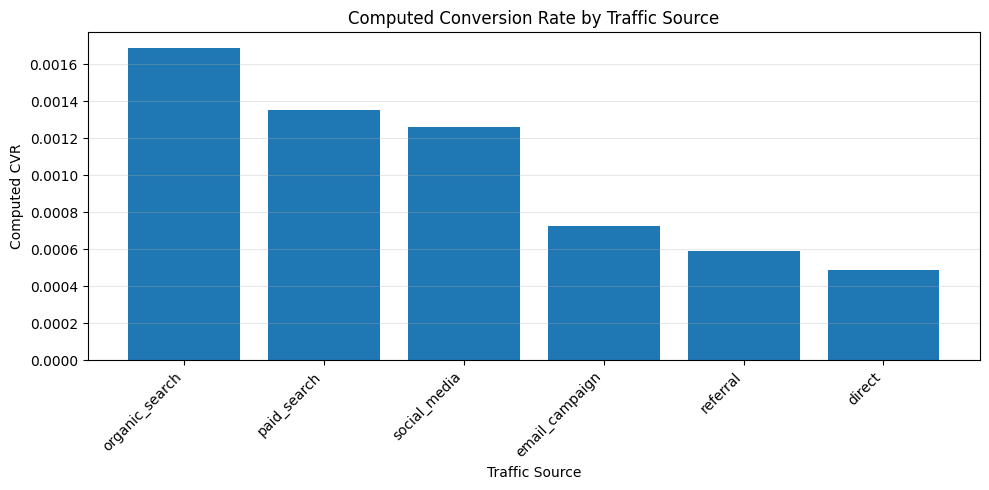

In [32]:
# =========================
# Web Traffic Funnel
# Robust version: chạy được dù web_traffic.csv không có conversion_rate
# =========================

if "web_traffic" in datasets:
    web = datasets["web_traffic"].copy()
    print("web_traffic columns:", list(web.columns))

    # Chuẩn hóa date
    web["date"] = pd.to_datetime(web["date"], errors="coerce")

    orders_for_funnel = datasets["orders"].copy()
    orders_for_funnel["order_date"] = pd.to_datetime(
        orders_for_funnel["order_date"],
        errors="coerce"
    )

    # Nếu thiếu traffic_source hoặc order_source thì dừng mềm, không crash notebook
    if "traffic_source" not in web.columns:
        print("web_traffic.csv không có cột traffic_source, bỏ qua Web Traffic Funnel.")
    elif "order_source" not in orders_for_funnel.columns:
        print("orders.csv không có cột order_source, bỏ qua Web Traffic Funnel.")
    else:
        web["source_key"] = web["traffic_source"].astype(str).str.lower().str.strip()
        orders_for_funnel["source_key"] = orders_for_funnel["order_source"].astype(str).str.lower().str.strip()

        valid_orders_for_funnel = orders_for_funnel[
            ~orders_for_funnel["order_status"].astype(str).str.lower().isin(["cancelled", "canceled"])
        ].copy()

        daily_orders_source = (
            valid_orders_for_funnel
            .groupby(["order_date", "source_key"], as_index=False)
            .agg(order_count=("order_id", "nunique"))
            .rename(columns={"order_date": "date"})
        )

        # Các cột web có thể có/không có tùy phiên bản dataset
        agg_dict = {}

        if "sessions" in web.columns:
            agg_dict["sessions"] = ("sessions", "sum")
        if "unique_visitors" in web.columns:
            agg_dict["unique_visitors"] = ("unique_visitors", "sum")
        if "page_views" in web.columns:
            agg_dict["page_views"] = ("page_views", "sum")
        if "bounce_rate" in web.columns:
            agg_dict["bounce_rate"] = ("bounce_rate", "mean")
        if "avg_session_duration_sec" in web.columns:
            agg_dict["avg_session_duration_sec"] = ("avg_session_duration_sec", "mean")
        if "conversion_rate" in web.columns:
            agg_dict["conversion_rate_given"] = ("conversion_rate", "mean")

        if len(agg_dict) == 0:
            print("web_traffic.csv không có đủ cột metric để phân tích funnel.")
        else:
            web_daily = (
                web
                .groupby(["date", "source_key"], as_index=False)
                .agg(**agg_dict)
            )

            funnel = web_daily.merge(
                daily_orders_source,
                on=["date", "source_key"],
                how="left"
            )

            funnel["order_count"] = funnel["order_count"].fillna(0)

            # Nếu không có sessions thì không tính được computed_cvr
            if "sessions" in funnel.columns:
                funnel["computed_cvr"] = np.where(
                    funnel["sessions"] > 0,
                    funnel["order_count"] / funnel["sessions"],
                    np.nan
                )
            else:
                funnel["computed_cvr"] = np.nan

            # Nếu dataset không có conversion_rate thì tạo cột rỗng để không lỗi
            if "conversion_rate_given" not in funnel.columns:
                funnel["conversion_rate_given"] = np.nan
                print("Lưu ý: web_traffic.csv không có cột conversion_rate, chỉ dùng computed_cvr = orders / sessions.")

            # Tạo agg động cho source_summary
            source_agg = {
                "orders": ("order_count", "sum"),
                "computed_cvr": ("computed_cvr", "mean"),
                "avg_given_cvr": ("conversion_rate_given", "mean")
            }

            if "sessions" in funnel.columns:
                source_agg["sessions"] = ("sessions", "sum")
            if "unique_visitors" in funnel.columns:
                source_agg["unique_visitors"] = ("unique_visitors", "sum")
            if "page_views" in funnel.columns:
                source_agg["page_views"] = ("page_views", "sum")
            if "bounce_rate" in funnel.columns:
                source_agg["avg_bounce_rate"] = ("bounce_rate", "mean")
            if "avg_session_duration_sec" in funnel.columns:
                source_agg["avg_session_duration"] = ("avg_session_duration_sec", "mean")

            source_summary = (
                funnel
                .groupby("source_key", as_index=False)
                .agg(**source_agg)
            )

            # Tính lại computed_cvr tổng hợp theo source cho chuẩn hơn: total orders / total sessions
            if "sessions" in source_summary.columns:
                source_summary["computed_cvr"] = np.where(
                    source_summary["sessions"] > 0,
                    source_summary["orders"] / source_summary["sessions"],
                    np.nan
                )
                source_summary = source_summary.sort_values("sessions", ascending=False)
            else:
                source_summary = source_summary.sort_values("orders", ascending=False)

            display(source_summary)

            # Format mềm, chỉ format những cột tồn tại
            fmt = {}
            for col in ["sessions", "unique_visitors", "page_views", "orders"]:
                if col in source_summary.columns:
                    fmt[col] = "{:,.0f}"
            for col in ["avg_bounce_rate", "avg_given_cvr", "computed_cvr"]:
                if col in source_summary.columns:
                    fmt[col] = "{:.2%}"
            if "avg_session_duration" in source_summary.columns:
                fmt["avg_session_duration"] = "{:,.1f}"

            display(source_summary.style.format(fmt))

            plt.figure(figsize=(10, 5))
            plt.bar(source_summary["source_key"], source_summary["computed_cvr"].fillna(0))
            plt.xticks(rotation=45, ha="right")
            plt.xlabel("Traffic Source")
            plt.ylabel("Computed CVR")
            plt.title("Computed Conversion Rate by Traffic Source")
            plt.grid(axis="y", alpha=0.3)
            plt.tight_layout()
            plt.show()

else:
    print("Không có bảng web_traffic trong dataset.")


## Forecasting V4: Leakage-safe Multi-model Ensemble

Pipeline forecasting được xây dựng theo hướng chống leakage. Dữ liệu được chia theo thời gian: train là giai đoạn trước 2022, validation là năm 2022. Các thống kê target-based như month-day mean/median, month-dayofweek mean/median và month median chỉ được tính từ tập train khi validation.

Mô hình kết hợp nhiều nhóm dự báo: XGBoost, LightGBM, seasonal mean, seasonal median, hierarchical seasonal và các seasonal baseline có điều chỉnh tăng trưởng YoY. Trọng số ensemble được tối ưu trên validation 2022 bằng SLSQP để minimize MAE với ràng buộc trọng số không âm và tổng trọng số bằng 1. Sau validation, mô hình được train lại trên toàn bộ `sales.csv`, dự báo cho `sample_submission.csv` và xuất nhiều phiên bản submission để kiểm tra leaderboard.

Sales: 2012-07-04 00:00:00 -> 2022-12-31 00:00:00 (3833, 3)
Test : 2023-01-01 00:00:00 -> 2024-07-01 00:00:00 (548, 3)

Validation target: Revenue

Validation target: COGS


,fold,target,model,MAE,RMSE,R2
16,valid_2022,COGS,blend_ml_heavy,"543,458.66","734,493.57",0.74642
15,valid_2022,COGS,blend_lgb_heavy,"569,176.83","765,145.66",0.72481
9,valid_2022,COGS,xgb_bag,"602,315.72","800,796.64",0.69857
10,valid_2022,COGS,lgb_bag,"602,680.64","801,947.37",0.69770
14,valid_2022,COGS,blend_equal,"611,707.16","812,952.34",0.68935
17,valid_2022,COGS,blend_seasonal_heavy,"678,783.24","888,888.76",0.62860
13,valid_2022,COGS,hierarchical,"985,426.53","1,176,168.97",0.34974
11,valid_2022,COGS,seasonal_mean,"1,083,764.34","1,371,159.93",0.11626
12,valid_2022,COGS,seasonal_median,"1,085,968.43","1,407,659.10",0.06859
7,valid_2022,Revenue,blend_ml_heavy,"619,837.46","827,486.94",0.75560



Training final: Revenue

Training final: COGS
Saved: submission_v12_seedbag_equal.csv
Saved: submission_v12_seedbag_lgb_heavy.csv
Saved: submission_v12_seedbag_ml_heavy.csv
Saved: submission_v12_seedbag_seasonal_heavy.csv
Saved default: submission.csv


,file,Revenue_sum,Revenue_mean,Revenue_max,COGS_sum,COGS_mean,COGS/Revenue_mean
0,submission_v12_seedbag_equal.csv,"2,220,973,882.75","4,052,872.05","11,476,152.06","1,883,351,090.86","3,436,772.06",0.8504
1,submission_v12_seedbag_lgb_heavy.csv,"2,185,639,503.78","3,988,393.26","11,392,801.76","1,853,911,853.95","3,383,050.83",0.8506
2,submission_v12_seedbag_ml_heavy.csv,"2,162,815,625.70","3,946,743.84","11,318,092.80","1,832,718,587.34","3,344,376.98",0.8497
3,submission_v12_seedbag_seasonal_heavy.csv,"2,266,406,053.29","4,135,777.47","11,587,358.89","1,922,389,488.62","3,508,010.02",0.8507


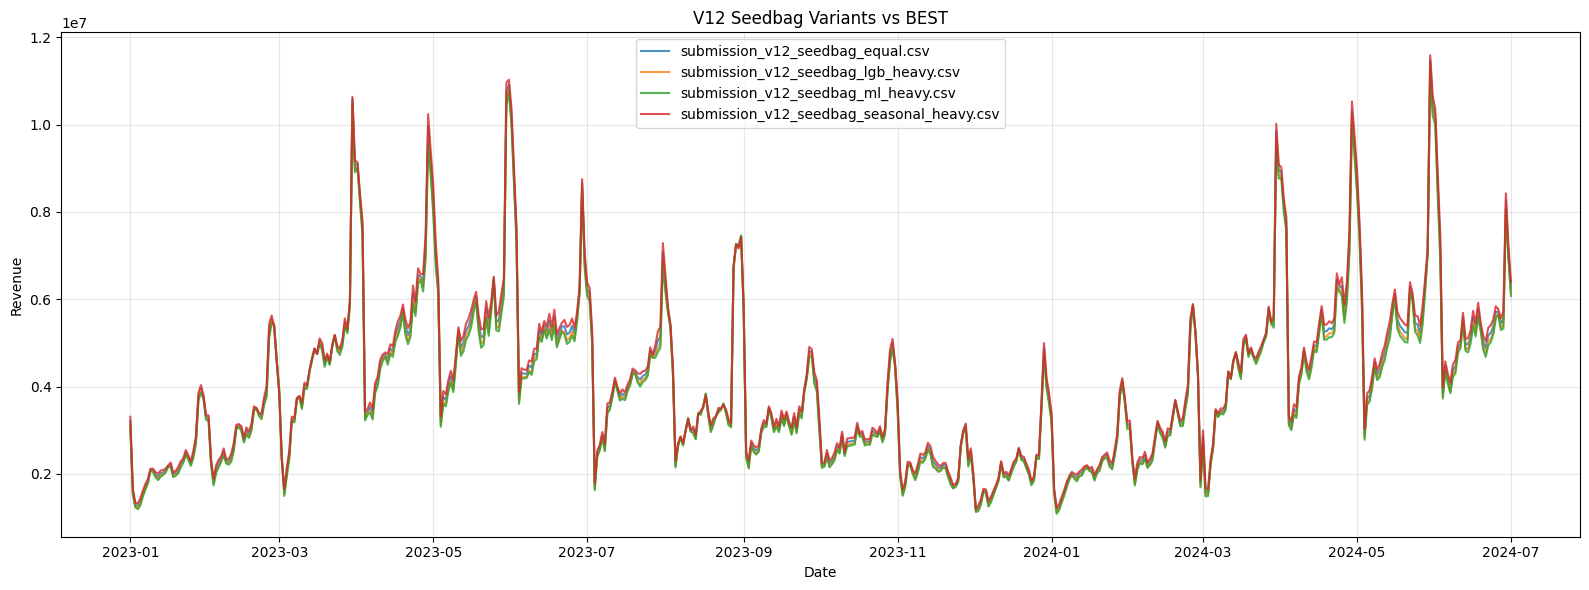


Submit recommendation:
1. Nếu submission_v12_seedbag_equal.csv lệch BEST ít hơn 0.5% Revenue_sum, có thể thử.
2. Nếu equal thua hoặc lệch mạnh, giữ BEST.
3. Để xuống 510k, cần model khác bản chất hoặc phát hiện signal mới; seedbag chỉ là hướng tăng nhỏ.


In [33]:
# ============================================================
# V12 — CLEAN REBUILD BEST + SEED BAGGING + SAFE VARIANTS
#
# Mục tiêu:
# - Không mutate file best nữa.
# - Rebuild pipeline gần lõi V3/BEST:
#   calendar + Fourier + promo + target median stats
#   XGB + LGB + seasonal_mean + seasonal_median + hierarchical
# - Nâng cấp duy nhất: seed bagging cho XGB/LGB.
# - Giữ post-processing COGS <= Revenue * 0.98 như BEST, không dùng cap 0.95.
#
# Output:
# - submission_v12_seedbag_equal.csv
# - submission_v12_seedbag_lgb_heavy.csv
# - submission_v12_seedbag_ml_heavy.csv
# - submission_v12_seedbag_seasonal_heavy.csv
# - submission.csv = submission_v12_seedbag_equal.csv
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

# ============================================================
# 0. PATHS
# ============================================================

DATA_DIR = "/kaggle/input/competitions/datathon-2026-round-1/"

# Đổi đường dẫn này nếu muốn so với file BEST cũ.
BEST_FILE = "/kaggle/input/datasets/qtinhhtobie/forecast-v4/submission_v4_robust.csv"

sales = pd.read_csv(os.path.join(DATA_DIR, "sales.csv"))
sales["Date"] = pd.to_datetime(sales["Date"])
sales = sales.sort_values("Date").reset_index(drop=True)

sample_raw = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))
sample_dates = sample_raw.copy()
sample_dates["Date"] = pd.to_datetime(sample_dates["Date"])
sample_dates = sample_dates.sort_values("Date").reset_index(drop=True)

promo_path = os.path.join(DATA_DIR, "promotions.csv")
if os.path.exists(promo_path):
    promotions = pd.read_csv(promo_path)
    promotions["start_date"] = pd.to_datetime(promotions["start_date"], errors="coerce")
    promotions["end_date"] = pd.to_datetime(promotions["end_date"], errors="coerce")
else:
    promotions = pd.DataFrame()

START_DATE = sales["Date"].min()

print("Sales:", sales["Date"].min(), "->", sales["Date"].max(), sales.shape)
print("Test :", sample_dates["Date"].min(), "->", sample_dates["Date"].max(), sample_dates.shape)


# ============================================================
# 1. FEATURES
# ============================================================

def add_calendar_features(df):
    out = df.copy()
    out["Date"] = pd.to_datetime(out["Date"])

    # Giữ year như BEST. Không bỏ vì bản bỏ year đã làm lệch level.
    out["year"] = out["Date"].dt.year
    out["month"] = out["Date"].dt.month
    out["day"] = out["Date"].dt.day
    out["dayofweek"] = out["Date"].dt.dayofweek
    out["dayofyear"] = out["Date"].dt.dayofyear
    out["weekofyear"] = out["Date"].dt.isocalendar().week.astype(int)
    out["quarter"] = out["Date"].dt.quarter

    out["is_weekend"] = out["dayofweek"].isin([5, 6]).astype(int)
    out["is_month_start"] = out["Date"].dt.is_month_start.astype(int)
    out["is_month_end"] = out["Date"].dt.is_month_end.astype(int)

    out["days_since_start"] = (out["Date"] - START_DATE).dt.days
    out["days_from_month_start"] = out["day"] - 1
    out["days_to_month_end"] = out["Date"].dt.daysinmonth - out["day"]
    out["is_first_3day"] = (out["day"] <= 3).astype(int)
    out["is_last_3day"] = (out["days_to_month_end"] <= 2).astype(int)

    for k in range(1, 5):
        out[f"sin_doy_{k}"] = np.sin(2 * np.pi * k * out["dayofyear"] / 365.25)
        out[f"cos_doy_{k}"] = np.cos(2 * np.pi * k * out["dayofyear"] / 365.25)

    return out


def prepare_daily_promo_features(promotions_df):
    empty = pd.DataFrame({
        "Date": pd.to_datetime([]),
        "active_promos": [],
        "max_discount": [],
        "num_stackable_promos": []
    })

    if promotions_df.empty:
        return empty

    required_cols = {"start_date", "end_date", "discount_value"}
    if not required_cols.issubset(set(promotions_df.columns)):
        return empty

    promo = promotions_df.copy()
    promo["discount_value"] = pd.to_numeric(promo["discount_value"], errors="coerce").fillna(0)

    if "stackable_flag" not in promo.columns:
        promo["stackable_flag"] = 0
    promo["stackable_flag"] = pd.to_numeric(promo["stackable_flag"], errors="coerce").fillna(0)

    promo = promo.dropna(subset=["start_date", "end_date"]).copy()
    promo = promo[promo["end_date"] >= promo["start_date"]].copy()

    if promo.empty:
        return empty

    ranges = [pd.date_range(s, e, freq="D") for s, e in zip(promo["start_date"], promo["end_date"])]
    repeats = [len(r) for r in ranges]

    daily = promo.loc[promo.index.repeat(repeats)].copy()
    daily["Date"] = np.concatenate([r.values for r in ranges])
    daily["Date"] = pd.to_datetime(daily["Date"])

    daily = (
        daily.groupby("Date", as_index=False)
        .agg(
            active_promos=("discount_value", "size"),
            max_discount=("discount_value", "max"),
            num_stackable_promos=("stackable_flag", "sum")
        )
    )

    return daily


PROMO_DAILY = prepare_daily_promo_features(promotions)


def add_promo_features(df):
    out = df.copy()
    out["Date"] = pd.to_datetime(out["Date"])
    out = out.merge(PROMO_DAILY, on="Date", how="left")

    out["active_promos"] = out["active_promos"].fillna(0).astype(int)
    out["max_discount"] = out["max_discount"].fillna(0.0)
    out["num_stackable_promos"] = out["num_stackable_promos"].fillna(0).astype(int)

    return out


def add_target_stat_features(df, stats_source, target_cols=("Revenue", "COGS")):
    out = df.copy()
    stats = add_calendar_features(stats_source.copy())

    for target in target_cols:
        global_median = stats[target].median()

        md = (
            stats.groupby(["month", "day"], as_index=False)[target]
            .median()
            .rename(columns={target: f"{target}_month_day_median"})
        )

        mdow = (
            stats.groupby(["month", "dayofweek"], as_index=False)[target]
            .median()
            .rename(columns={target: f"{target}_month_dow_median"})
        )

        m = (
            stats.groupby("month", as_index=False)[target]
            .median()
            .rename(columns={target: f"{target}_month_median"})
        )

        out = out.merge(md, on=["month", "day"], how="left")
        out = out.merge(mdow, on=["month", "dayofweek"], how="left")
        out = out.merge(m, on="month", how="left")

        c1 = f"{target}_month_day_median"
        c2 = f"{target}_month_dow_median"
        c3 = f"{target}_month_median"

        out[c1] = out[c1].fillna(out[c3]).fillna(global_median)
        out[c2] = out[c2].fillna(out[c3]).fillna(global_median)
        out[c3] = out[c3].fillna(global_median)

    return out


def build_features(df, stats_source):
    out = df.copy()
    out = add_calendar_features(out)
    out = add_promo_features(out)
    out = add_target_stat_features(out, stats_source)
    return out


FEATURE_COLS = [
    "year", "month", "day", "dayofweek", "dayofyear", "weekofyear", "quarter",
    "is_weekend", "is_month_start", "is_month_end",
    "days_since_start", "days_from_month_start", "days_to_month_end",
    "is_first_3day", "is_last_3day",

    "sin_doy_1", "cos_doy_1",
    "sin_doy_2", "cos_doy_2",
    "sin_doy_3", "cos_doy_3",
    "sin_doy_4", "cos_doy_4",

    "active_promos", "max_discount", "num_stackable_promos",

    "Revenue_month_day_median",
    "Revenue_month_dow_median",
    "Revenue_month_median",

    "COGS_month_day_median",
    "COGS_month_dow_median",
    "COGS_month_median",
]


# ============================================================
# 2. SEASONAL BASELINES
# ============================================================

def seasonal_mean(df_dates, stats_source, target):
    base = add_calendar_features(df_dates[["Date"]].copy())
    stats = add_calendar_features(stats_source.copy())
    global_mean = stats[target].mean()

    md = (
        stats.groupby(["month", "day"], as_index=False)[target]
        .mean()
        .rename(columns={target: "md_mean"})
    )
    mdow = (
        stats.groupby(["month", "dayofweek"], as_index=False)[target]
        .mean()
        .rename(columns={target: "mdow_mean"})
    )
    m = (
        stats.groupby("month", as_index=False)[target]
        .mean()
        .rename(columns={target: "m_mean"})
    )

    out = base.merge(md, on=["month", "day"], how="left")
    out = out.merge(mdow, on=["month", "dayofweek"], how="left")
    out = out.merge(m, on="month", how="left")

    pred = out["md_mean"].copy()
    pred = pred.fillna(out["mdow_mean"])
    pred = pred.fillna(out["m_mean"])
    pred = pred.fillna(global_mean)

    return np.clip(pred.values, 0, None)


def seasonal_median(df_dates, stats_source, target):
    base = add_calendar_features(df_dates[["Date"]].copy())
    stats = add_calendar_features(stats_source.copy())
    global_median = stats[target].median()

    md = (
        stats.groupby(["month", "day"], as_index=False)[target]
        .median()
        .rename(columns={target: "md_median"})
    )
    mdow = (
        stats.groupby(["month", "dayofweek"], as_index=False)[target]
        .median()
        .rename(columns={target: "mdow_median"})
    )
    m = (
        stats.groupby("month", as_index=False)[target]
        .median()
        .rename(columns={target: "m_median"})
    )

    out = base.merge(md, on=["month", "day"], how="left")
    out = out.merge(mdow, on=["month", "dayofweek"], how="left")
    out = out.merge(m, on="month", how="left")

    pred = out["md_median"].copy()
    pred = pred.fillna(out["mdow_median"])
    pred = pred.fillna(out["m_median"])
    pred = pred.fillna(global_median)

    return np.clip(pred.values, 0, None)


def hierarchical_seasonal(df_dates, stats_source, target):
    base = add_calendar_features(df_dates[["Date"]].copy())
    stats = add_calendar_features(stats_source.copy())
    global_median = stats[target].median()

    md = (
        stats.groupby(["month", "day"], as_index=False)[target]
        .median()
        .rename(columns={target: "md"})
    )
    mdow = (
        stats.groupby(["month", "dayofweek"], as_index=False)[target]
        .median()
        .rename(columns={target: "mdow"})
    )
    m = (
        stats.groupby("month", as_index=False)[target]
        .median()
        .rename(columns={target: "m"})
    )

    out = base.merge(md, on=["month", "day"], how="left")
    out = out.merge(mdow, on=["month", "dayofweek"], how="left")
    out = out.merge(m, on="month", how="left")

    out["m"] = out["m"].fillna(global_median)
    out["md"] = out["md"].fillna(out["m"]).fillna(global_median)
    out["mdow"] = out["mdow"].fillna(out["m"]).fillna(global_median)

    pred = 0.50 * out["md"] + 0.30 * out["mdow"] + 0.20 * out["m"]
    return np.clip(pred.values, 0, None)


# ============================================================
# 3. MODELS
# ============================================================

def make_xgb(seed):
    return XGBRegressor(
        n_estimators=700,
        learning_rate=0.025,
        max_depth=4,
        subsample=0.90,
        colsample_bytree=0.90,
        objective="reg:squarederror",
        random_state=seed,
        n_jobs=-1,
        tree_method="hist",
        verbosity=0
    )


def make_lgb(seed):
    return LGBMRegressor(
        n_estimators=900,
        learning_rate=0.025,
        num_leaves=31,
        min_child_samples=15,
        subsample=0.90,
        colsample_bytree=0.90,
        reg_alpha=0.02,
        reg_lambda=0.05,
        random_state=seed,
        n_jobs=-1,
        verbose=-1
    )


def train_bagged_ml(train_fe, pred_fe, target, seeds=(42, 123, 2026)):
    X_train = train_fe[FEATURE_COLS]
    y_train = np.log1p(train_fe[target].clip(lower=0))
    X_pred = pred_fe[FEATURE_COLS]

    xgb_preds = []
    lgb_preds = []

    xgb_models = []
    lgb_models = []

    for seed in seeds:
        xgb = make_xgb(seed)
        xgb.fit(X_train, y_train)
        p = np.expm1(xgb.predict(X_pred))
        xgb_preds.append(np.clip(p, 0, None))
        xgb_models.append(xgb)

        lgb = make_lgb(seed)
        lgb.fit(X_train, y_train)
        p = np.expm1(lgb.predict(X_pred))
        lgb_preds.append(np.clip(p, 0, None))
        lgb_models.append(lgb)

    preds = {
        "xgb_bag": np.mean(np.vstack(xgb_preds), axis=0),
        "lgb_bag": np.mean(np.vstack(lgb_preds), axis=0),
    }

    models = {
        "xgb": xgb_models,
        "lgb": lgb_models
    }

    return models, preds


def make_all_predictions(train_fe, pred_fe, stats_source, target):
    models, ml_preds = train_bagged_ml(train_fe, pred_fe, target)

    preds = {}
    preds.update(ml_preds)
    preds["seasonal_mean"] = seasonal_mean(pred_fe[["Date"]], stats_source, target)
    preds["seasonal_median"] = seasonal_median(pred_fe[["Date"]], stats_source, target)
    preds["hierarchical"] = hierarchical_seasonal(pred_fe[["Date"]], stats_source, target)

    return models, preds


# ============================================================
# 4. ENSEMBLE VARIANTS
# ============================================================

WEIGHT_VARIANTS = {
    # Bám triết lý BEST: 5 nhóm, mỗi nhóm 20%.
    "equal": {
        "xgb_bag": 0.20,
        "lgb_bag": 0.20,
        "seasonal_mean": 0.20,
        "seasonal_median": 0.20,
        "hierarchical": 0.20,
    },

    # LGB valid tốt trong notebook best, tăng nhẹ nhưng không quá tay.
    "lgb_heavy": {
        "xgb_bag": 0.18,
        "lgb_bag": 0.28,
        "seasonal_mean": 0.18,
        "seasonal_median": 0.18,
        "hierarchical": 0.18,
    },

    # Tăng ML nhẹ.
    "ml_heavy": {
        "xgb_bag": 0.25,
        "lgb_bag": 0.25,
        "seasonal_mean": 0.16,
        "seasonal_median": 0.17,
        "hierarchical": 0.17,
    },

    # Tăng seasonal nhẹ để giữ spike.
    "seasonal_heavy": {
        "xgb_bag": 0.16,
        "lgb_bag": 0.16,
        "seasonal_mean": 0.22,
        "seasonal_median": 0.23,
        "hierarchical": 0.23,
    },
}


def blend_preds(preds, weights):
    n = len(next(iter(preds.values())))
    out = np.zeros(n)

    for k, w in weights.items():
        out += w * preds[k]

    return np.clip(out, 0, None)


def evaluate_candidates(y_true, preds, target, fold):
    rows = []

    for name, pred in preds.items():
        rows.append({
            "fold": fold,
            "target": target,
            "model": name,
            "MAE": mean_absolute_error(y_true, pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, pred)),
            "R2": r2_score(y_true, pred),
        })

    for variant, weights in WEIGHT_VARIANTS.items():
        pred = blend_preds(preds, weights)
        rows.append({
            "fold": fold,
            "target": target,
            "model": f"blend_{variant}",
            "MAE": mean_absolute_error(y_true, pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, pred)),
            "R2": r2_score(y_true, pred),
        })

    return pd.DataFrame(rows)


# ============================================================
# 5. VALIDATION 2022 ONLY, giống BEST philosophy
# ============================================================

train_raw = sales[sales["Date"] < "2022-01-01"].copy()
valid_raw = sales[(sales["Date"] >= "2022-01-01") & (sales["Date"] <= "2022-12-31")].copy()

train_fe = build_features(train_raw, train_raw)
valid_fe = build_features(valid_raw, train_raw)

eval_tables = []

for target in ["Revenue", "COGS"]:
    print("\n" + "=" * 80)
    print("Validation target:", target)
    print("=" * 80)

    _, preds_valid = make_all_predictions(train_fe, valid_fe, train_raw, target)

    eval_df = evaluate_candidates(
        valid_fe[target].values,
        preds_valid,
        target,
        "valid_2022"
    )

    eval_tables.append(eval_df)

eval_table = pd.concat(eval_tables, ignore_index=True)

display(
    eval_table.sort_values(["target", "MAE"]).style.format({
        "MAE": "{:,.2f}",
        "RMSE": "{:,.2f}",
        "R2": "{:.5f}"
    })
)


# ============================================================
# 6. FINAL TRAIN FULL + PREDICT TEST
# ============================================================

full_train = sales.copy()
test_dates = sample_dates[["Date"]].copy()

full_fe = build_features(full_train, full_train)
test_fe = build_features(test_dates, full_train)

all_test_preds = {}

final_models = {}

for target in ["Revenue", "COGS"]:
    print("\nTraining final:", target)

    models, preds_test = make_all_predictions(full_fe, test_fe, full_train, target)
    final_models[target] = models
    all_test_preds[target] = preds_test


# ============================================================
# 7. MAKE SUBMISSIONS
# ============================================================

def make_submission(weight_variant, filename):
    weights = WEIGHT_VARIANTS[weight_variant]

    sub = sample_raw[["Date"]].copy()

    sub["Revenue"] = blend_preds(all_test_preds["Revenue"], weights)
    sub["COGS"] = blend_preds(all_test_preds["COGS"], weights)

    sub["Revenue"] = pd.to_numeric(sub["Revenue"], errors="coerce").clip(lower=0)
    sub["COGS"] = pd.to_numeric(sub["COGS"], errors="coerce").clip(lower=0)

    # Giữ constraint cũ của BEST.
    sub["COGS"] = np.minimum(sub["COGS"], sub["Revenue"] * 0.98)

    sub["Revenue"] = sub["Revenue"].round(2)
    sub["COGS"] = sub["COGS"].round(2)

    assert sub.shape == sample_raw[["Date", "Revenue", "COGS"]].shape
    assert sub.columns.tolist() == ["Date", "Revenue", "COGS"]
    assert not sub.isna().any().any()
    assert (sub["Revenue"] >= 0).all()
    assert (sub["COGS"] >= 0).all()
    assert (sub["COGS"] <= sub["Revenue"] * 0.9800001).all()

    sub.to_csv(filename, index=False)
    print("Saved:", filename)

    return sub


submissions = {}

for variant in WEIGHT_VARIANTS:
    fname = f"submission_v12_seedbag_{variant}.csv"
    submissions[fname] = make_submission(variant, fname)

# Default
submissions["submission_v12_seedbag_equal.csv"].to_csv("submission.csv", index=False)
print("Saved default: submission.csv")


# ============================================================
# 8. COMPARE WITH BEST IF AVAILABLE
# ============================================================

compare_files = list(submissions.keys())

if os.path.exists(BEST_FILE):
    compare_files = [BEST_FILE] + compare_files

rows = []

base = None
if os.path.exists(BEST_FILE):
    base = pd.read_csv(BEST_FILE)
    base["Date"] = pd.to_datetime(base["Date"])

for f in compare_files:
    temp = pd.read_csv(f)
    temp["Date"] = pd.to_datetime(temp["Date"])

    row = {
        "file": os.path.basename(f),
        "Revenue_sum": temp["Revenue"].sum(),
        "Revenue_mean": temp["Revenue"].mean(),
        "Revenue_max": temp["Revenue"].max(),
        "COGS_sum": temp["COGS"].sum(),
        "COGS_mean": temp["COGS"].mean(),
        "COGS/Revenue_mean": (temp["COGS"] / temp["Revenue"]).replace([np.inf, -np.inf], np.nan).mean(),
    }

    if base is not None:
        merged = base.merge(temp, on="Date", suffixes=("_best", "_new"))
        row["Revenue_sum_diff_vs_best"] = temp["Revenue"].sum() - base["Revenue"].sum()
        row["Revenue_sum_diff_pct_vs_best"] = temp["Revenue"].sum() / base["Revenue"].sum() - 1
        row["Mean_abs_daily_Revenue_diff"] = (merged["Revenue_new"] - merged["Revenue_best"]).abs().mean()
        row["Max_abs_daily_Revenue_diff"] = (merged["Revenue_new"] - merged["Revenue_best"]).abs().max()

    rows.append(row)

summary = pd.DataFrame(rows)

display(
    summary.style.format({
        "Revenue_sum": "{:,.2f}",
        "Revenue_mean": "{:,.2f}",
        "Revenue_max": "{:,.2f}",
        "COGS_sum": "{:,.2f}",
        "COGS_mean": "{:,.2f}",
        "COGS/Revenue_mean": "{:.4f}",
        "Revenue_sum_diff_vs_best": "{:,.2f}",
        "Revenue_sum_diff_pct_vs_best": "{:.2%}",
        "Mean_abs_daily_Revenue_diff": "{:,.2f}",
        "Max_abs_daily_Revenue_diff": "{:,.2f}",
    })
)

plt.figure(figsize=(16, 6))

for f in compare_files:
    temp = pd.read_csv(f)
    temp["Date"] = pd.to_datetime(temp["Date"])
    plt.plot(temp["Date"], temp["Revenue"], label=os.path.basename(f), alpha=0.8)

plt.title("V12 Seedbag Variants vs BEST")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nSubmit recommendation:")
print("1. Nếu submission_v12_seedbag_equal.csv lệch BEST ít hơn 0.5% Revenue_sum, có thể thử.")
print("2. Nếu equal thua hoặc lệch mạnh, giữ BEST.")
print("3. Để xuống 510k, cần model khác bản chất hoặc phát hiện signal mới; seedbag chỉ là hướng tăng nhỏ.")


In [34]:
# ============================================================
# V13 — Month-wise Mixture of Experts
#
# Yêu cầu: chạy V12 trước để có sẵn:
# - sales
# - sample_raw, sample_dates
# - build_features()
# - make_all_predictions()
# - blend_preds()
# - WEIGHT_VARIANTS
# - all_test_preds
#
# Output:
# - submission_v13_month_moe_30.csv
# - submission_v13_month_moe_50.csv
# - submission_v13_month_moe_70.csv
# - submission_v13_month_moe_100.csv
# ============================================================

import os
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
from IPython.display import display

# =========================
# 1. Recompute validation 2022 predictions
# =========================

train_raw = sales[sales["Date"] < "2022-01-01"].copy()
valid_raw = sales[
    (sales["Date"] >= "2022-01-01") &
    (sales["Date"] <= "2022-12-31")
].copy()

train_fe = build_features(train_raw, train_raw)
valid_fe = build_features(valid_raw, train_raw)

valid_month = pd.to_datetime(valid_fe["Date"]).dt.month.values
test_month = pd.to_datetime(sample_dates["Date"]).dt.month.values


def make_candidate_preds(base_preds):
    """
    Tạo candidate gồm:
    - component gốc: xgb_bag, lgb_bag, seasonal...
    - các blend variant của V12: equal, lgb_heavy, ml_heavy, seasonal_heavy
    """
    out = {}
    
    for k, v in base_preds.items():
        out[k] = v

    for variant_name, weights in WEIGHT_VARIANTS.items():
        out[f"blend_{variant_name}"] = blend_preds(base_preds, weights)

    return out


valid_candidates = {}
test_candidates = {}

for target in ["Revenue", "COGS"]:
    print("\nBuilding candidates for:", target)

    _, preds_valid_base = make_all_predictions(
        train_fe,
        valid_fe,
        train_raw,
        target
    )

    valid_candidates[target] = make_candidate_preds(preds_valid_base)
    test_candidates[target] = make_candidate_preds(all_test_preds[target])


# =========================
# 2. Select best expert per month
# =========================

def select_month_experts(y_true, months, candidates, target):
    rows = []
    month_expert = {}

    for m in range(1, 13):
        mask = months == m

        if mask.sum() == 0:
            continue

        scores = {}

        for name, pred in candidates.items():
            scores[name] = mean_absolute_error(y_true[mask], pred[mask])

        best_name = min(scores, key=scores.get)
        month_expert[m] = best_name

        row = {
            "target": target,
            "month": m,
            "best_expert": best_name,
            "best_MAE": scores[best_name],
        }

        for name, score in scores.items():
            row[f"MAE_{name}"] = score

        rows.append(row)

    return month_expert, pd.DataFrame(rows)


month_experts = {}
expert_tables = []

for target in ["Revenue", "COGS"]:
    y_valid = valid_fe[target].values

    experts, table = select_month_experts(
        y_valid,
        valid_month,
        valid_candidates[target],
        target
    )

    month_experts[target] = experts
    expert_tables.append(table)

expert_table = pd.concat(expert_tables, ignore_index=True)

display(
    expert_table[["target", "month", "best_expert", "best_MAE"]]
    .style.format({"best_MAE": "{:,.2f}"})
)

print("Revenue month experts:", month_experts["Revenue"])
print("COGS month experts:", month_experts["COGS"])


# =========================
# 3. Apply month-wise experts to test
# =========================

def predict_month_moe(months, candidates, month_expert):
    n = len(months)
    pred = np.zeros(n)

    # fallback nếu thiếu tháng
    fallback_name = "blend_equal"

    for m in range(1, 13):
        mask = months == m

        if mask.sum() == 0:
            continue

        expert_name = month_expert.get(m, fallback_name)

        if expert_name not in candidates:
            expert_name = fallback_name

        pred[mask] = candidates[expert_name][mask]

    return np.clip(pred, 0, None)


revenue_moe = predict_month_moe(
    test_month,
    test_candidates["Revenue"],
    month_experts["Revenue"]
)

cogs_moe = predict_month_moe(
    test_month,
    test_candidates["COGS"],
    month_experts["COGS"]
)

revenue_equal = test_candidates["Revenue"]["blend_equal"]
cogs_equal = test_candidates["COGS"]["blend_equal"]


# =========================
# 4. Create alpha variants
# =========================

created_files = []

for alpha in [0.30, 0.50, 0.70, 1.00]:
    sub = sample_raw[["Date"]].copy()

    sub["Revenue"] = (
        (1 - alpha) * revenue_equal
        + alpha * revenue_moe
    )

    sub["COGS"] = (
        (1 - alpha) * cogs_equal
        + alpha * cogs_moe
    )

    sub["Revenue"] = sub["Revenue"].clip(lower=0)
    sub["COGS"] = sub["COGS"].clip(lower=0)

    # Giữ constraint của BEST/V12
    sub["COGS"] = np.minimum(sub["COGS"], sub["Revenue"] * 0.98)

    sub["Revenue"] = sub["Revenue"].round(2)
    sub["COGS"] = sub["COGS"].round(2)

    filename = f"submission_v13_month_moe_{int(alpha * 100)}.csv"
    sub.to_csv(filename, index=False)
    created_files.append(filename)

    print("Saved:", filename)


# =========================
# 5. Compare with V12 equal
# =========================

BASE_FILE = "submission_v12_seedbag_equal.csv"

base = pd.read_csv(BASE_FILE)
base["Date"] = pd.to_datetime(base["Date"])

rows = []

for f in [BASE_FILE] + created_files:
    temp = pd.read_csv(f)
    temp["Date"] = pd.to_datetime(temp["Date"])

    merged = base.merge(temp, on="Date", suffixes=("_equal", "_new"))

    rows.append({
        "file": f,
        "Revenue_sum": temp["Revenue"].sum(),
        "COGS_sum": temp["COGS"].sum(),
        "COGS/Revenue_mean": (temp["COGS"] / temp["Revenue"]).replace([np.inf, -np.inf], np.nan).mean(),
        "Revenue_sum_diff_vs_equal": temp["Revenue"].sum() - base["Revenue"].sum(),
        "Revenue_sum_diff_pct_vs_equal": temp["Revenue"].sum() / base["Revenue"].sum() - 1,
        "Mean_abs_daily_Revenue_diff": (merged["Revenue_new"] - merged["Revenue_equal"]).abs().mean(),
        "Max_abs_daily_Revenue_diff": (merged["Revenue_new"] - merged["Revenue_equal"]).abs().max(),
    })

summary = pd.DataFrame(rows)

display(
    summary.style.format({
        "Revenue_sum": "{:,.2f}",
        "COGS_sum": "{:,.2f}",
        "COGS/Revenue_mean": "{:.4f}",
        "Revenue_sum_diff_vs_equal": "{:,.2f}",
        "Revenue_sum_diff_pct_vs_equal": "{:.3%}",
        "Mean_abs_daily_Revenue_diff": "{:,.2f}",
        "Max_abs_daily_Revenue_diff": "{:,.2f}",
    })
)


Building candidates for: Revenue

Building candidates for: COGS


,target,month,best_expert,best_MAE
0,Revenue,1,blend_ml_heavy,"422,264.24"
1,Revenue,2,blend_ml_heavy,"704,917.14"
2,Revenue,3,blend_seasonal_heavy,"520,760.79"
3,Revenue,4,blend_ml_heavy,"702,368.15"
4,Revenue,5,lgb_bag,"830,848.43"
5,Revenue,6,lgb_bag,"725,166.55"
6,Revenue,7,lgb_bag,"576,876.38"
7,Revenue,8,blend_equal,"591,948.04"
8,Revenue,9,blend_ml_heavy,"568,431.13"
9,Revenue,10,blend_ml_heavy,"480,922.52"


Revenue month experts: {1: 'blend_ml_heavy', 2: 'blend_ml_heavy', 3: 'blend_seasonal_heavy', 4: 'blend_ml_heavy', 5: 'lgb_bag', 6: 'lgb_bag', 7: 'lgb_bag', 8: 'blend_equal', 9: 'blend_ml_heavy', 10: 'blend_ml_heavy', 11: 'xgb_bag', 12: 'xgb_bag'}
COGS month experts: {1: 'blend_ml_heavy', 2: 'blend_ml_heavy', 3: 'blend_seasonal_heavy', 4: 'blend_ml_heavy', 5: 'lgb_bag', 6: 'blend_ml_heavy', 7: 'xgb_bag', 8: 'xgb_bag', 9: 'blend_ml_heavy', 10: 'blend_ml_heavy', 11: 'xgb_bag', 12: 'xgb_bag'}
Saved: submission_v13_month_moe_30.csv
Saved: submission_v13_month_moe_50.csv
Saved: submission_v13_month_moe_70.csv
Saved: submission_v13_month_moe_100.csv


,file,Revenue_sum,COGS_sum,COGS/Revenue_mean,Revenue_sum_diff_vs_equal,Revenue_sum_diff_pct_vs_equal,Mean_abs_daily_Revenue_diff,Max_abs_daily_Revenue_diff
0,submission_v12_seedbag_equal.csv,"2,220,973,882.75","1,883,351,090.86",0.8504,0.00,0.000%,0.00,0.00
1,submission_v13_month_moe_30.csv,"2,160,343,995.16","1,839,798,789.40",0.8519,"-60,629,887.59",-2.730%,"114,003.28","707,083.12"
2,submission_v13_month_moe_50.csv,"2,119,924,070.11","1,809,732,958.90",0.8528,"-101,049,812.64",-4.550%,"190,005.47","1,178,471.86"
3,submission_v13_month_moe_70.csv,"2,079,504,145.13","1,778,464,563.44",0.8535,"-141,469,737.62",-6.370%,"266,007.66","1,649,860.60"
4,submission_v13_month_moe_100.csv,"2,018,874,257.78","1,727,587,428.74",0.8533,"-202,099,624.97",-9.100%,"380,010.95","2,356,943.71"


In [35]:
# ============================================================
# V14 — Month-wise MoE with Monthly Level Calibration
#
# Ý tưởng:
# - V13 MoE chọn expert theo tháng nhưng kéo level xuống quá mạnh.
# - V14 giữ daily shape từ MoE, nhưng scale lại từng tháng
#   để monthly sum khớp với V12 equal.
#
# Yêu cầu đã chạy V13, có sẵn:
# revenue_moe, cogs_moe
# revenue_equal, cogs_equal
# test_month
# sample_raw
# ============================================================

import os
import numpy as np
import pandas as pd
from IPython.display import display

def monthly_level_calibrate(moe_pred, base_pred, months):
    """
    Scale MoE prediction theo từng tháng để tổng tháng = tổng tháng của base/equal.
    Như vậy giữ được shape khác của MoE nhưng không phá level tổng.
    """
    moe_pred = np.asarray(moe_pred, dtype=float).copy()
    base_pred = np.asarray(base_pred, dtype=float).copy()
    months = np.asarray(months)

    calibrated = moe_pred.copy()

    for m in range(1, 13):
        mask = months == m

        if mask.sum() == 0:
            continue

        moe_sum = moe_pred[mask].sum()
        base_sum = base_pred[mask].sum()

        if moe_sum <= 0:
            calibrated[mask] = base_pred[mask]
        else:
            scale = base_sum / moe_sum
            calibrated[mask] = moe_pred[mask] * scale

    return np.clip(calibrated, 0, None)


# Calibrate MoE về cùng monthly level với V12 equal
revenue_moe_cal = monthly_level_calibrate(
    revenue_moe,
    revenue_equal,
    test_month
)

cogs_moe_cal = monthly_level_calibrate(
    cogs_moe,
    cogs_equal,
    test_month
)


# Tạo các bản blend giữa equal và calibrated MoE
created_files = []

for alpha in [0.30, 0.50, 0.70, 1.00]:
    sub = sample_raw[["Date"]].copy()

    sub["Revenue"] = (
        (1 - alpha) * revenue_equal
        + alpha * revenue_moe_cal
    )

    sub["COGS"] = (
        (1 - alpha) * cogs_equal
        + alpha * cogs_moe_cal
    )

    sub["Revenue"] = sub["Revenue"].clip(lower=0)
    sub["COGS"] = sub["COGS"].clip(lower=0)
    sub["COGS"] = np.minimum(sub["COGS"], sub["Revenue"] * 0.98)

    sub["Revenue"] = sub["Revenue"].round(2)
    sub["COGS"] = sub["COGS"].round(2)

    filename = f"submission_v14_month_moe_calibrated_{int(alpha * 100)}.csv"
    sub.to_csv(filename, index=False)
    created_files.append(filename)

    print("Saved:", filename)


# ============================================================
# Compare V14 with V12 equal
# ============================================================

BASE_FILE = "submission_v12_seedbag_equal.csv"

base = pd.read_csv(BASE_FILE)
base["Date"] = pd.to_datetime(base["Date"])

rows = []

for f in [BASE_FILE] + created_files:
    temp = pd.read_csv(f)
    temp["Date"] = pd.to_datetime(temp["Date"])

    merged = base.merge(temp, on="Date", suffixes=("_equal", "_new"))

    rows.append({
        "file": f,
        "Revenue_sum": temp["Revenue"].sum(),
        "COGS_sum": temp["COGS"].sum(),
        "COGS/Revenue_mean": (temp["COGS"] / temp["Revenue"]).replace([np.inf, -np.inf], np.nan).mean(),
        "Revenue_sum_diff_vs_equal": temp["Revenue"].sum() - base["Revenue"].sum(),
        "Revenue_sum_diff_pct_vs_equal": temp["Revenue"].sum() / base["Revenue"].sum() - 1,
        "Mean_abs_daily_Revenue_diff": (merged["Revenue_new"] - merged["Revenue_equal"]).abs().mean(),
        "Max_abs_daily_Revenue_diff": (merged["Revenue_new"] - merged["Revenue_equal"]).abs().max(),
    })

summary = pd.DataFrame(rows)

display(
    summary.style.format({
        "Revenue_sum": "{:,.2f}",
        "COGS_sum": "{:,.2f}",
        "COGS/Revenue_mean": "{:.4f}",
        "Revenue_sum_diff_vs_equal": "{:,.2f}",
        "Revenue_sum_diff_pct_vs_equal": "{:.3%}",
        "Mean_abs_daily_Revenue_diff": "{:,.2f}",
        "Max_abs_daily_Revenue_diff": "{:,.2f}",
    })
)

Saved: submission_v14_month_moe_calibrated_30.csv
Saved: submission_v14_month_moe_calibrated_50.csv
Saved: submission_v14_month_moe_calibrated_70.csv
Saved: submission_v14_month_moe_calibrated_100.csv


,file,Revenue_sum,COGS_sum,COGS/Revenue_mean,Revenue_sum_diff_vs_equal,Revenue_sum_diff_pct_vs_equal,Mean_abs_daily_Revenue_diff,Max_abs_daily_Revenue_diff
0,submission_v12_seedbag_equal.csv,"2,220,973,882.75","1,883,351,090.86",0.8504,0.00,0.000%,0.00,0.00
1,submission_v14_month_moe_calibrated_30.csv,"2,220,973,882.59","1,883,259,096.12",0.8505,-0.16,-0.000%,"39,059.16","547,476.75"
2,submission_v14_month_moe_calibrated_50.csv,"2,220,973,882.75","1,882,945,100.67",0.8505,0.00,0.000%,"65,098.61","912,461.24"
3,submission_v14_month_moe_calibrated_70.csv,"2,220,973,882.58","1,882,252,111.17",0.8504,-0.17,-0.000%,"91,138.05","1,277,445.74"
4,submission_v14_month_moe_calibrated_100.csv,"2,220,973,882.62","1,880,907,634.16",0.8501,-0.13,-0.000%,"130,197.21","1,824,922.48"


In [36]:
# ============================================================
# V17 — Q2 Holiday / Seasonal Bias Boost
#
# Ý tưởng:
# - Nếu tháng 4,5,6 có sức mua tăng cao mà model đang underforecast,
#   tăng level riêng cho Q2.
# - Tạo 2 nhóm:
#   1. no_compensation: tăng Q2, tổng Revenue tăng
#   2. compensated: tăng Q2 nhưng giảm nhẹ non-Q2 để giữ tổng Revenue gần base
# ============================================================

import os
import numpy as np
import pandas as pd
from IPython.display import display

# =========================
# Chọn base hiện tại
# =========================

BASE_FILE = "submission_v14_month_moe_calibrated_70.csv"
# Nếu V15 hoặc V16 đang tốt hơn thì đổi:
# BASE_FILE = "submission_v15_month_alpha_moe.csv"
# BASE_FILE = "submission_v16_month_level_ratio_keep_b025.csv"

base = pd.read_csv(BASE_FILE)
base["Date"] = pd.to_datetime(base["Date"])

base["month"] = base["Date"].dt.month

q2_mask = base["month"].isin([4, 5, 6])
non_q2_mask = ~q2_mask

print("Using base:", BASE_FILE)
print("Q2 rows:", q2_mask.sum())
print("Non-Q2 rows:", non_q2_mask.sum())

# Giữ ratio COGS/Revenue gốc của base
base_ratio = np.where(
    base["Revenue"] > 0,
    base["COGS"] / base["Revenue"],
    0.85
)

base_ratio = np.clip(base_ratio, 0, 0.98)

created_files = []

# =========================
# 1. Q2 boost không bù trừ
# =========================

for boost in [0.01, 0.02, 0.03, 0.05, 0.08]:
    sub = base[["Date", "Revenue", "COGS"]].copy()

    sub.loc[q2_mask, "Revenue"] = sub.loc[q2_mask, "Revenue"] * (1 + boost)

    # COGS đi theo Revenue để không phá margin structure
    sub["COGS"] = sub["Revenue"] * base_ratio

    sub["Revenue"] = sub["Revenue"].clip(lower=0)
    sub["COGS"] = sub["COGS"].clip(lower=0)
    sub["COGS"] = np.minimum(sub["COGS"], sub["Revenue"] * 0.98)

    sub["Revenue"] = sub["Revenue"].round(2)
    sub["COGS"] = sub["COGS"].round(2)

    filename = f"submission_v17_q2_boost_{int(boost*100):02d}.csv"
    sub.to_csv(filename, index=False)
    created_files.append(filename)
    print("Saved:", filename)


# =========================
# 2. Q2 boost có bù trừ tổng Revenue
# =========================

base_total_revenue = base["Revenue"].sum()

for boost in [0.01, 0.02, 0.03, 0.05, 0.08]:
    sub = base[["Date", "Revenue", "COGS"]].copy()

    # Tăng Q2
    sub.loc[q2_mask, "Revenue"] = sub.loc[q2_mask, "Revenue"] * (1 + boost)

    # Bù trừ các tháng còn lại để tổng Revenue giữ gần base
    new_q2_sum = sub.loc[q2_mask, "Revenue"].sum()
    old_non_q2_sum = base.loc[non_q2_mask, "Revenue"].sum()

    target_non_q2_sum = base_total_revenue - new_q2_sum

    if old_non_q2_sum > 0 and target_non_q2_sum > 0:
        non_q2_scale = target_non_q2_sum / old_non_q2_sum
        sub.loc[non_q2_mask, "Revenue"] = sub.loc[non_q2_mask, "Revenue"] * non_q2_scale

    # COGS giữ theo ratio gốc
    sub["COGS"] = sub["Revenue"] * base_ratio

    sub["Revenue"] = sub["Revenue"].clip(lower=0)
    sub["COGS"] = sub["COGS"].clip(lower=0)
    sub["COGS"] = np.minimum(sub["COGS"], sub["Revenue"] * 0.98)

    sub["Revenue"] = sub["Revenue"].round(2)
    sub["COGS"] = sub["COGS"].round(2)

    filename = f"submission_v17_q2_boost_compensated_{int(boost*100):02d}.csv"
    sub.to_csv(filename, index=False)
    created_files.append(filename)
    print("Saved:", filename)


# =========================
# 3. So sánh với base
# =========================

rows = []

for f in [BASE_FILE] + created_files:
    temp = pd.read_csv(f)
    temp["Date"] = pd.to_datetime(temp["Date"])
    temp["month"] = temp["Date"].dt.month

    merged = base.merge(temp, on="Date", suffixes=("_base", "_new"))

    q2_rev_sum = temp[temp["month"].isin([4, 5, 6])]["Revenue"].sum()
    total_rev_sum = temp["Revenue"].sum()

    rows.append({
        "file": f,
        "Revenue_sum": temp["Revenue"].sum(),
        "Q2_Revenue_sum": q2_rev_sum,
        "Q2_Revenue_share": q2_rev_sum / total_rev_sum,
        "COGS_sum": temp["COGS"].sum(),
        "COGS/Revenue_mean": (temp["COGS"] / temp["Revenue"]).replace([np.inf, -np.inf], np.nan).mean(),
        "Revenue_sum_diff_vs_base": temp["Revenue"].sum() - base["Revenue"].sum(),
        "Revenue_sum_diff_pct_vs_base": temp["Revenue"].sum() / base["Revenue"].sum() - 1,
        "Mean_abs_daily_Revenue_diff": (merged["Revenue_new"] - merged["Revenue_base"]).abs().mean(),
        "Max_abs_daily_Revenue_diff": (merged["Revenue_new"] - merged["Revenue_base"]).abs().max(),
    })

summary = pd.DataFrame(rows)

display(
    summary.style.format({
        "Revenue_sum": "{:,.2f}",
        "Q2_Revenue_sum": "{:,.2f}",
        "Q2_Revenue_share": "{:.3%}",
        "COGS_sum": "{:,.2f}",
        "COGS/Revenue_mean": "{:.4f}",
        "Revenue_sum_diff_vs_base": "{:,.2f}",
        "Revenue_sum_diff_pct_vs_base": "{:.3%}",
        "Mean_abs_daily_Revenue_diff": "{:,.2f}",
        "Max_abs_daily_Revenue_diff": "{:,.2f}",
    })
)

Using base: submission_v14_month_moe_calibrated_70.csv
Q2 rows: 182
Non-Q2 rows: 366
Saved: submission_v17_q2_boost_01.csv
Saved: submission_v17_q2_boost_02.csv
Saved: submission_v17_q2_boost_03.csv
Saved: submission_v17_q2_boost_05.csv
Saved: submission_v17_q2_boost_08.csv
Saved: submission_v17_q2_boost_compensated_01.csv
Saved: submission_v17_q2_boost_compensated_02.csv
Saved: submission_v17_q2_boost_compensated_03.csv
Saved: submission_v17_q2_boost_compensated_05.csv
Saved: submission_v17_q2_boost_compensated_08.csv


,file,Revenue_sum,Q2_Revenue_sum,Q2_Revenue_share,COGS_sum,COGS/Revenue_mean,Revenue_sum_diff_vs_base,Revenue_sum_diff_pct_vs_base,Mean_abs_daily_Revenue_diff,Max_abs_daily_Revenue_diff
0,submission_v14_month_moe_calibrated_70.csv,"2,220,973,882.58","1,031,853,460.68",46.460%,"1,882,252,111.17",0.8504,0.00,0.000%,0.00,0.00
1,submission_v17_q2_boost_01.csv,"2,231,292,417.23","1,042,171,995.33",46.707%,"1,890,796,816.77",0.8504,"10,318,534.65",0.465%,"18,829.44","127,535.98"
2,submission_v17_q2_boost_02.csv,"2,241,610,951.75","1,052,490,529.85",46.952%,"1,899,341,522.27",0.8504,"20,637,069.17",0.929%,"37,658.89","255,071.96"
3,submission_v17_q2_boost_03.csv,"2,251,929,486.48","1,062,809,064.58",47.195%,"1,907,886,227.95",0.8504,"30,955,603.90",1.394%,"56,488.33","382,607.93"
4,submission_v17_q2_boost_05.csv,"2,272,566,555.68","1,083,446,133.78",47.675%,"1,924,975,639.16",0.8504,"51,592,673.10",2.323%,"94,147.21","637,679.89"
5,submission_v17_q2_boost_08.csv,"2,303,522,159.39","1,114,401,737.49",48.378%,"1,950,609,755.84",0.8504,"82,548,276.81",3.717%,"150,635.54","1,020,287.82"
6,submission_v17_q2_boost_compensated_01.csv,"2,220,973,882.57","1,042,171,995.33",46.924%,"1,881,878,292.29",0.8504,-0.01,-0.000%,"37,658.89","127,535.98"
7,submission_v17_q2_boost_compensated_02.csv,"2,220,973,882.51","1,052,490,529.85",47.389%,"1,881,504,473.45",0.8504,-0.07,-0.000%,"75,317.77","255,071.96"
8,submission_v17_q2_boost_compensated_03.csv,"2,220,973,882.48","1,062,809,064.58",47.853%,"1,881,130,654.74",0.8504,-0.10,-0.000%,"112,976.66","382,607.93"
9,submission_v17_q2_boost_compensated_05.csv,"2,220,973,882.66","1,083,446,133.78",48.782%,"1,880,383,017.10",0.8504,0.08,0.000%,"188,294.43","637,679.89"


In [37]:
# ============================================================
# V20 — Month-specific Q2 Boost
#
# Lowcut tệ hơn => bỏ hướng giảm tháng 11-2.
# Tập trung boost riêng tháng 4, 5, 6.
#
# Base vẫn là V14_70, vì V17 q2_boost_02 cũng được tạo từ base này.
# ============================================================

import numpy as np
import pandas as pd
from IPython.display import display

BASE_FILE = "submission_v14_month_moe_calibrated_70.csv"
BEST_NOW = "submission_v17_q2_boost_02.csv"

base = pd.read_csv(BASE_FILE)
base["Date"] = pd.to_datetime(base["Date"])
base["month"] = base["Date"].dt.month

best = pd.read_csv(BEST_NOW)
best["Date"] = pd.to_datetime(best["Date"])
best["month"] = best["Date"].dt.month

base_ratio = np.where(
    base["Revenue"] > 0,
    base["COGS"] / base["Revenue"],
    0.85
)
base_ratio = np.clip(base_ratio, 0, 0.98)

# Các tổ hợp boost riêng cho tháng 4, 5, 6
# Format: (boost_Apr, boost_May, boost_Jun)
q2_settings = [
    (0.020, 0.0225, 0.020),  # May nhích nhẹ
    (0.020, 0.0250, 0.020),  # May +2.5%
    (0.020, 0.0300, 0.020),  # May +3.0%
    (0.0225, 0.0225, 0.0225),# uniform +2.25%
    (0.0250, 0.0250, 0.0250),# uniform +2.5%
    (0.020, 0.0250, 0.0250), # May/Jun cao hơn
    (0.0250, 0.0250, 0.020), # Apr/May cao hơn
    (0.0150, 0.0250, 0.0250),# Apr nhẹ, May/Jun cao
    (0.0250, 0.0300, 0.020), # hơi liều
]

created_files = []

for b4, b5, b6 in q2_settings:
    sub = base[["Date", "Revenue", "COGS"]].copy()

    sub.loc[base["month"] == 4, "Revenue"] *= (1 + b4)
    sub.loc[base["month"] == 5, "Revenue"] *= (1 + b5)
    sub.loc[base["month"] == 6, "Revenue"] *= (1 + b6)

    # Giữ COGS/Revenue ratio theo base
    sub["COGS"] = sub["Revenue"] * base_ratio

    sub["Revenue"] = sub["Revenue"].clip(lower=0)
    sub["COGS"] = sub["COGS"].clip(lower=0)
    sub["COGS"] = np.minimum(sub["COGS"], sub["Revenue"] * 0.98)

    sub["Revenue"] = sub["Revenue"].round(2)
    sub["COGS"] = sub["COGS"].round(2)

    filename = (
        f"submission_v20_q2_m4_{int(b4*10000):04d}"
        f"_m5_{int(b5*10000):04d}"
        f"_m6_{int(b6*10000):04d}.csv"
    )

    sub.to_csv(filename, index=False)
    created_files.append(filename)
    print("Saved:", filename)


# ============================================================
# Compare với current best: V17 q2_boost_02
# ============================================================

rows = []

for f in [BEST_NOW] + created_files:
    temp = pd.read_csv(f)
    temp["Date"] = pd.to_datetime(temp["Date"])
    temp["month"] = temp["Date"].dt.month

    merged = best.merge(temp, on="Date", suffixes=("_best", "_new"))

    q2_rev = temp[temp["month"].isin([4, 5, 6])]["Revenue"].sum()
    apr_rev = temp[temp["month"] == 4]["Revenue"].sum()
    may_rev = temp[temp["month"] == 5]["Revenue"].sum()
    jun_rev = temp[temp["month"] == 6]["Revenue"].sum()
    total_rev = temp["Revenue"].sum()

    rows.append({
        "file": f,
        "Revenue_sum": total_rev,
        "Apr_Revenue": apr_rev,
        "May_Revenue": may_rev,
        "Jun_Revenue": jun_rev,
        "Q2_Revenue_sum": q2_rev,
        "Q2_Revenue_share": q2_rev / total_rev,
        "COGS_sum": temp["COGS"].sum(),
        "COGS/Revenue_mean": (temp["COGS"] / temp["Revenue"]).replace([np.inf, -np.inf], np.nan).mean(),
        "Revenue_sum_diff_vs_best": temp["Revenue"].sum() - best["Revenue"].sum(),
        "Revenue_sum_diff_pct_vs_best": temp["Revenue"].sum() / best["Revenue"].sum() - 1,
        "Mean_abs_daily_Revenue_diff": (merged["Revenue_new"] - merged["Revenue_best"]).abs().mean(),
        "Max_abs_daily_Revenue_diff": (merged["Revenue_new"] - merged["Revenue_best"]).abs().max(),
    })

summary = pd.DataFrame(rows)

display(
    summary.style.format({
        "Revenue_sum": "{:,.2f}",
        "Apr_Revenue": "{:,.2f}",
        "May_Revenue": "{:,.2f}",
        "Jun_Revenue": "{:,.2f}",
        "Q2_Revenue_sum": "{:,.2f}",
        "Q2_Revenue_share": "{:.3%}",
        "COGS_sum": "{:,.2f}",
        "COGS/Revenue_mean": "{:.4f}",
        "Revenue_sum_diff_vs_best": "{:,.2f}",
        "Revenue_sum_diff_pct_vs_best": "{:.3%}",
        "Mean_abs_daily_Revenue_diff": "{:,.2f}",
        "Max_abs_daily_Revenue_diff": "{:,.2f}",
    })
)

Saved: submission_v20_q2_m4_0200_m5_0225_m6_0200.csv
Saved: submission_v20_q2_m4_0200_m5_0250_m6_0200.csv
Saved: submission_v20_q2_m4_0200_m5_0300_m6_0200.csv
Saved: submission_v20_q2_m4_0225_m5_0225_m6_0225.csv
Saved: submission_v20_q2_m4_0250_m5_0250_m6_0250.csv
Saved: submission_v20_q2_m4_0200_m5_0250_m6_0250.csv
Saved: submission_v20_q2_m4_0250_m5_0250_m6_0200.csv
Saved: submission_v20_q2_m4_0150_m5_0250_m6_0250.csv
Saved: submission_v20_q2_m4_0250_m5_0300_m6_0200.csv


,file,Revenue_sum,Apr_Revenue,May_Revenue,Jun_Revenue,Q2_Revenue_sum,Q2_Revenue_share,COGS_sum,COGS/Revenue_mean,Revenue_sum_diff_vs_best,Revenue_sum_diff_pct_vs_best,Mean_abs_daily_Revenue_diff,Max_abs_daily_Revenue_diff
0,submission_v17_q2_boost_02.csv,"2,241,610,951.75","347,808,307.95","361,843,267.94","342,838,953.96","1,052,490,529.85",46.952%,"1,899,341,522.27",0.8504,0.00,0.000%,0.00,0.00
1,submission_v20_q2_m4_0200_m5_0225_m6_0200.csv,"2,242,497,822.53","347,808,307.95","362,730,138.72","342,838,953.96","1,053,377,400.63",46.973%,"1,900,052,153.15",0.8504,"886,870.78",0.040%,"1,618.38","31,883.99"
2,submission_v20_q2_m4_0200_m5_0250_m6_0200.csv,"2,243,384,693.23","347,808,307.95","363,617,009.42","342,838,953.96","1,054,264,271.33",46.994%,"1,900,762,784.07",0.8504,"1,773,741.48",0.079%,"3,236.75","63,767.98"
3,submission_v20_q2_m4_0200_m5_0300_m6_0200.csv,"2,245,158,434.83","347,808,307.95","365,390,751.02","342,838,953.96","1,056,038,012.93",47.036%,"1,902,184,045.83",0.8504,"3,547,483.08",0.158%,"6,473.51","127,535.97"
4,submission_v20_q2_m4_0225_m5_0225_m6_0225.csv,"2,244,190,585.43","348,660,779.30","362,730,138.72","343,679,245.51","1,055,070,163.53",47.013%,"1,901,477,698.75",0.8504,"2,579,633.68",0.115%,"4,707.36","31,883.99"
5,submission_v20_q2_m4_0250_m5_0250_m6_0250.csv,"2,246,770,218.99","349,513,250.63","363,617,009.42","344,519,537.04","1,057,649,797.09",47.074%,"1,903,613,875.18",0.8504,"5,159,267.24",0.230%,"9,414.72","63,767.98"
6,submission_v20_q2_m4_0200_m5_0250_m6_0250.csv,"2,245,065,276.31","347,808,307.95","363,617,009.42","344,519,537.04","1,055,944,854.41",47.034%,"1,902,168,704.48",0.8504,"3,454,324.56",0.154%,"6,303.51","63,767.98"
7,submission_v20_q2_m4_0250_m5_0250_m6_0200.csv,"2,245,089,635.91","349,513,250.63","363,617,009.42","342,838,953.96","1,055,969,214.01",47.035%,"1,902,207,954.77",0.8504,"3,478,684.16",0.155%,"6,347.96","63,767.98"
8,submission_v20_q2_m4_0150_m5_0250_m6_0250.csv,"2,243,360,333.67","346,103,365.31","363,617,009.42","344,519,537.04","1,054,239,911.77",46.994%,"1,900,723,533.84",0.8504,"1,749,381.92",0.078%,"9,414.72","63,767.98"
9,submission_v20_q2_m4_0250_m5_0300_m6_0200.csv,"2,246,863,377.51","349,513,250.63","365,390,751.02","342,838,953.96","1,057,742,955.61",47.076%,"1,903,629,216.53",0.8504,"5,252,425.76",0.234%,"9,584.72","127,535.97"


In [38]:
# ============================================================
# V21 — Q2 Boost + nhẹ tháng 3 và tháng 8
# Dựa trên heatmap: tháng 4-6 cao nhất, tháng 3 bắt đầu tăng,
# tháng 8 có một số năm spike.
# ============================================================

import numpy as np
import pandas as pd
from IPython.display import display

BASE_FILE = "submission_v14_month_moe_calibrated_70.csv"
BEST_NOW = "submission_v17_q2_boost_02.csv"

base = pd.read_csv(BASE_FILE)
base["Date"] = pd.to_datetime(base["Date"])
base["month"] = base["Date"].dt.month

best = pd.read_csv(BEST_NOW)
best["Date"] = pd.to_datetime(best["Date"])
best["month"] = best["Date"].dt.month

base_ratio = np.where(
    base["Revenue"] > 0,
    base["COGS"] / base["Revenue"],
    0.85
)
base_ratio = np.clip(base_ratio, 0, 0.98)

settings = [
    # m3, m4, m5, m6, m8
    (0.005, 0.020, 0.025, 0.020, 0.005),
    (0.010, 0.020, 0.025, 0.020, 0.005),
    (0.005, 0.020, 0.030, 0.020, 0.005),
    (0.005, 0.020, 0.030, 0.025, 0.005),
    (0.010, 0.020, 0.030, 0.025, 0.010),
]

created_files = []

for b3, b4, b5, b6, b8 in settings:
    sub = base[["Date", "Revenue", "COGS"]].copy()

    sub.loc[base["month"] == 3, "Revenue"] *= (1 + b3)
    sub.loc[base["month"] == 4, "Revenue"] *= (1 + b4)
    sub.loc[base["month"] == 5, "Revenue"] *= (1 + b5)
    sub.loc[base["month"] == 6, "Revenue"] *= (1 + b6)
    sub.loc[base["month"] == 8, "Revenue"] *= (1 + b8)

    sub["COGS"] = sub["Revenue"] * base_ratio

    sub["Revenue"] = sub["Revenue"].clip(lower=0)
    sub["COGS"] = sub["COGS"].clip(lower=0)
    sub["COGS"] = np.minimum(sub["COGS"], sub["Revenue"] * 0.98)

    sub["Revenue"] = sub["Revenue"].round(2)
    sub["COGS"] = sub["COGS"].round(2)

    filename = (
        f"submission_v21_m3_{int(b3*10000):04d}"
        f"_m4_{int(b4*10000):04d}"
        f"_m5_{int(b5*10000):04d}"
        f"_m6_{int(b6*10000):04d}"
        f"_m8_{int(b8*10000):04d}.csv"
    )

    sub.to_csv(filename, index=False)
    created_files.append(filename)
    print("Saved:", filename)


rows = []

for f in [BEST_NOW] + created_files:
    temp = pd.read_csv(f)
    temp["Date"] = pd.to_datetime(temp["Date"])
    temp["month"] = temp["Date"].dt.month

    merged = best.merge(temp, on="Date", suffixes=("_best", "_new"))

    q2_rev = temp[temp["month"].isin([4, 5, 6])]["Revenue"].sum()
    total_rev = temp["Revenue"].sum()

    rows.append({
        "file": f,
        "Revenue_sum": total_rev,
        "Q2_Revenue_sum": q2_rev,
        "Q2_Revenue_share": q2_rev / total_rev,
        "COGS_sum": temp["COGS"].sum(),
        "COGS/Revenue_mean": (temp["COGS"] / temp["Revenue"]).replace([np.inf, -np.inf], np.nan).mean(),
        "Revenue_sum_diff_vs_best": temp["Revenue"].sum() - best["Revenue"].sum(),
        "Revenue_sum_diff_pct_vs_best": temp["Revenue"].sum() / best["Revenue"].sum() - 1,
        "Mean_abs_daily_Revenue_diff": (merged["Revenue_new"] - merged["Revenue_best"]).abs().mean(),
        "Max_abs_daily_Revenue_diff": (merged["Revenue_new"] - merged["Revenue_best"]).abs().max(),
    })

summary = pd.DataFrame(rows)

display(
    summary.style.format({
        "Revenue_sum": "{:,.2f}",
        "Q2_Revenue_sum": "{:,.2f}",
        "Q2_Revenue_share": "{:.3%}",
        "COGS_sum": "{:,.2f}",
        "COGS/Revenue_mean": "{:.4f}",
        "Revenue_sum_diff_vs_best": "{:,.2f}",
        "Revenue_sum_diff_pct_vs_best": "{:.3%}",
        "Mean_abs_daily_Revenue_diff": "{:,.2f}",
        "Max_abs_daily_Revenue_diff": "{:,.2f}",
    })
)

Saved: submission_v21_m3_0050_m4_0200_m5_0250_m6_0200_m8_0050.csv
Saved: submission_v21_m3_0100_m4_0200_m5_0250_m6_0200_m8_0050.csv
Saved: submission_v21_m3_0050_m4_0200_m5_0300_m6_0200_m8_0050.csv
Saved: submission_v21_m3_0050_m4_0200_m5_0300_m6_0250_m8_0050.csv
Saved: submission_v21_m3_0100_m4_0200_m5_0300_m6_0250_m8_0100.csv


,file,Revenue_sum,Q2_Revenue_sum,Q2_Revenue_share,COGS_sum,COGS/Revenue_mean,Revenue_sum_diff_vs_best,Revenue_sum_diff_pct_vs_best,Mean_abs_daily_Revenue_diff,Max_abs_daily_Revenue_diff
0,submission_v17_q2_boost_02.csv,"2,241,610,951.75","1,052,490,529.85",46.952%,"1,899,341,522.27",0.8504,0.00,0.000%,0.00,0.00
1,submission_v21_m3_0050_m4_0200_m5_0250_m6_0200_m8_0050.csv,"2,245,405,180.96","1,054,264,271.33",46.952%,"1,902,553,442.00",0.8504,"3,794,229.21",0.169%,"6,923.78","63,767.98"
2,submission_v21_m3_0100_m4_0200_m5_0250_m6_0200_m8_0050.csv,"2,246,808,220.90","1,054,264,271.33",46.923%,"1,903,762,430.13",0.8504,"5,197,269.15",0.232%,"9,484.07","105,425.69"
3,submission_v21_m3_0050_m4_0200_m5_0300_m6_0200_m8_0050.csv,"2,247,178,922.56","1,056,038,012.93",46.994%,"1,903,974,703.76",0.8504,"5,567,970.81",0.248%,"10,160.53","127,535.97"
4,submission_v21_m3_0050_m4_0200_m5_0300_m6_0250_m8_0050.csv,"2,248,859,505.64","1,057,718,596.01",47.034%,"1,905,380,624.17",0.8504,"7,248,553.89",0.323%,"13,227.29","127,535.97"
5,submission_v21_m3_0100_m4_0200_m5_0300_m6_0250_m8_0100.csv,"2,250,879,993.52","1,057,718,596.01",46.991%,"1,907,171,282.11",0.8504,"9,269,041.77",0.413%,"16,914.31","127,535.97"


In [39]:
# ============================================================
# V22 — 2016-inspired Seasonal Boost
#
# Giả thuyết:
# - 2016 là năm có demand mạnh nhất.
# - Test 2023-2024 có thể giống "high-demand year" hơn average.
# - Không copy 2016 thô, chỉ lấy insight:
#   Q2 mạnh, tháng 5 mạnh nhất, tháng 8 cũng có spike.
# ============================================================

import numpy as np
import pandas as pd
from IPython.display import display

BASE_FILE = "submission_v14_month_moe_calibrated_70.csv"
BEST_NOW = "submission_v17_q2_boost_02.csv"

base = pd.read_csv(BASE_FILE)
base["Date"] = pd.to_datetime(base["Date"])
base["month"] = base["Date"].dt.month

best = pd.read_csv(BEST_NOW)
best["Date"] = pd.to_datetime(best["Date"])
best["month"] = best["Date"].dt.month

base_ratio = np.where(
    base["Revenue"] > 0,
    base["COGS"] / base["Revenue"],
    0.85
)
base_ratio = np.clip(base_ratio, 0, 0.98)

# Các pattern dựa trên quan sát 2016:
# Tháng 5 mạnh nhất, tháng 6 mạnh, tháng 4 mạnh, tháng 8 có spike.
settings = [
    # m3, m4, m5, m6, m8
    (0.000, 0.020, 0.025, 0.020, 0.000),  # gần best nhưng May cao hơn
    (0.000, 0.020, 0.030, 0.020, 0.000),  # May cao hơn nữa
    (0.000, 0.022, 0.030, 0.025, 0.005),  # 2016-like nhẹ
    (0.000, 0.025, 0.035, 0.025, 0.005),  # 2016-like vừa
    (0.005, 0.025, 0.035, 0.025, 0.010),  # thêm tháng 3 và 8 nhẹ
    (0.000, 0.020, 0.025, 0.020, 0.010),  # chỉ thêm tháng 8
    (0.000, 0.020, 0.025, 0.020, 0.015),  # tháng 8 mạnh hơn
]

created_files = []

for b3, b4, b5, b6, b8 in settings:
    sub = base[["Date", "Revenue", "COGS"]].copy()

    sub.loc[base["month"] == 3, "Revenue"] *= (1 + b3)
    sub.loc[base["month"] == 4, "Revenue"] *= (1 + b4)
    sub.loc[base["month"] == 5, "Revenue"] *= (1 + b5)
    sub.loc[base["month"] == 6, "Revenue"] *= (1 + b6)
    sub.loc[base["month"] == 8, "Revenue"] *= (1 + b8)

    sub["COGS"] = sub["Revenue"] * base_ratio

    sub["Revenue"] = sub["Revenue"].clip(lower=0)
    sub["COGS"] = sub["COGS"].clip(lower=0)
    sub["COGS"] = np.minimum(sub["COGS"], sub["Revenue"] * 0.98)

    sub["Revenue"] = sub["Revenue"].round(2)
    sub["COGS"] = sub["COGS"].round(2)

    filename = (
        f"submission_v22_2016_m3_{int(b3*10000):04d}"
        f"_m4_{int(b4*10000):04d}"
        f"_m5_{int(b5*10000):04d}"
        f"_m6_{int(b6*10000):04d}"
        f"_m8_{int(b8*10000):04d}.csv"
    )

    sub.to_csv(filename, index=False)
    created_files.append(filename)
    print("Saved:", filename)


# Compare với current best q2_boost_02
rows = []

for f in [BEST_NOW] + created_files:
    temp = pd.read_csv(f)
    temp["Date"] = pd.to_datetime(temp["Date"])
    temp["month"] = temp["Date"].dt.month

    merged = best.merge(temp, on="Date", suffixes=("_best", "_new"))

    q2_rev = temp[temp["month"].isin([4, 5, 6])]["Revenue"].sum()
    aug_rev = temp[temp["month"] == 8]["Revenue"].sum()
    total_rev = temp["Revenue"].sum()

    rows.append({
        "file": f,
        "Revenue_sum": total_rev,
        "Q2_Revenue_sum": q2_rev,
        "Q2_Revenue_share": q2_rev / total_rev,
        "Aug_Revenue_sum": aug_rev,
        "Aug_Revenue_share": aug_rev / total_rev,
        "COGS_sum": temp["COGS"].sum(),
        "COGS/Revenue_mean": (temp["COGS"] / temp["Revenue"]).replace([np.inf, -np.inf], np.nan).mean(),
        "Revenue_sum_diff_vs_best": temp["Revenue"].sum() - best["Revenue"].sum(),
        "Revenue_sum_diff_pct_vs_best": temp["Revenue"].sum() / best["Revenue"].sum() - 1,
        "Mean_abs_daily_Revenue_diff": (merged["Revenue_new"] - merged["Revenue_best"]).abs().mean(),
        "Max_abs_daily_Revenue_diff": (merged["Revenue_new"] - merged["Revenue_best"]).abs().max(),
    })

summary = pd.DataFrame(rows)

display(
    summary.style.format({
        "Revenue_sum": "{:,.2f}",
        "Q2_Revenue_sum": "{:,.2f}",
        "Q2_Revenue_share": "{:.3%}",
        "Aug_Revenue_sum": "{:,.2f}",
        "Aug_Revenue_share": "{:.3%}",
        "COGS_sum": "{:,.2f}",
        "COGS/Revenue_mean": "{:.4f}",
        "Revenue_sum_diff_vs_best": "{:,.2f}",
        "Revenue_sum_diff_pct_vs_best": "{:.3%}",
        "Mean_abs_daily_Revenue_diff": "{:,.2f}",
        "Max_abs_daily_Revenue_diff": "{:,.2f}",
    })
)

Saved: submission_v22_2016_m3_0000_m4_0200_m5_0250_m6_0200_m8_0000.csv
Saved: submission_v22_2016_m3_0000_m4_0200_m5_0300_m6_0200_m8_0000.csv
Saved: submission_v22_2016_m3_0000_m4_0220_m5_0300_m6_0250_m8_0050.csv
Saved: submission_v22_2016_m3_0000_m4_0250_m5_0350_m6_0250_m8_0050.csv
Saved: submission_v22_2016_m3_0050_m4_0250_m5_0350_m6_0250_m8_0100.csv
Saved: submission_v22_2016_m3_0000_m4_0200_m5_0250_m6_0200_m8_0100.csv
Saved: submission_v22_2016_m3_0000_m4_0200_m5_0250_m6_0200_m8_0150.csv


,file,Revenue_sum,Q2_Revenue_sum,Q2_Revenue_share,Aug_Revenue_sum,Aug_Revenue_share,COGS_sum,COGS/Revenue_mean,Revenue_sum_diff_vs_best,Revenue_sum_diff_pct_vs_best,Mean_abs_daily_Revenue_diff,Max_abs_daily_Revenue_diff
0,submission_v17_q2_boost_02.csv,"2,241,610,951.75","1,052,490,529.85",46.952%,"123,489,581.89",5.509%,"1,899,341,522.27",0.8504,0.00,0.000%,0.00,0.00
1,submission_v22_2016_m3_0000_m4_0200_m5_0250_m6_0200_m8_0000.csv,"2,243,384,693.23","1,054,264,271.33",46.994%,"123,489,581.89",5.505%,"1,900,762,784.07",0.8504,"1,773,741.48",0.079%,"3,236.75","63,767.98"
2,submission_v22_2016_m3_0000_m4_0200_m5_0300_m6_0200_m8_0000.csv,"2,245,158,434.83","1,056,038,012.93",47.036%,"123,489,581.89",5.500%,"1,902,184,045.83",0.8504,"3,547,483.08",0.158%,"6,473.51","127,535.97"
3,submission_v22_2016_m3_0000_m4_0220_m5_0300_m6_0250_m8_0050.csv,"2,248,138,442.92","1,058,400,573.12",47.079%,"124,107,029.79",5.520%,"1,904,749,704.37",0.8504,"6,527,491.17",0.291%,"11,911.48","127,535.97"
4,submission_v22_2016_m3_0000_m4_0250_m5_0350_m6_0250_m8_0050.csv,"2,250,935,149.95","1,061,197,280.15",47.145%,"124,107,029.79",5.514%,"1,907,038,068.58",0.8504,"9,324,198.20",0.416%,"17,014.96","191,303.96"
5,submission_v22_2016_m3_0050_m4_0250_m5_0350_m6_0250_m8_0100.csv,"2,252,955,637.72","1,061,197,280.15",47.102%,"124,724,477.73",5.536%,"1,908,828,726.48",0.8504,"11,344,685.97",0.506%,"20,701.98","191,303.96"
6,submission_v22_2016_m3_0000_m4_0200_m5_0250_m6_0200_m8_0100.csv,"2,244,619,589.07","1,054,264,271.33",46.969%,"124,724,477.73",5.557%,"1,901,926,123.72",0.8504,"3,008,637.32",0.134%,"5,490.21","74,432.07"
7,submission_v22_2016_m3_0000_m4_0200_m5_0250_m6_0200_m8_0150.csv,"2,245,237,036.98","1,054,264,271.33",46.956%,"125,341,925.64",5.583%,"1,902,507,793.55",0.8504,"3,626,085.23",0.162%,"6,616.94","111,648.10"


### V24 0 CATEGORY x MONTH ANALYSIS + CANDIDATE GENERATION

Transaction data: (714669, 22)


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,order_date,order_status,order_source,device_type,product_name,category,segment,price,cogs,Date,line_revenue,line_cogs,gross_profit,year,month
0,1,2400,7,1138.22,0.0,NaN,NaN,2012-07-04,delivered,paid_search,desktop,VietMotion YY-09,GenZ,Trendy,1109.261061,1053.798008,2012-07-04,7967.54,7376.586059,590.953941,2012,7
1,2,609,7,10166.25,0.0,NaN,NaN,2012-07-04,returned,paid_search,mobile,SaigonFlex UC-74,Streetwear,Everyday,10426.571034,8987.704231,2012-07-04,71163.75,62913.929616,8249.820384,2012,7
2,3,396,3,11220.33,0.0,NaN,NaN,2012-07-04,delivered,direct,desktop,SaigonFlex UM-01,Streetwear,Balanced,11028.428695,10091.012256,2012-07-04,33660.99,30273.036767,3387.953233,2012,7
3,4,635,5,10639.25,0.0,NaN,NaN,2012-07-04,delivered,referral,desktop,SaigonFlex UC-00,Streetwear,Everyday,10745.220588,9205.430478,2012-07-04,53196.25,46027.152390,7169.097610,2012,7
4,6,1935,1,1597.84,0.0,NaN,NaN,2012-07-06,delivered,email_campaign,mobile,UrbanVN RP-10,Outdoor,Activewear,1609.911509,1048.696357,2012-07-06,1597.84,1048.696357,549.143643,2012,7


MAE Revenue check: 2.334077089068599e-11
MAE COGS check   : 0.002460054697207618
Category summary:


,category,Revenue,COGS,Gross_Profit,Units,Orders,Products,Revenue_Share,COGS_Share,Gross_Margin,COGS_Revenue_Ratio
0,Streetwear,"13,131,346,352.62","11,392,669,587.62","1,738,676,765.00","1,768,826","389,543",877,79.92%,80.44%,13.24%,86.76%
1,Outdoor,"2,494,882,754.20","2,086,362,704.84","408,520,049.36","1,170,000","200,454",496,15.18%,14.73%,16.37%,83.63%
2,Casual,"460,648,383.35","406,544,428.52","54,103,954.83","107,469","23,600",114,2.80%,2.87%,11.75%,88.25%
3,GenZ,"343,599,095.36","277,873,798.15","65,725,297.21","166,848","37,054",111,2.09%,1.96%,19.13%,80.87%


Month strength overall:


,month,Revenue,COGS,Gross_Profit,Units,Revenue_Share,Gross_Margin,Month_Index_vs_Avg
0,1,"803,257,927.41","652,122,281.22","151,135,646.19","150,451",4.89%,18.82%,0.587
1,2,"981,585,819.44","796,450,384.64","185,135,434.80","175,055",5.97%,18.86%,0.717
2,3,"1,527,737,496.68","1,311,434,637.10","216,302,859.58","283,890",9.30%,14.16%,1.116
3,4,"1,959,885,564.63","1,657,761,038.63","302,124,526.00","363,933",11.93%,15.42%,1.431
4,5,"2,038,379,068.34","1,631,657,883.23","406,721,185.11","360,104",12.41%,19.95%,1.489
5,6,"1,928,132,595.68","1,617,277,333.56","310,855,262.12","352,047",11.74%,16.12%,1.408
6,7,"1,575,008,808.66","1,418,675,427.16","156,333,381.50","305,061",9.59%,9.93%,1.150
7,8,"1,514,446,980.09","1,482,796,843.00","31,650,137.09","322,598",9.22%,2.09%,1.106
8,9,"1,253,282,448.52","1,114,708,297.92","138,574,150.60","241,360",7.63%,11.06%,0.915
9,10,"1,126,229,299.76","905,257,337.54","220,971,962.22","197,717",6.85%,19.62%,0.823


Category share by month:


category,Casual,GenZ,Outdoor,Streetwear
month,,,,
1,2.91%,1.17%,21.90%,74.03%
2,2.57%,1.25%,17.73%,78.45%
3,2.74%,1.54%,15.06%,80.67%
4,2.88%,1.85%,12.96%,82.30%
5,2.84%,2.33%,11.46%,83.37%
6,2.75%,2.60%,10.18%,84.47%
7,2.66%,2.46%,9.90%,84.98%
8,3.23%,3.09%,14.38%,79.30%
9,2.73%,2.37%,14.33%,80.57%


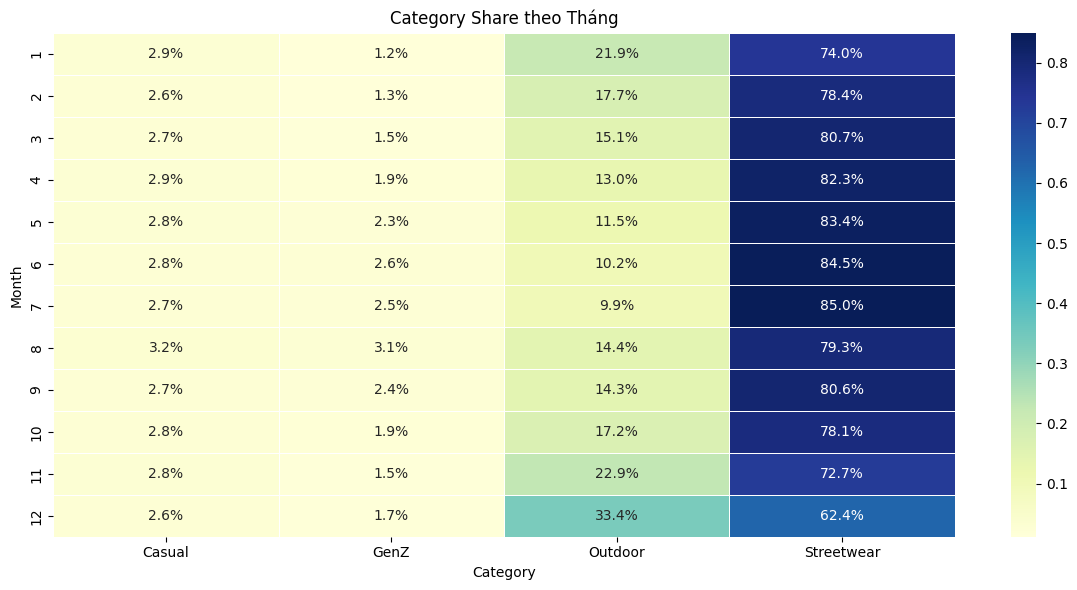

Category month index, >1 nghĩa là tháng mạnh của category đó:


category,Casual,GenZ,Outdoor,Streetwear
month,,,,
1,0.608,0.327,0.846,0.543
2,0.656,0.430,0.837,0.704
3,1.090,0.820,1.107,1.126
4,1.472,1.267,1.222,1.474
5,1.506,1.660,1.123,1.553
6,1.383,1.753,0.944,1.488
7,1.092,1.354,0.750,1.223
8,1.272,1.637,1.047,1.098
9,0.891,1.038,0.864,0.923


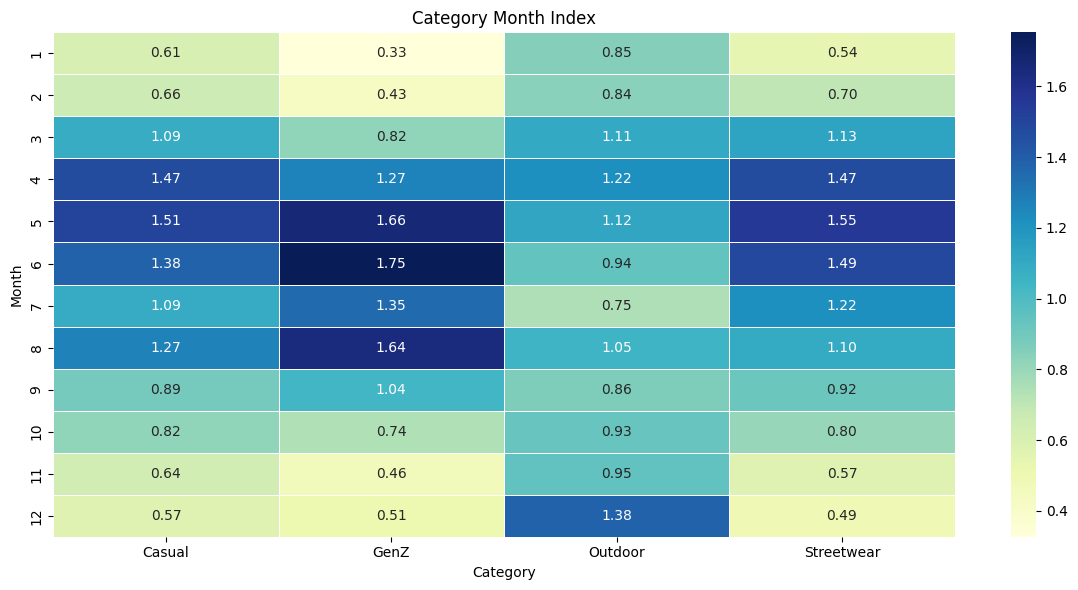

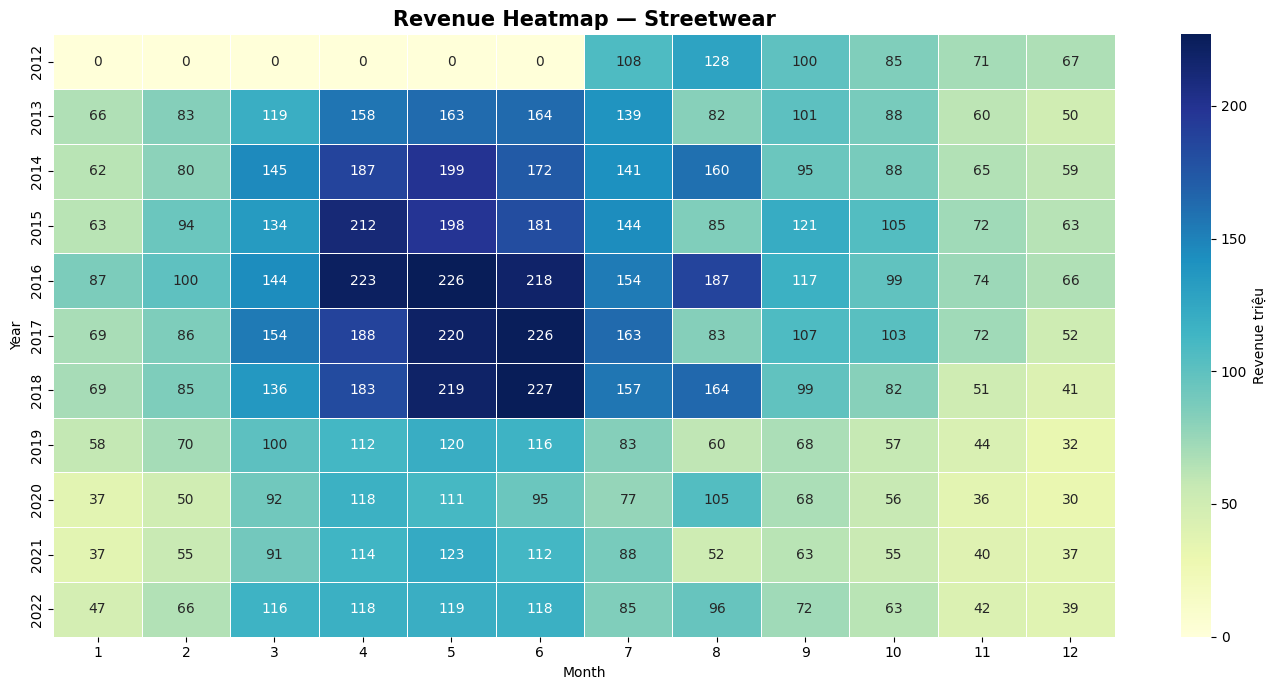

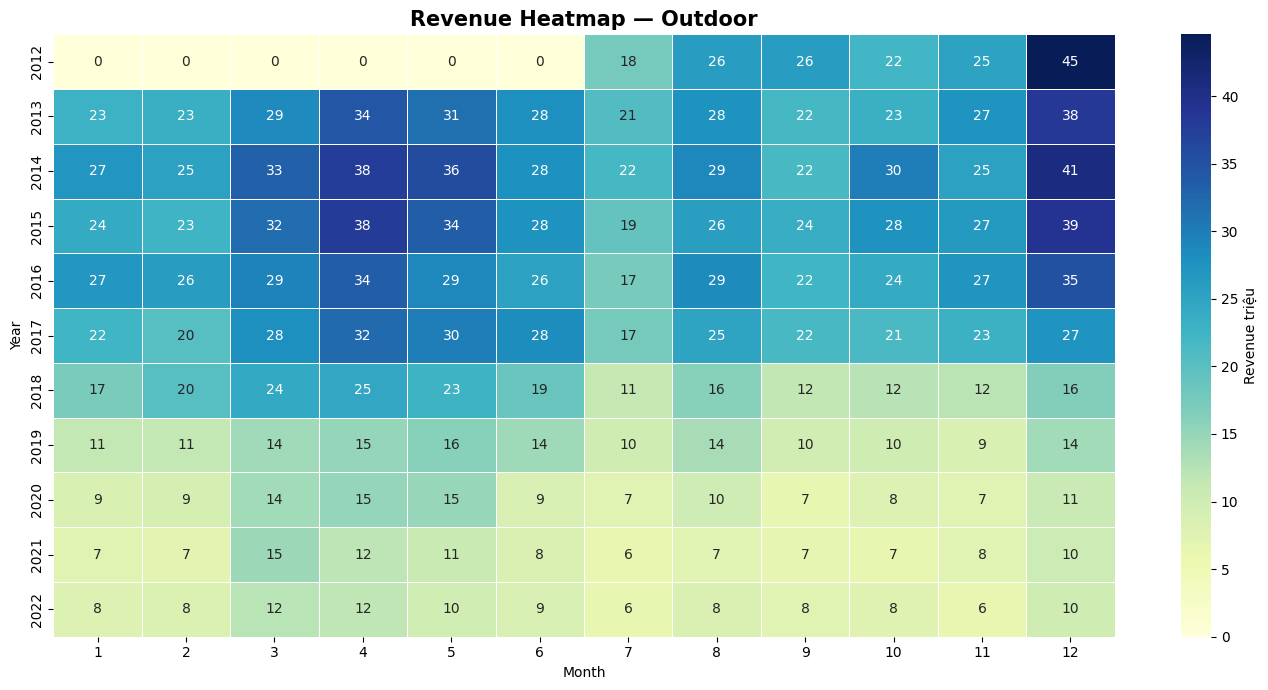

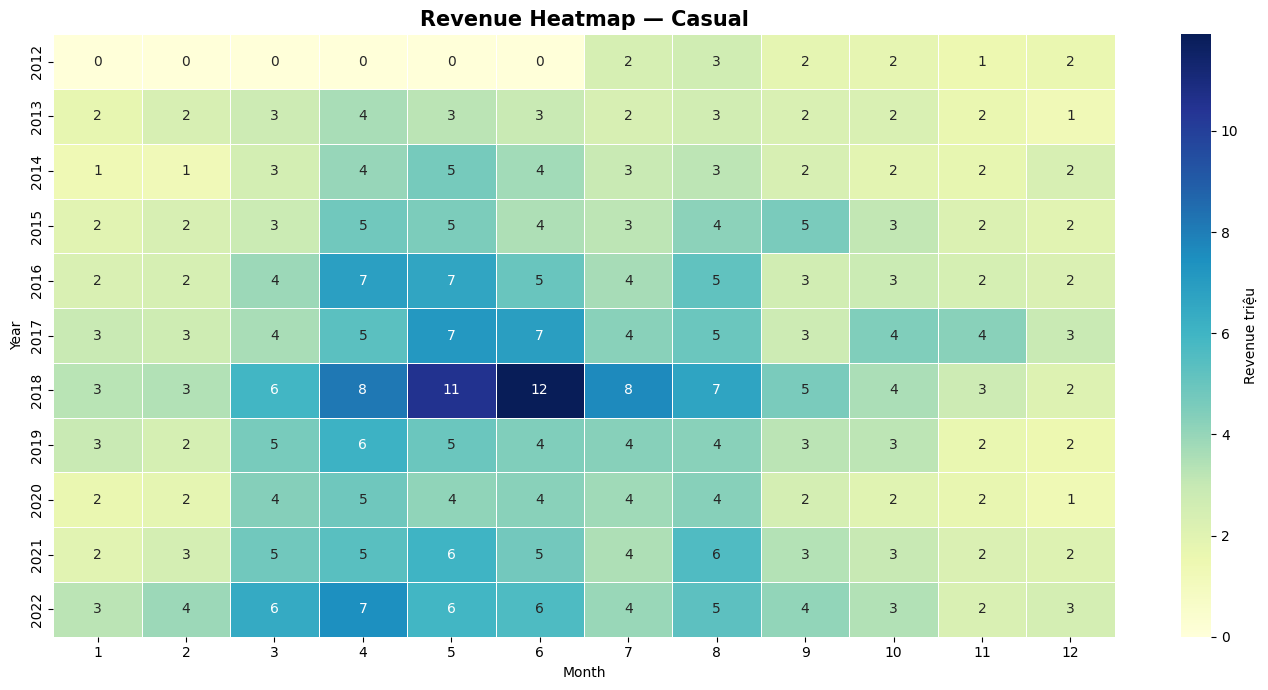

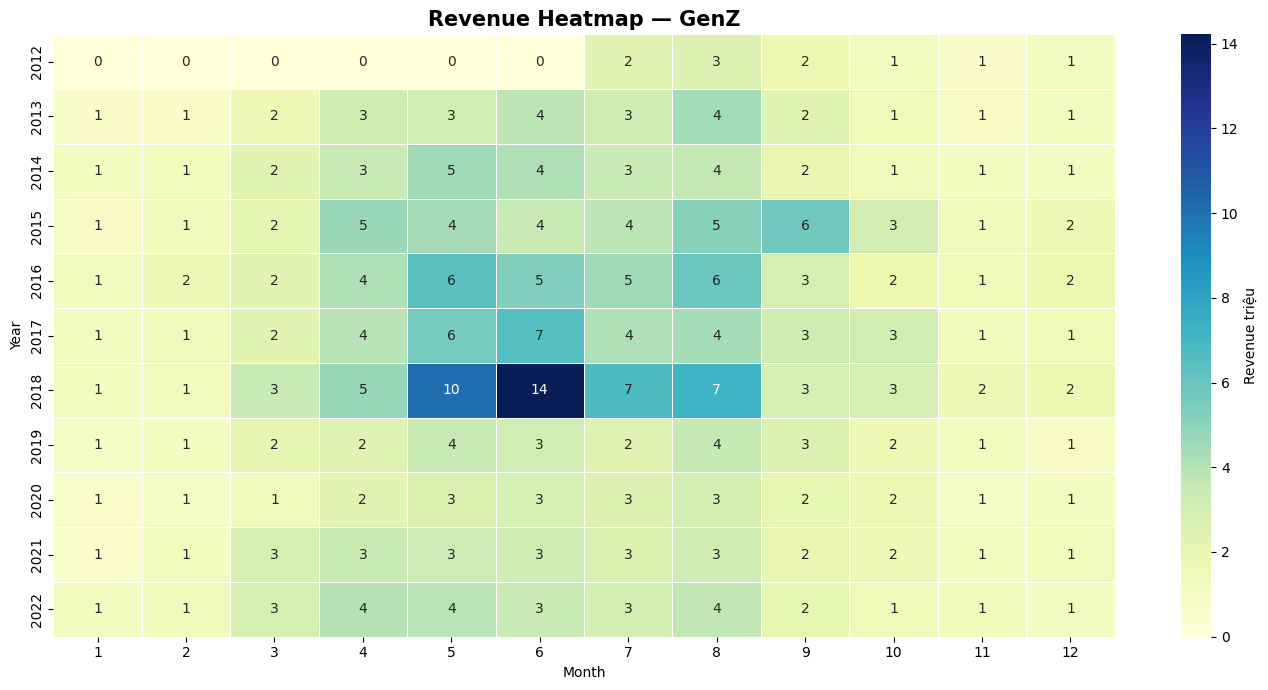

Effective monthly boost từ category settings:


,setting,month_3_effective_boost,month_4_effective_boost,month_5_effective_boost,month_6_effective_boost,month_8_effective_boost
0,balanced_q2,0.000%,2.326%,2.325%,2.328%,0.000%
1,may_peak_light,0.000%,1.850%,2.742%,1.855%,0.000%
2,streetwear_heavy,0.000%,2.664%,3.090%,2.687%,0.000%
3,outdoor_support,0.000%,2.185%,2.648%,2.168%,0.000%
4,q2_plus_aug_light,0.000%,2.120%,2.742%,2.117%,0.468%


Saved: submission_v24_cat_month_balanced_q2.csv
Saved: submission_v24_cat_month_may_peak_light.csv
Saved: submission_v24_cat_month_streetwear_heavy.csv
Saved: submission_v24_cat_month_outdoor_support.csv
Saved: submission_v24_cat_month_q2_plus_aug_light.csv


,file,Revenue_sum,M4_Revenue,M5_Revenue,M6_Revenue,M8_Revenue,Q2_Revenue_sum,Q2_Revenue_share,COGS_sum,COGS/Revenue_mean,Revenue_sum_diff_vs_best,Revenue_sum_diff_pct_vs_best,Mean_abs_daily_Revenue_diff,Max_abs_daily_Revenue_diff
0,submission_v20_q2_m4_0200_m5_0300_m6_0200.csv,"2,245,158,434.83","347,808,307.95","365,390,751.02","342,838,953.96","123,489,581.89","1,056,038,012.93",47.036%,"1,902,184,045.83",0.8504,0.00,0.000%,0.00,0.00
1,submission_v24_cat_month_balanced_q2.csv,"2,244,979,656.95","348,920,291.65","362,996,823.39","343,942,120.01","123,489,581.89","1,055,859,235.05",47.032%,"1,902,131,271.64",0.8504,"-178,777.88",-0.008%,"8,410.73","86,064.37"
2,submission_v24_cat_month_may_peak_light.csv,"2,243,243,692.44","347,296,045.52","364,475,655.90","342,351,569.12","123,489,581.89","1,054,123,270.54",46.991%,"1,900,608,857.36",0.8504,"-1,914,742.39",-0.085%,"3,494.06","32,898.69"
3,submission_v24_cat_month_streetwear_heavy.csv,"2,250,048,142.10","350,070,932.12","365,709,885.32","345,146,902.76","123,489,581.89","1,060,927,720.20",47.151%,"1,906,288,396.81",0.8504,"4,889,707.27",0.218%,"8,922.82","76,133.67"
4,submission_v24_cat_month_outdoor_support.csv,"2,245,106,231.58","348,439,709.57","364,142,743.44","343,403,356.67","123,489,581.89","1,055,985,809.68",47.035%,"1,902,191,402.97",0.8504,"-52,203.25",-0.002%,"4,459.51","44,867.26"
5,submission_v24_cat_month_q2_plus_aug_light.csv,"2,245,625,534.42","348,218,682.23","364,475,655.90","343,232,348.58","124,068,007.70","1,055,926,686.71",47.021%,"1,902,672,657.27",0.8504,"467,099.59",0.021%,"4,192.13","34,864.02"



GỢI Ý:
Current best: submission_v20_q2_m4_0200_m5_0300_m6_0200.csv
Nếu muốn thử category × month an toàn nhất: submission_v24_cat_month_balanced_q2.csv
Nếu balanced tốt hơn: thử submission_v24_cat_month_may_peak_light.csv
Nếu may_peak tốt hơn: thử submission_v24_cat_month_streetwear_heavy.csv
Không thử q2_plus_aug_light trước nếu các bản Q2 chưa tiếp tục tốt.


In [40]:
# ============================================================
# V24 ANALYSIS — Phân tích hướng boost tiếp theo theo Category × Month
#
# Mục tiêu:
# 1. Kiểm tra category nào đóng góp mạnh ở các tháng 4,5,6.
# 2. Xem tháng nào thật sự là tháng trọng yếu theo lịch sử.
# 3. Tạo các candidate boost mới dựa trên category share:
#    - Streetwear-heavy
#    - Outdoor-support
#    - May-peak
#    - Q2 + Aug nhẹ
#
# Yêu cầu:
# - Đã có file best hiện tại: submission_v17_q2_boost_02.csv
# - Đã có base trước boost: submission_v14_month_moe_calibrated_70.csv
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

DATA_DIR = "/kaggle/input/competitions/datathon-2026-round-1/"

BASE_FILE = "submission_v14_month_moe_calibrated_70.csv"
BEST_NOW = "submission_v20_q2_m4_0200_m5_0300_m6_0200.csv"

# ============================================================
# 1. Load data
# ============================================================

orders = pd.read_csv(os.path.join(DATA_DIR, "orders.csv"), low_memory=False)
order_items = pd.read_csv(os.path.join(DATA_DIR, "order_items.csv"), low_memory=False)
products = pd.read_csv(os.path.join(DATA_DIR, "products.csv"), low_memory=False)
sales = pd.read_csv(os.path.join(DATA_DIR, "sales.csv"), low_memory=False)

orders["order_date"] = pd.to_datetime(orders["order_date"])
sales["Date"] = pd.to_datetime(sales["Date"])

trans = (
    order_items
    .merge(
        orders[["order_id", "order_date", "order_status", "order_source", "device_type"]],
        on="order_id",
        how="left"
    )
    .merge(
        products[["product_id", "product_name", "category", "segment", "price", "cogs"]],
        on="product_id",
        how="left"
    )
)

trans["Date"] = pd.to_datetime(trans["order_date"], errors="coerce")
trans = trans.dropna(subset=["Date", "category"]).copy()

for col in ["quantity", "unit_price", "discount_amount", "cogs"]:
    trans[col] = pd.to_numeric(trans[col], errors="coerce").fillna(0)

trans["line_revenue"] = trans["quantity"] * trans["unit_price"]
trans["line_cogs"] = trans["quantity"] * trans["cogs"]
trans["gross_profit"] = trans["line_revenue"] - trans["line_cogs"]

trans["year"] = trans["Date"].dt.year
trans["month"] = trans["Date"].dt.month
trans["category"] = trans["category"].astype(str).str.strip()

trans = trans[
    (trans["Date"] >= "2012-07-04") &
    (trans["Date"] <= "2022-12-31")
].copy()

print("Transaction data:", trans.shape)
display(trans.head())


# ============================================================
# 2. Check data khớp sales.csv
# ============================================================

daily_check = (
    trans
    .groupby("Date", as_index=False)
    .agg(
        revenue_from_items=("line_revenue", "sum"),
        cogs_from_items=("line_cogs", "sum")
    )
)

check = sales.merge(daily_check, on="Date", how="left")

print("MAE Revenue check:", (check["Revenue"] - check["revenue_from_items"]).abs().mean())
print("MAE COGS check   :", (check["COGS"] - check["cogs_from_items"]).abs().mean())


# ============================================================
# 3. Category summary tổng quan
# ============================================================

cat_summary = (
    trans
    .groupby("category", as_index=False)
    .agg(
        Revenue=("line_revenue", "sum"),
        COGS=("line_cogs", "sum"),
        Gross_Profit=("gross_profit", "sum"),
        Units=("quantity", "sum"),
        Orders=("order_id", "nunique"),
        Products=("product_id", "nunique")
    )
)

cat_summary["Revenue_Share"] = cat_summary["Revenue"] / cat_summary["Revenue"].sum()
cat_summary["COGS_Share"] = cat_summary["COGS"] / cat_summary["COGS"].sum()
cat_summary["Gross_Margin"] = cat_summary["Gross_Profit"] / cat_summary["Revenue"]
cat_summary["COGS_Revenue_Ratio"] = cat_summary["COGS"] / cat_summary["Revenue"]

cat_summary = cat_summary.sort_values("Revenue", ascending=False).reset_index(drop=True)

print("Category summary:")
display(
    cat_summary.style.format({
        "Revenue": "{:,.2f}",
        "COGS": "{:,.2f}",
        "Gross_Profit": "{:,.2f}",
        "Units": "{:,.0f}",
        "Orders": "{:,.0f}",
        "Products": "{:,.0f}",
        "Revenue_Share": "{:.2%}",
        "COGS_Share": "{:.2%}",
        "Gross_Margin": "{:.2%}",
        "COGS_Revenue_Ratio": "{:.2%}",
    }).background_gradient(
        subset=["Revenue", "Revenue_Share", "Gross_Margin"],
        cmap="YlGnBu"
    )
)


# ============================================================
# 4. Month strength tổng thể
# ============================================================

month_summary = (
    trans
    .groupby("month", as_index=False)
    .agg(
        Revenue=("line_revenue", "sum"),
        COGS=("line_cogs", "sum"),
        Gross_Profit=("gross_profit", "sum"),
        Units=("quantity", "sum")
    )
)

month_summary["Revenue_Share"] = month_summary["Revenue"] / month_summary["Revenue"].sum()
month_summary["Gross_Margin"] = month_summary["Gross_Profit"] / month_summary["Revenue"]
month_summary["Month_Index_vs_Avg"] = month_summary["Revenue"] / month_summary["Revenue"].mean()

print("Month strength overall:")
display(
    month_summary.style.format({
        "Revenue": "{:,.2f}",
        "COGS": "{:,.2f}",
        "Gross_Profit": "{:,.2f}",
        "Units": "{:,.0f}",
        "Revenue_Share": "{:.2%}",
        "Gross_Margin": "{:.2%}",
        "Month_Index_vs_Avg": "{:.3f}",
    }).background_gradient(
        subset=["Revenue", "Revenue_Share", "Month_Index_vs_Avg"],
        cmap="YlGnBu"
    )
)


# ============================================================
# 5. Category × Month share
# ============================================================

cat_month = (
    trans
    .groupby(["month", "category"], as_index=False)
    .agg(
        Revenue=("line_revenue", "sum"),
        COGS=("line_cogs", "sum"),
        Gross_Profit=("gross_profit", "sum"),
        Units=("quantity", "sum")
    )
)

month_total = (
    cat_month
    .groupby("month", as_index=False)
    .agg(Month_Revenue=("Revenue", "sum"))
)

cat_month = cat_month.merge(month_total, on="month", how="left")
cat_month["Category_Month_Share"] = cat_month["Revenue"] / cat_month["Month_Revenue"]
cat_month["Gross_Margin"] = cat_month["Gross_Profit"] / cat_month["Revenue"]

share_pivot = cat_month.pivot_table(
    index="month",
    columns="category",
    values="Category_Month_Share",
    fill_value=0
)

print("Category share by month:")
display(
    share_pivot.style.format("{:.2%}")
    .background_gradient(cmap="YlGnBu")
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    share_pivot,
    annot=True,
    fmt=".1%",
    cmap="YlGnBu",
    linewidths=0.5
)
plt.title("Category Share theo Tháng")
plt.xlabel("Category")
plt.ylabel("Month")
plt.tight_layout()
plt.show()


# ============================================================
# 6. Category × Month revenue index
#    Index > 1 nghĩa là category đó bán mạnh hơn trung bình tháng của chính nó
# ============================================================

cat_month_revenue = (
    trans
    .groupby(["category", "month"], as_index=False)
    .agg(Revenue=("line_revenue", "sum"))
)

cat_avg = (
    cat_month_revenue
    .groupby("category", as_index=False)
    .agg(Category_Monthly_Avg=("Revenue", "mean"))
)

cat_month_revenue = cat_month_revenue.merge(cat_avg, on="category", how="left")
cat_month_revenue["Cat_Month_Index"] = (
    cat_month_revenue["Revenue"] / cat_month_revenue["Category_Monthly_Avg"]
)

cat_index_pivot = cat_month_revenue.pivot_table(
    index="month",
    columns="category",
    values="Cat_Month_Index",
    fill_value=0
)

print("Category month index, >1 nghĩa là tháng mạnh của category đó:")
display(
    cat_index_pivot.style.format("{:.3f}")
    .background_gradient(cmap="YlGnBu")
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    cat_index_pivot,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5
)
plt.title("Category Month Index")
plt.xlabel("Category")
plt.ylabel("Month")
plt.tight_layout()
plt.show()


# ============================================================
# 7. Year × Month heatmap cho từng category chính
# ============================================================

cat_year_month = (
    trans
    .groupby(["category", "year", "month"], as_index=False)
    .agg(Revenue=("line_revenue", "sum"))
)

main_categories = ["Streetwear", "Outdoor", "Casual", "GenZ"]

for cat in main_categories:
    temp = cat_year_month[cat_year_month["category"] == cat].copy()
    pivot = temp.pivot_table(
        index="year",
        columns="month",
        values="Revenue",
        aggfunc="sum",
        fill_value=0
    ) / 1_000_000

    pivot = pivot.reindex(columns=range(1, 13), fill_value=0)

    plt.figure(figsize=(14, 7))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".0f",
        cmap="YlGnBu",
        linewidths=0.5,
        cbar_kws={"label": "Revenue triệu"}
    )
    plt.title(f"Revenue Heatmap — {cat}", fontsize=15, fontweight="bold")
    plt.xlabel("Month")
    plt.ylabel("Year")
    plt.tight_layout()
    plt.show()


# ============================================================
# 8. Phân tích effective boost nếu boost theo category
# ============================================================

def get_month_multiplier(month, setting, share_pivot):
    """
    setting:
    {
        4: {"Streetwear": 0.025, "Outdoor": 0.020},
        5: {"Streetwear": 0.030, "Outdoor": 0.020},
    }
    """
    if month not in setting:
        return 1.0

    multiplier = 1.0

    for cat, boost in setting[month].items():
        if (cat in share_pivot.columns) and (month in share_pivot.index):
            share = share_pivot.loc[month, cat]
        else:
            share = 0.0

        multiplier += share * boost

    return float(multiplier)


SETTINGS = {
    # Gần với q2_boost_02 nhưng ưu tiên category lớn
    "balanced_q2": {
        4: {"Streetwear": 0.025, "Outdoor": 0.020, "GenZ": 0.005, "Casual": 0.000},
        5: {"Streetwear": 0.025, "Outdoor": 0.020, "GenZ": 0.005, "Casual": 0.000},
        6: {"Streetwear": 0.025, "Outdoor": 0.020, "GenZ": 0.005, "Casual": 0.000},
    },

    # Tháng 5 là peak
    "may_peak_light": {
        4: {"Streetwear": 0.020, "Outdoor": 0.015, "GenZ": 0.005, "Casual": 0.000},
        5: {"Streetwear": 0.030, "Outdoor": 0.020, "GenZ": 0.005, "Casual": 0.000},
        6: {"Streetwear": 0.020, "Outdoor": 0.015, "GenZ": 0.005, "Casual": 0.000},
    },

    # Streetwear là driver chính
    "streetwear_heavy": {
        4: {"Streetwear": 0.030, "Outdoor": 0.015, "GenZ": 0.000, "Casual": 0.000},
        5: {"Streetwear": 0.035, "Outdoor": 0.015, "GenZ": 0.000, "Casual": 0.000},
        6: {"Streetwear": 0.030, "Outdoor": 0.015, "GenZ": 0.000, "Casual": 0.000},
    },

    # Outdoor support mạnh hơn
    "outdoor_support": {
        4: {"Streetwear": 0.0225, "Outdoor": 0.025, "GenZ": 0.005, "Casual": 0.000},
        5: {"Streetwear": 0.0275, "Outdoor": 0.030, "GenZ": 0.005, "Casual": 0.000},
        6: {"Streetwear": 0.0225, "Outdoor": 0.025, "GenZ": 0.005, "Casual": 0.000},
    },

    # 2016-like: Q2 + tháng 8 nhẹ
    "q2_plus_aug_light": {
        4: {"Streetwear": 0.0225, "Outdoor": 0.020, "GenZ": 0.005, "Casual": 0.000},
        5: {"Streetwear": 0.0300, "Outdoor": 0.020, "GenZ": 0.005, "Casual": 0.000},
        6: {"Streetwear": 0.0225, "Outdoor": 0.020, "GenZ": 0.005, "Casual": 0.000},
        8: {"Streetwear": 0.0050, "Outdoor": 0.005, "GenZ": 0.000, "Casual": 0.000},
    },
}

effective_rows = []

for setting_name, setting in SETTINGS.items():
    row = {"setting": setting_name}

    for m in [3, 4, 5, 6, 8]:
        mult = get_month_multiplier(m, setting, share_pivot)
        row[f"month_{m}_effective_boost"] = mult - 1

    effective_rows.append(row)

effective_df = pd.DataFrame(effective_rows)

print("Effective monthly boost từ category settings:")
display(
    effective_df.style.format({
        "month_3_effective_boost": "{:.3%}",
        "month_4_effective_boost": "{:.3%}",
        "month_5_effective_boost": "{:.3%}",
        "month_6_effective_boost": "{:.3%}",
        "month_8_effective_boost": "{:.3%}",
    })
)


# ============================================================
# 9. Generate V24 candidate submissions
# ============================================================

base = pd.read_csv(BASE_FILE)
base["Date"] = pd.to_datetime(base["Date"])
base["month"] = base["Date"].dt.month

best = pd.read_csv(BEST_NOW)
best["Date"] = pd.to_datetime(best["Date"])
best["month"] = best["Date"].dt.month

base_ratio = np.where(
    base["Revenue"] > 0,
    base["COGS"] / base["Revenue"],
    0.85
)
base_ratio = np.clip(base_ratio, 0, 0.98)

created_files = []

for setting_name, setting in SETTINGS.items():
    sub = base[["Date", "Revenue", "COGS"]].copy()
    months = pd.to_datetime(sub["Date"]).dt.month

    multipliers = months.apply(
        lambda m: get_month_multiplier(m, setting, share_pivot)
    ).values

    sub["Revenue"] = sub["Revenue"].values * multipliers
    sub["COGS"] = sub["Revenue"].values * base_ratio

    sub["Revenue"] = sub["Revenue"].clip(lower=0)
    sub["COGS"] = sub["COGS"].clip(lower=0)
    sub["COGS"] = np.minimum(sub["COGS"], sub["Revenue"] * 0.98)

    sub["Revenue"] = sub["Revenue"].round(2)
    sub["COGS"] = sub["COGS"].round(2)

    filename = f"submission_v24_cat_month_{setting_name}.csv"
    sub.to_csv(filename, index=False)
    created_files.append(filename)

    print("Saved:", filename)


# ============================================================
# 10. Compare V24 candidates với current best
# ============================================================

rows = []

for f in [BEST_NOW] + created_files:
    temp = pd.read_csv(f)
    temp["Date"] = pd.to_datetime(temp["Date"])
    temp["month"] = temp["Date"].dt.month

    merged = best.merge(temp, on="Date", suffixes=("_best", "_new"))

    q2_rev = temp[temp["month"].isin([4, 5, 6])]["Revenue"].sum()
    m4_rev = temp[temp["month"] == 4]["Revenue"].sum()
    m5_rev = temp[temp["month"] == 5]["Revenue"].sum()
    m6_rev = temp[temp["month"] == 6]["Revenue"].sum()
    m8_rev = temp[temp["month"] == 8]["Revenue"].sum()
    total_rev = temp["Revenue"].sum()

    rows.append({
        "file": f,
        "Revenue_sum": total_rev,
        "M4_Revenue": m4_rev,
        "M5_Revenue": m5_rev,
        "M6_Revenue": m6_rev,
        "M8_Revenue": m8_rev,
        "Q2_Revenue_sum": q2_rev,
        "Q2_Revenue_share": q2_rev / total_rev,
        "COGS_sum": temp["COGS"].sum(),
        "COGS/Revenue_mean": (temp["COGS"] / temp["Revenue"]).replace([np.inf, -np.inf], np.nan).mean(),
        "Revenue_sum_diff_vs_best": temp["Revenue"].sum() - best["Revenue"].sum(),
        "Revenue_sum_diff_pct_vs_best": temp["Revenue"].sum() / best["Revenue"].sum() - 1,
        "Mean_abs_daily_Revenue_diff": (merged["Revenue_new"] - merged["Revenue_best"]).abs().mean(),
        "Max_abs_daily_Revenue_diff": (merged["Revenue_new"] - merged["Revenue_best"]).abs().max(),
    })

summary = pd.DataFrame(rows)

display(
    summary.style.format({
        "Revenue_sum": "{:,.2f}",
        "M4_Revenue": "{:,.2f}",
        "M5_Revenue": "{:,.2f}",
        "M6_Revenue": "{:,.2f}",
        "M8_Revenue": "{:,.2f}",
        "Q2_Revenue_sum": "{:,.2f}",
        "Q2_Revenue_share": "{:.3%}",
        "COGS_sum": "{:,.2f}",
        "COGS/Revenue_mean": "{:.4f}",
        "Revenue_sum_diff_vs_best": "{:,.2f}",
        "Revenue_sum_diff_pct_vs_best": "{:.3%}",
        "Mean_abs_daily_Revenue_diff": "{:,.2f}",
        "Max_abs_daily_Revenue_diff": "{:,.2f}",
    })
)


# ============================================================
# 11. Gợi ý submit dựa trên logic
# ============================================================

print("\nGỢI Ý:")
print("Current best:", BEST_NOW)
print("Nếu muốn thử category × month an toàn nhất: submission_v24_cat_month_balanced_q2.csv")
print("Nếu balanced tốt hơn: thử submission_v24_cat_month_may_peak_light.csv")
print("Nếu may_peak tốt hơn: thử submission_v24_cat_month_streetwear_heavy.csv")
print("Không thử q2_plus_aug_light trước nếu các bản Q2 chưa tiếp tục tốt.")

In [41]:
# ============================================================
# V26 — AGGRESSIVE REGIME TRANSFER
#
# Ý tưởng:
# - Current best hiện tại: streetwear_heavy.
# - Fine-tune Q2 đã gần trần.
# - Bây giờ thử chuyển seasonal regime toàn năm theo năm mạnh như 2016.
#
# Cách làm:
# - Tính monthly share Revenue lịch sử theo từng năm.
# - Dùng template 2016 / top years / average top years.
# - Với mỗi năm trong test, scale từng tháng để monthly share tiến gần template.
# - COGS giữ theo COGS/Revenue ratio của current best.
#
# Output:
# - Nhiều file submission_v26_regime_*.csv
# ============================================================

import os
import numpy as np
import pandas as pd
from IPython.display import display

DATA_DIR = "/kaggle/input/competitions/datathon-2026-round-1/"

# Current best hiện tại
BEST_NOW = "submission_v24_cat_month_streetwear_heavy.csv"

sales = pd.read_csv(os.path.join(DATA_DIR, "sales.csv"))
sales["Date"] = pd.to_datetime(sales["Date"])
sales["year"] = sales["Date"].dt.year
sales["month"] = sales["Date"].dt.month

base = pd.read_csv(BEST_NOW)
base["Date"] = pd.to_datetime(base["Date"])
base["year"] = base["Date"].dt.year
base["month"] = base["Date"].dt.month

print("Using current best:", BEST_NOW)


# ============================================================
# 1. Historical yearly/monthly pattern
# ============================================================

hist_month = (
    sales
    .groupby(["year", "month"], as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        COGS=("COGS", "sum")
    )
)

# Chỉ lấy các năm đủ 12 tháng
year_month_count = hist_month.groupby("year")["month"].nunique()
full_years = year_month_count[year_month_count == 12].index.tolist()

hist_month_full = hist_month[hist_month["year"].isin(full_years)].copy()

annual = (
    hist_month_full
    .groupby("year", as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        COGS=("COGS", "sum")
    )
)

annual["COGS_Revenue_Ratio"] = annual["COGS"] / annual["Revenue"]
annual = annual.sort_values("Revenue", ascending=False)

print("Annual revenue ranking:")
display(
    annual.style.format({
        "Revenue": "{:,.2f}",
        "COGS": "{:,.2f}",
        "COGS_Revenue_Ratio": "{:.4f}",
    })
)

hist_month_full = hist_month_full.merge(
    annual[["year", "Revenue"]].rename(columns={"Revenue": "Annual_Revenue"}),
    on="year",
    how="left"
)

hist_month_full["month_share"] = hist_month_full["Revenue"] / hist_month_full["Annual_Revenue"]

share_pivot = hist_month_full.pivot_table(
    index="year",
    columns="month",
    values="month_share",
    fill_value=0
)

print("Historical monthly share:")
display(
    share_pivot.style.format("{:.2%}")
    .background_gradient(cmap="YlGnBu")
)


# ============================================================
# 2. Build regime templates
# ============================================================

def normalize_share(s):
    s = pd.Series(s, index=range(1, 13)).fillna(0).astype(float)
    total = s.sum()
    if total <= 0:
        return pd.Series(np.ones(12) / 12, index=range(1, 13))
    return s / total


templates = {}

# Các năm riêng lẻ đáng thử
for y in [2014, 2015, 2016, 2017, 2018, 2022]:
    if y in share_pivot.index:
        templates[str(y)] = normalize_share(share_pivot.loc[y])

# Trung bình top 3 năm doanh thu cao nhất
top3_years = annual.head(3)["year"].tolist()
templates["top3_avg"] = normalize_share(share_pivot.loc[top3_years].mean(axis=0))

# Trung bình 2014-2018, giai đoạn trước khi tụt mạnh
stable_growth_years = [y for y in [2014, 2015, 2016, 2017, 2018] if y in share_pivot.index]
templates["growth_2014_2018_avg"] = normalize_share(share_pivot.loc[stable_growth_years].mean(axis=0))

print("Template years:")
print("top3_years:", top3_years)
print("stable_growth_years:", stable_growth_years)

template_df = pd.DataFrame(templates).T
display(
    template_df.style.format("{:.2%}")
    .background_gradient(cmap="YlGnBu")
)


# ============================================================
# 3. Apply regime transfer to current best
# ============================================================

def apply_regime_template(base_df, template_share, beta=0.5, global_boost=0.0):
    """
    beta:
    - 0.25: nhẹ
    - 0.50: vừa
    - 0.75: liều
    - 1.00: full chuyển sang template

    global_boost:
    - 0.000: giữ tổng Revenue từng năm như base
    - 0.005: tăng tổng năm +0.5%
    - 0.010: tăng tổng năm +1.0%
    """

    out = base_df.copy()

    base_ratio = np.where(
        out["Revenue"] > 0,
        out["COGS"] / out["Revenue"],
        0.85
    )
    base_ratio = np.clip(base_ratio, 0, 0.98)

    out["_base_ratio"] = base_ratio

    for y in sorted(out["year"].unique()):
        year_mask = out["year"] == y
        months_present = sorted(out.loc[year_mask, "month"].unique())

        current_month_sum = (
            out.loc[year_mask]
            .groupby("month")["Revenue"]
            .sum()
        )

        current_year_total = current_month_sum.sum()
        target_year_total = current_year_total * (1 + global_boost)

        # Lấy template cho các tháng có trong năm test.
        # 2024 chỉ có Jan-Jul thì normalize trên Jan-Jul.
        temp_share = template_share.loc[months_present].copy()
        temp_share = temp_share / temp_share.sum()

        for m in months_present:
            m_mask = year_mask & (out["month"] == m)

            current_m_total = current_month_sum.loc[m]
            target_m_total = target_year_total * temp_share.loc[m]

            # Blend giữa monthly total hiện tại và monthly total theo regime
            new_m_total = (1 - beta) * current_m_total + beta * target_m_total

            if current_m_total > 0:
                scale = new_m_total / current_m_total
            else:
                scale = 1.0

            out.loc[m_mask, "Revenue"] *= scale

    # COGS giữ theo ratio gốc của current best
    out["COGS"] = out["Revenue"] * out["_base_ratio"]

    out["Revenue"] = out["Revenue"].clip(lower=0)
    out["COGS"] = out["COGS"].clip(lower=0)
    out["COGS"] = np.minimum(out["COGS"], out["Revenue"] * 0.98)

    out["Revenue"] = out["Revenue"].round(2)
    out["COGS"] = out["COGS"].round(2)

    return out[["Date", "Revenue", "COGS"]]


created_files = []

# Ít file nhưng đủ liều
template_names_to_try = [
    "2016",
    "top3_avg",
    "growth_2014_2018_avg",
]

betas = [0.25, 0.50, 0.75, 1.00]
global_boosts = [0.000, 0.005, 0.010]

for template_name in template_names_to_try:
    if template_name not in templates:
        continue

    for beta in betas:
        for gboost in global_boosts:
            sub = apply_regime_template(
                base,
                templates[template_name],
                beta=beta,
                global_boost=gboost
            )

            filename = (
                f"submission_v26_regime_{template_name}"
                f"_b{int(beta*100):03d}"
                f"_g{int(gboost*1000):03d}.csv"
            )

            sub.to_csv(filename, index=False)
            created_files.append(filename)
            print("Saved:", filename)


# ============================================================
# 4. Compare với current best
# ============================================================

best = base[["Date", "Revenue", "COGS"]].copy()

rows = []

for f in [BEST_NOW] + created_files:
    temp = pd.read_csv(f)
    temp["Date"] = pd.to_datetime(temp["Date"])
    temp["year"] = temp["Date"].dt.year
    temp["month"] = temp["Date"].dt.month

    merged = best.merge(
        temp[["Date", "Revenue", "COGS"]],
        on="Date",
        suffixes=("_best", "_new")
    )

    q2_rev = temp[temp["month"].isin([4, 5, 6])]["Revenue"].sum()
    total_rev = temp["Revenue"].sum()

    rows.append({
        "file": f,
        "Revenue_sum": total_rev,
        "Q2_Revenue_sum": q2_rev,
        "Q2_Revenue_share": q2_rev / total_rev,
        "COGS_sum": temp["COGS"].sum(),
        "COGS/Revenue_mean": (temp["COGS"] / temp["Revenue"]).replace([np.inf, -np.inf], np.nan).mean(),
        "Revenue_sum_diff_vs_best": total_rev - best["Revenue"].sum(),
        "Revenue_sum_diff_pct_vs_best": total_rev / best["Revenue"].sum() - 1,
        "Mean_abs_daily_Revenue_diff": (merged["Revenue_new"] - merged["Revenue_best"]).abs().mean(),
        "Max_abs_daily_Revenue_diff": (merged["Revenue_new"] - merged["Revenue_best"]).abs().max(),
    })

summary = pd.DataFrame(rows)

display(
    summary.style.format({
        "Revenue_sum": "{:,.2f}",
        "Q2_Revenue_sum": "{:,.2f}",
        "Q2_Revenue_share": "{:.3%}",
        "COGS_sum": "{:,.2f}",
        "COGS/Revenue_mean": "{:.4f}",
        "Revenue_sum_diff_vs_best": "{:,.2f}",
        "Revenue_sum_diff_pct_vs_best": "{:.3%}",
        "Mean_abs_daily_Revenue_diff": "{:,.2f}",
        "Max_abs_daily_Revenue_diff": "{:,.2f}",
    })
)

print("\nGợi ý submit:")
print("1. Nếu muốn liều vừa: submission_v26_regime_2016_b025_g000.csv")
print("2. Nếu muốn liều hơn: submission_v26_regime_2016_b050_g000.csv")
print("3. Nếu 2016 tốt: thử bản g005 hoặc b075")
print("4. Nếu 2016 tệ: thử top3_avg_b025_g000")

Using current best: submission_v24_cat_month_streetwear_heavy.csv
Annual revenue ranking:


,year,Revenue,COGS,COGS_Revenue_Ratio
3,2016,"2,104,640,677.54","1,780,559,392.69",0.8460
4,2017,"1,911,164,325.28","1,694,385,793.54",0.8866
2,2015,"1,889,933,826.92","1,665,441,817.42",0.8812
1,2014,"1,871,845,882.80","1,574,607,456.89",0.8412
5,2018,"1,850,122,456.08","1,542,175,766.14",0.8336
0,2013,"1,657,169,417.27","1,465,980,103.20",0.8846
9,2022,"1,169,748,831.69","1,020,420,163.97",0.8723
6,2019,"1,136,801,441.51","1,005,202,883.72",0.8842
7,2020,"1,054,512,158.79","886,085,097.63",0.8403
8,2021,"1,043,039,819.63","941,130,120.16",0.9023


Historical monthly share:


month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2013,5.51%,6.62%,9.16%,12.00%,12.10%,11.98%,10.00%,7.02%,7.70%,6.94%,5.45%,5.51%
2014,4.90%,5.79%,9.80%,12.42%,13.05%,11.12%,9.04%,10.43%,6.44%,6.46%,4.98%,5.54%
2015,4.76%,6.39%,9.04%,13.74%,12.72%,11.42%,9.01%,6.34%,8.20%,7.37%,5.41%,5.60%
2016,5.57%,6.16%,8.51%,12.69%,12.74%,12.07%,8.51%,10.79%,6.90%,6.05%,4.99%,5.02%
2017,4.99%,5.75%,9.86%,12.01%,13.76%,13.99%,9.89%,6.14%,7.06%,6.89%,5.28%,4.38%
2018,4.92%,5.96%,9.19%,11.90%,14.20%,14.68%,9.84%,10.50%,6.38%,5.44%,3.67%,3.31%
2019,6.42%,7.48%,10.66%,11.94%,12.71%,12.12%,8.74%,7.17%,7.33%,6.34%,4.84%,4.26%
2020,4.53%,5.92%,10.60%,13.27%,12.60%,10.49%,8.60%,11.58%,7.48%,6.46%,4.34%,4.14%
2021,4.46%,6.34%,10.86%,12.93%,13.72%,12.31%,9.68%,6.55%,7.18%,6.30%,4.85%,4.83%


Template years:
top3_years: [2016, 2017, 2015]
stable_growth_years: [2014, 2015, 2016, 2017, 2018]


,1,2,3,4,5,6,7,8,9,10,11,12
2014,4.90%,5.79%,9.80%,12.42%,13.05%,11.12%,9.04%,10.43%,6.44%,6.46%,4.98%,5.54%
2015,4.76%,6.39%,9.04%,13.74%,12.72%,11.42%,9.01%,6.34%,8.20%,7.37%,5.41%,5.60%
2016,5.57%,6.16%,8.51%,12.69%,12.74%,12.07%,8.51%,10.79%,6.90%,6.05%,4.99%,5.02%
2017,4.99%,5.75%,9.86%,12.01%,13.76%,13.99%,9.89%,6.14%,7.06%,6.89%,5.28%,4.38%
2018,4.92%,5.96%,9.19%,11.90%,14.20%,14.68%,9.84%,10.50%,6.38%,5.44%,3.67%,3.31%
2022,5.10%,6.76%,11.76%,12.08%,11.89%,11.61%,8.39%,9.71%,7.33%,6.43%,4.46%,4.48%
top3_avg,5.10%,6.10%,9.14%,12.81%,13.07%,12.49%,9.14%,7.76%,7.39%,6.77%,5.23%,5.00%
growth_2014_2018_avg,5.03%,6.01%,9.28%,12.55%,13.29%,12.66%,9.26%,8.84%,7.00%,6.44%,4.87%,4.77%


Saved: submission_v26_regime_2016_b025_g000.csv
Saved: submission_v26_regime_2016_b025_g005.csv
Saved: submission_v26_regime_2016_b025_g010.csv
Saved: submission_v26_regime_2016_b050_g000.csv
Saved: submission_v26_regime_2016_b050_g005.csv
Saved: submission_v26_regime_2016_b050_g010.csv
Saved: submission_v26_regime_2016_b075_g000.csv
Saved: submission_v26_regime_2016_b075_g005.csv
Saved: submission_v26_regime_2016_b075_g010.csv
Saved: submission_v26_regime_2016_b100_g000.csv
Saved: submission_v26_regime_2016_b100_g005.csv
Saved: submission_v26_regime_2016_b100_g010.csv
Saved: submission_v26_regime_top3_avg_b025_g000.csv
Saved: submission_v26_regime_top3_avg_b025_g005.csv
Saved: submission_v26_regime_top3_avg_b025_g010.csv
Saved: submission_v26_regime_top3_avg_b050_g000.csv
Saved: submission_v26_regime_top3_avg_b050_g005.csv
Saved: submission_v26_regime_top3_avg_b050_g010.csv
Saved: submission_v26_regime_top3_avg_b075_g000.csv
Saved: submission_v26_regime_top3_avg_b075_g005.csv
Saved: s

,file,Revenue_sum,Q2_Revenue_sum,Q2_Revenue_share,COGS_sum,COGS/Revenue_mean,Revenue_sum_diff_vs_best,Revenue_sum_diff_pct_vs_best,Mean_abs_daily_Revenue_diff,Max_abs_daily_Revenue_diff
0,submission_v24_cat_month_streetwear_heavy.csv,"2,250,048,142.10","1,060,927,720.20",47.151%,"1,906,288,396.81",0.8504,0.00,0.000%,0.00,0.00
1,submission_v26_regime_2016_b025_g000.csv,"2,250,048,142.10","1,046,589,182.76",46.514%,"1,908,208,359.91",0.8504,0.00,0.000%,"135,845.76","25,331,069.20"
2,submission_v26_regime_2016_b025_g005.csv,"2,252,860,702.27","1,047,843,649.74",46.512%,"1,910,600,820.21",0.8504,"2,812,560.17",0.125%,"134,042.84","25,465,503.90"
3,submission_v26_regime_2016_b025_g010.csv,"2,255,673,262.45","1,049,098,116.70",46.509%,"1,912,993,280.64",0.8504,"5,625,120.35",0.250%,"132,689.86","25,599,938.61"
4,submission_v26_regime_2016_b050_g000.csv,"2,250,048,142.16","1,032,250,645.31",45.877%,"1,910,128,323.05",0.8504,0.06,0.000%,"271,691.52","50,662,138.41"
5,submission_v26_regime_2016_b050_g005.csv,"2,255,673,262.39","1,034,759,579.14",45.874%,"1,914,913,243.59",0.8504,"5,625,120.29",0.250%,"268,085.68","50,931,007.81"
6,submission_v26_regime_2016_b050_g010.csv,"2,261,298,382.88","1,037,268,513.21",45.870%,"1,919,698,164.32",0.8504,"11,250,240.78",0.500%,"265,379.72","51,199,877.21"
7,submission_v26_regime_2016_b075_g000.csv,"2,250,048,142.07","1,017,912,107.84",45.240%,"1,912,048,286.22",0.8504,-0.03,-0.000%,"407,537.28","75,993,207.61"
8,submission_v26_regime_2016_b075_g005.csv,"2,258,485,822.63","1,021,675,508.69",45.237%,"1,919,225,667.14",0.8504,"8,437,680.53",0.375%,"402,128.52","76,396,511.71"
9,submission_v26_regime_2016_b075_g010.csv,"2,266,923,503.18","1,025,438,909.59",45.235%,"1,926,403,047.95",0.8504,"16,875,361.08",0.750%,"398,069.58","76,799,815.82"



Gợi ý submit:
1. Nếu muốn liều vừa: submission_v26_regime_2016_b025_g000.csv
2. Nếu muốn liều hơn: submission_v26_regime_2016_b050_g000.csv
3. Nếu 2016 tốt: thử bản g005 hoặc b075
4. Nếu 2016 tệ: thử top3_avg_b025_g000


### V28

In [42]:
# ============================================================
# V28 — Aggressive Q2 Peak-Day Amplification
#
# Ý tưởng:
# - Current best: V24 streetwear_heavy
# - Q2 đã chứng minh là hướng đúng
# - Streetwear là category chiếm ~80% Revenue
# - Thay vì boost đều Q2, boost mạnh hơn vào các ngày lịch sử
#   Streetwear thường có doanh thu cao trong tháng 4/5/6.
#
# Output:
# - submission_v28_q2_peak_mild.csv
# - submission_v28_q2_peak_mid.csv
# - submission_v28_q2_peak_strong.csv
# - submission_v28_q2_peak_may_yolo.csv
# - submission_v28_q2_peak_q2_yolo.csv
# ============================================================

import os
import numpy as np
import pandas as pd
from IPython.display import display

DATA_DIR = "/kaggle/input/competitions/datathon-2026-round-1/"

BEST_NOW = "/kaggle/input/datasets/qthinhtobie/best-now/submission_v28_q2_peak_q2_yolo.csv"

base = pd.read_csv(BEST_NOW)
base["Date"] = pd.to_datetime(base["Date"])
base["month"] = base["Date"].dt.month
base["day"] = base["Date"].dt.day

print("Using current best:", BEST_NOW)


# ============================================================
# 1. Load transaction data
# ============================================================

orders = pd.read_csv(os.path.join(DATA_DIR, "orders.csv"), low_memory=False)
order_items = pd.read_csv(os.path.join(DATA_DIR, "order_items.csv"), low_memory=False)
products = pd.read_csv(os.path.join(DATA_DIR, "products.csv"), low_memory=False)

orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")

trans = (
    order_items
    .merge(
        orders[["order_id", "order_date"]],
        on="order_id",
        how="left"
    )
    .merge(
        products[["product_id", "category", "cogs"]],
        on="product_id",
        how="left"
    )
)

trans["Date"] = pd.to_datetime(trans["order_date"], errors="coerce")
trans = trans.dropna(subset=["Date", "category"]).copy()

for col in ["quantity", "unit_price", "cogs"]:
    trans[col] = pd.to_numeric(trans[col], errors="coerce").fillna(0)

trans["line_revenue"] = trans["quantity"] * trans["unit_price"]
trans["line_cogs"] = trans["quantity"] * trans["cogs"]

trans["year"] = trans["Date"].dt.year
trans["month"] = trans["Date"].dt.month
trans["day"] = trans["Date"].dt.day
trans["category"] = trans["category"].astype(str).str.strip()

trans = trans[
    (trans["Date"] >= "2012-07-04") &
    (trans["Date"] <= "2022-12-31")
].copy()


# ============================================================
# 2. Tạo day-of-month peak index cho Streetwear Q2
# ============================================================

q2_street = trans[
    (trans["category"] == "Streetwear") &
    (trans["month"].isin([4, 5, 6]))
].copy()

daily_street = (
    q2_street
    .groupby(["year", "month", "day"], as_index=False)
    .agg(Revenue=("line_revenue", "sum"))
)

# Lấy trung bình doanh thu của từng ngày trong tháng qua các năm
day_profile = (
    daily_street
    .groupby(["month", "day"], as_index=False)
    .agg(avg_revenue=("Revenue", "mean"))
)

# Normalize trong từng tháng: index > 1 nghĩa là ngày đó mạnh hơn trung bình tháng
month_avg = (
    day_profile
    .groupby("month", as_index=False)
    .agg(month_day_avg=("avg_revenue", "mean"))
)

day_profile = day_profile.merge(month_avg, on="month", how="left")
day_profile["day_index"] = day_profile["avg_revenue"] / day_profile["month_day_avg"]

# Chỉ lấy phần vượt trung bình
day_profile["peak_score"] = (day_profile["day_index"] - 1).clip(lower=0)

# Normalize peak_score về 0..1 theo từng tháng
def normalize_peak_score(g):
    max_score = g["peak_score"].max()
    if max_score <= 0:
        g["peak_score_norm"] = 0
    else:
        g["peak_score_norm"] = g["peak_score"] / max_score
    return g

day_profile = (
    day_profile
    .groupby("month", group_keys=False)
    .apply(normalize_peak_score)
)

print("Streetwear Q2 day profile:")
display(
    day_profile
    .sort_values(["month", "day"])
    .style.format({
        "avg_revenue": "{:,.2f}",
        "month_day_avg": "{:,.2f}",
        "day_index": "{:.3f}",
        "peak_score": "{:.3f}",
        "peak_score_norm": "{:.3f}",
    })
)


# ============================================================
# 3. Merge peak score vào test dates
# ============================================================

test_peak = base[["Date", "month", "day"]].merge(
    day_profile[["month", "day", "day_index", "peak_score_norm"]],
    on=["month", "day"],
    how="left"
)

test_peak["day_index"] = test_peak["day_index"].fillna(1.0)
test_peak["peak_score_norm"] = test_peak["peak_score_norm"].fillna(0.0)

base_ratio = np.where(
    base["Revenue"] > 0,
    base["COGS"] / base["Revenue"],
    0.85
)
base_ratio = np.clip(base_ratio, 0, 0.98)


# ============================================================
# 4. Define aggressive settings
# ============================================================

SETTINGS = {
    # Nhẹ: chỉ thêm peak boost nhỏ trong Q2
    "mild": {
        4: {"base_extra": 0.000, "peak_extra": 0.015},
        5: {"base_extra": 0.000, "peak_extra": 0.020},
        6: {"base_extra": 0.000, "peak_extra": 0.015},
    },

    # Vừa: thêm một ít level + peak boost
    "mid": {
        4: {"base_extra": 0.005, "peak_extra": 0.020},
        5: {"base_extra": 0.007, "peak_extra": 0.030},
        6: {"base_extra": 0.005, "peak_extra": 0.020},
    },

    # Mạnh: Q2 tiếp tục tăng, peak ngày mạnh tăng rõ hơn
    "strong": {
        4: {"base_extra": 0.010, "peak_extra": 0.030},
        5: {"base_extra": 0.012, "peak_extra": 0.045},
        6: {"base_extra": 0.010, "peak_extra": 0.030},
    },

    # Liều tập trung tháng 5
    "may_yolo": {
        4: {"base_extra": 0.003, "peak_extra": 0.015},
        5: {"base_extra": 0.015, "peak_extra": 0.060},
        6: {"base_extra": 0.003, "peak_extra": 0.015},
    },

    # Liều toàn Q2
    "q2_yolo": {
        4: {"base_extra": 0.015, "peak_extra": 0.045},
        5: {"base_extra": 0.020, "peak_extra": 0.070},
        6: {"base_extra": 0.015, "peak_extra": 0.045},
    },
}


# ============================================================
# 5. Generate submissions
# ============================================================

created_files = []

for setting_name, setting in SETTINGS.items():
    sub = base[["Date", "Revenue", "COGS"]].copy()
    sub_month = base["month"].values
    peak_score = test_peak["peak_score_norm"].values

    multiplier = np.ones(len(sub))

    for m in [4, 5, 6]:
        mask = sub_month == m

        base_extra = setting[m]["base_extra"]
        peak_extra = setting[m]["peak_extra"]

        multiplier[mask] = (
            1
            + base_extra
            + peak_extra * peak_score[mask]
        )

    sub["Revenue"] = sub["Revenue"].values * multiplier
    sub["COGS"] = sub["Revenue"].values * base_ratio

    sub["Revenue"] = sub["Revenue"].clip(lower=0)
    sub["COGS"] = sub["COGS"].clip(lower=0)
    sub["COGS"] = np.minimum(sub["COGS"], sub["Revenue"] * 0.98)

    sub["Revenue"] = sub["Revenue"].round(2)
    sub["COGS"] = sub["COGS"].round(2)

    filename = f"submission_v28_q2_peak_{setting_name}.csv"
    sub.to_csv(filename, index=False)
    created_files.append(filename)

    print("Saved:", filename)


# ============================================================
# 6. Compare with current best
# ============================================================

rows = []

for f in [BEST_NOW] + created_files:
    temp = pd.read_csv(f)
    temp["Date"] = pd.to_datetime(temp["Date"])
    temp["month"] = temp["Date"].dt.month

    merged = base[["Date", "Revenue", "COGS"]].merge(
        temp[["Date", "Revenue", "COGS"]],
        on="Date",
        suffixes=("_best", "_new")
    )

    q2_rev = temp[temp["month"].isin([4, 5, 6])]["Revenue"].sum()
    m4_rev = temp[temp["month"] == 4]["Revenue"].sum()
    m5_rev = temp[temp["month"] == 5]["Revenue"].sum()
    m6_rev = temp[temp["month"] == 6]["Revenue"].sum()
    total_rev = temp["Revenue"].sum()

    rows.append({
        "file": f,
        "Revenue_sum": total_rev,
        "M4_Revenue": m4_rev,
        "M5_Revenue": m5_rev,
        "M6_Revenue": m6_rev,
        "Q2_Revenue_sum": q2_rev,
        "Q2_Revenue_share": q2_rev / total_rev,
        "COGS_sum": temp["COGS"].sum(),
        "COGS/Revenue_mean": (temp["COGS"] / temp["Revenue"]).replace([np.inf, -np.inf], np.nan).mean(),
        "Revenue_sum_diff_vs_best": total_rev - base["Revenue"].sum(),
        "Revenue_sum_diff_pct_vs_best": total_rev / base["Revenue"].sum() - 1,
        "Mean_abs_daily_Revenue_diff": (merged["Revenue_new"] - merged["Revenue_best"]).abs().mean(),
        "Max_abs_daily_Revenue_diff": (merged["Revenue_new"] - merged["Revenue_best"]).abs().max(),
    })

summary = pd.DataFrame(rows)

display(
    summary.style.format({
        "Revenue_sum": "{:,.2f}",
        "M4_Revenue": "{:,.2f}",
        "M5_Revenue": "{:,.2f}",
        "M6_Revenue": "{:,.2f}",
        "Q2_Revenue_sum": "{:,.2f}",
        "Q2_Revenue_share": "{:.3%}",
        "COGS_sum": "{:,.2f}",
        "COGS/Revenue_mean": "{:.4f}",
        "Revenue_sum_diff_vs_best": "{:,.2f}",
        "Revenue_sum_diff_pct_vs_best": "{:.3%}",
        "Mean_abs_daily_Revenue_diff": "{:,.2f}",
        "Max_abs_daily_Revenue_diff": "{:,.2f}",
    })
)

print("\nGợi ý submit:")
print("Current best:", BEST_NOW)
print("1. Liều vừa: submission_v28_q2_peak_mid.csv")
print("2. Nếu mid tốt: submission_v28_q2_peak_strong.csv")
print("3. Nếu mid tệ nhưng muốn thử may-only: submission_v28_q2_peak_may_yolo.csv")
print("4. q2_yolo chỉ nộp nếu strong tăng rõ.")

Using current best: /kaggle/input/datasets/qthinhtobie/best-now/submission_v28_q2_peak_q2_yolo.csv
Streetwear Q2 day profile:


,month,day,avg_revenue,month_day_avg,day_index,peak_score,peak_score_norm
0,4,1,"8,611,355.32","5,376,814.81",1.602,0.602,0.668
1,4,2,"8,196,853.85","5,376,814.81",1.524,0.524,0.582
2,4,3,"7,180,002.15","5,376,814.81",1.335,0.335,0.372
3,4,4,"2,686,847.77","5,376,814.81",0.500,0.000,0.000
4,4,5,"2,871,521.29","5,376,814.81",0.534,0.000,0.000
5,4,6,"3,159,049.27","5,376,814.81",0.588,0.000,0.000
6,4,7,"3,170,045.95","5,376,814.81",0.590,0.000,0.000
7,4,8,"3,593,828.84","5,376,814.81",0.668,0.000,0.000
8,4,9,"3,766,451.88","5,376,814.81",0.700,0.000,0.000
9,4,10,"3,778,359.56","5,376,814.81",0.703,0.000,0.000


Saved: submission_v28_q2_peak_mild.csv
Saved: submission_v28_q2_peak_mid.csv
Saved: submission_v28_q2_peak_strong.csv
Saved: submission_v28_q2_peak_may_yolo.csv
Saved: submission_v28_q2_peak_q2_yolo.csv


,file,Revenue_sum,M4_Revenue,M5_Revenue,M6_Revenue,Q2_Revenue_sum,Q2_Revenue_share,COGS_sum,COGS/Revenue_mean,Revenue_sum_diff_vs_best,Revenue_sum_diff_pct_vs_best,Mean_abs_daily_Revenue_diff,Max_abs_daily_Revenue_diff
0,/kaggle/input/datasets/qthinhtobie/best-now/submission_v28_q2_peak_q2_yolo.csv,"2,289,766,567.59","362,220,475.17","382,331,331.86","356,094,338.66","1,100,646,145.69",48.068%,"1,938,883,118.95",0.8504,0.00,0.000%,0.00,0.00
1,submission_v28_q2_peak_mild.csv,"2,293,419,598.26","363,456,682.45","383,773,905.04","357,068,588.87","1,104,299,176.36",48.151%,"1,941,858,118.09",0.8504,"3,653,030.67",0.160%,"6,666.11","297,224.32"
2,submission_v28_q2_peak_mid.csv,"2,301,145,597.38","365,679,853.92","387,171,510.95","359,173,810.61","1,112,025,175.48",48.325%,"1,948,209,953.93",0.8504,"11,379,029.79",0.497%,"20,764.65","549,864.99"
3,submission_v28_q2_peak_strong.csv,"2,309,204,396.22","368,315,094.41","390,165,097.48","361,603,782.43","1,120,083,974.32",48.505%,"1,954,844,790.05",0.8504,"19,437,828.63",0.849%,"35,470.49","847,089.31"
4,submission_v28_q2_peak_may_yolo.csv,"2,304,194,658.99","364,543,343.88","392,394,021.33","358,136,871.88","1,115,074,237.09",48.393%,"1,950,571,338.27",0.8504,"14,428,091.40",0.630%,"26,328.63","1,114,591.20"
5,submission_v28_q2_peak_q2_yolo.csv,"2,319,868,294.90","371,362,404.09","395,026,964.56","364,358,504.35","1,130,747,873.00",48.742%,"1,963,582,289.38",0.8504,"30,101,727.31",1.315%,"54,930.16","1,337,509.44"



Gợi ý submit:
Current best: /kaggle/input/datasets/qthinhtobie/best-now/submission_v28_q2_peak_q2_yolo.csv
1. Liều vừa: submission_v28_q2_peak_mid.csv
2. Nếu mid tốt: submission_v28_q2_peak_strong.csv
3. Nếu mid tệ nhưng muốn thử may-only: submission_v28_q2_peak_may_yolo.csv
4. q2_yolo chỉ nộp nếu strong tăng rõ.


### V30

In [43]:
# ============================================================
# V30 — Projected Recurring Promotions
#
# Insight:
# promotions.csv chỉ đến 2022, nhưng campaign có pattern lặp năm.
# Nếu test 2023-2024 bị promo = 0 thì forecast sẽ underpredict
# những giai đoạn như Spring Sale, Mid-Year Sale, Urban Blowout.
#
# Current best:
# submission_v28_q2_peak_q2_yolo.csv
# ============================================================

import os
import re
import numpy as np
import pandas as pd
from IPython.display import display

DATA_DIR = "/kaggle/input/competitions/datathon-2026-round-1/"

BEST_NOW = "submission_v28_q2_peak_q2_yolo.csv"

base = pd.read_csv(BEST_NOW)
base["Date"] = pd.to_datetime(base["Date"])
base["month"] = base["Date"].dt.month

promotions = pd.read_csv(os.path.join(DATA_DIR, "promotions.csv"))
promotions["start_date"] = pd.to_datetime(promotions["start_date"])
promotions["end_date"] = pd.to_datetime(promotions["end_date"])

# Lấy tên campaign gốc: bỏ năm ở cuối
promotions["promo_family"] = promotions["promo_name"].str.replace(
    r"\s+\d{4}$", "", regex=True
)

promotions["start_md"] = promotions["start_date"].dt.strftime("%m-%d")
promotions["end_md"] = promotions["end_date"].dt.strftime("%m-%d")
promotions["start_year"] = promotions["start_date"].dt.year

print("Promotion families:")
display(
    promotions.groupby("promo_family")
    .agg(
        count=("promo_id", "count"),
        years=("start_year", lambda x: sorted(x.unique().tolist())),
        start_md_mode=("start_md", lambda x: x.mode().iloc[0]),
        end_md_mode=("end_md", lambda x: x.mode().iloc[0]),
        avg_discount=("discount_value", "mean"),
        category=("applicable_category", lambda x: x.dropna().unique().tolist())
    )
    .reset_index()
)


# ============================================================
# 1. Tạo future promo calendar 2023-2024
# ============================================================

def make_date_from_md(year, md):
    mm, dd = map(int, md.split("-"))
    return pd.Timestamp(year=year, month=mm, day=dd)


def build_future_promos(promotions, future_years=[2023, 2024]):
    rows = []

    family_info = (
        promotions
        .groupby("promo_family")
        .agg(
            start_md=("start_md", lambda x: x.mode().iloc[0]),
            end_md=("end_md", lambda x: x.mode().iloc[0]),
            avg_discount=("discount_value", "mean"),
            applicable_category=("applicable_category", lambda x: x.dropna().iloc[0] if len(x.dropna()) else "ALL"),
            count=("promo_id", "count"),
            years=("start_year", lambda x: sorted(x.unique().tolist()))
        )
        .reset_index()
    )

    for _, r in family_info.iterrows():
        family = r["promo_family"]
        start_md = r["start_md"]
        end_md = r["end_md"]

        observed_years = r["years"]

        for y in future_years:
            # Campaign năm nào cũng có
            yearly_campaign = family in [
                "Spring Sale",
                "Mid-Year Sale",
                "Fall Launch",
                "Year-End Sale"
            ]

            # Campaign 2 năm/lần, thường rơi vào năm lẻ
            odd_year_campaign = family in [
                "Urban Blowout",
                "Rural Special"
            ]

            if yearly_campaign:
                use_this_year = True
            elif odd_year_campaign:
                use_this_year = (y % 2 == 1)
            else:
                use_this_year = False

            if not use_this_year:
                continue

            start_date = make_date_from_md(y, start_md)
            end_date = make_date_from_md(y, end_md)

            # Xử lý campaign qua năm mới như Year-End
            if end_date < start_date:
                end_date = make_date_from_md(y + 1, end_md)

            for d in pd.date_range(start_date, end_date, freq="D"):
                rows.append({
                    "Date": d,
                    "promo_family": family,
                    "applicable_category": r["applicable_category"],
                    "avg_discount": r["avg_discount"]
                })

    future = pd.DataFrame(rows)

    if future.empty:
        return future

    # Giới hạn đúng sample range
    future = future[
        (future["Date"] >= base["Date"].min()) &
        (future["Date"] <= base["Date"].max())
    ].copy()

    return future


future_promos = build_future_promos(promotions)

print("Future projected promos:")
display(future_promos.head(20))
display(
    future_promos.groupby("promo_family")
    .agg(
        start=("Date", "min"),
        end=("Date", "max"),
        days=("Date", "nunique"),
        avg_discount=("avg_discount", "mean"),
        category=("applicable_category", lambda x: x.dropna().unique().tolist())
    )
    .reset_index()
)


# ============================================================
# 2. Apply promo boosts
# ============================================================

base_ratio = np.where(
    base["Revenue"] > 0,
    base["COGS"] / base["Revenue"],
    0.85
)
base_ratio = np.clip(base_ratio, 0, 0.98)


def apply_projected_promo_boost(base_df, boost_map, filename, cap=1.12):
    sub = base_df[["Date", "Revenue", "COGS"]].copy()

    promo_daily = future_promos.copy()

    if promo_daily.empty:
        sub.to_csv(filename, index=False)
        return sub

    promo_daily["boost"] = promo_daily["promo_family"].map(boost_map).fillna(0.0)

    daily_boost = (
        promo_daily
        .groupby("Date", as_index=False)
        .agg(total_boost=("boost", "sum"))
    )

    sub = sub.merge(daily_boost, on="Date", how="left")
    sub["total_boost"] = sub["total_boost"].fillna(0.0)

    # Cap để tránh overlap promo làm tăng quá đà
    multiplier = (1 + sub["total_boost"]).clip(upper=cap)

    sub["Revenue"] = sub["Revenue"] * multiplier
    sub["COGS"] = sub["Revenue"] * base_ratio

    sub["Revenue"] = sub["Revenue"].clip(lower=0)
    sub["COGS"] = sub["COGS"].clip(lower=0)
    sub["COGS"] = np.minimum(sub["COGS"], sub["Revenue"] * 0.98)

    sub["Revenue"] = sub["Revenue"].round(2)
    sub["COGS"] = sub["COGS"].round(2)

    sub = sub[["Date", "Revenue", "COGS"]]
    sub.to_csv(filename, index=False)

    print("Saved:", filename)
    return sub


# ============================================================
# 3. Candidate settings
# ============================================================

SETTINGS = {
    # Tập trung các promo mà q2_yolo còn chưa cover đủ: Mid-Year kéo sang July, Urban kéo sang Aug
    "midyear_urban": {
        "Spring Sale": 0.005,
        "Mid-Year Sale": 0.020,
        "Urban Blowout": 0.020,
        "Fall Launch": 0.005,
        "Rural Special": 0.000,
        "Year-End Sale": 0.000,
    },

    # Nhẹ hơn, kiểm tra giả thuyết promo recurring
    "all_mild": {
        "Spring Sale": 0.005,
        "Mid-Year Sale": 0.012,
        "Urban Blowout": 0.012,
        "Fall Launch": 0.005,
        "Rural Special": 0.005,
        "Year-End Sale": 0.000,
    },

    # Tập trung Mid-Year Sale vì nằm giữa Q2 và July
    "midyear_focus": {
        "Spring Sale": 0.000,
        "Mid-Year Sale": 0.030,
        "Urban Blowout": 0.000,
        "Fall Launch": 0.000,
        "Rural Special": 0.000,
        "Year-End Sale": 0.000,
    },

    # Tập trung Urban Blowout Streetwear, kiểm tra tháng 8
    "urban_focus": {
        "Spring Sale": 0.000,
        "Mid-Year Sale": 0.010,
        "Urban Blowout": 0.035,
        "Fall Launch": 0.005,
        "Rural Special": 0.000,
        "Year-End Sale": 0.000,
    },

    # Liều hơn
    "promo_yolo": {
        "Spring Sale": 0.010,
        "Mid-Year Sale": 0.035,
        "Urban Blowout": 0.040,
        "Fall Launch": 0.010,
        "Rural Special": 0.005,
        "Year-End Sale": 0.000,
    },
}

created_files = []

for name, boost_map in SETTINGS.items():
    filename = f"submission_v30_projected_promos_{name}.csv"
    apply_projected_promo_boost(base, boost_map, filename)
    created_files.append(filename)


# ============================================================
# 4. Compare với current best
# ============================================================

best = base[["Date", "Revenue", "COGS"]].copy()

rows = []

for f in [BEST_NOW] + created_files:
    temp = pd.read_csv(f)
    temp["Date"] = pd.to_datetime(temp["Date"])
    temp["month"] = temp["Date"].dt.month

    merged = best.merge(
        temp[["Date", "Revenue", "COGS"]],
        on="Date",
        suffixes=("_best", "_new")
    )

    q2_rev = temp[temp["month"].isin([4, 5, 6])]["Revenue"].sum()
    july_rev = temp[temp["month"] == 7]["Revenue"].sum()
    aug_rev = temp[temp["month"] == 8]["Revenue"].sum()
    total_rev = temp["Revenue"].sum()

    rows.append({
        "file": f,
        "Revenue_sum": total_rev,
        "Q2_Revenue_sum": q2_rev,
        "July_Revenue": july_rev,
        "Aug_Revenue": aug_rev,
        "COGS_sum": temp["COGS"].sum(),
        "COGS/Revenue_mean": (temp["COGS"] / temp["Revenue"]).replace([np.inf, -np.inf], np.nan).mean(),
        "Revenue_sum_diff_vs_best": total_rev - best["Revenue"].sum(),
        "Revenue_sum_diff_pct_vs_best": total_rev / best["Revenue"].sum() - 1,
        "Mean_abs_daily_Revenue_diff": (merged["Revenue_new"] - merged["Revenue_best"]).abs().mean(),
        "Max_abs_daily_Revenue_diff": (merged["Revenue_new"] - merged["Revenue_best"]).abs().max(),
    })

summary = pd.DataFrame(rows)

display(
    summary.style.format({
        "Revenue_sum": "{:,.2f}",
        "Q2_Revenue_sum": "{:,.2f}",
        "July_Revenue": "{:,.2f}",
        "Aug_Revenue": "{:,.2f}",
        "COGS_sum": "{:,.2f}",
        "COGS/Revenue_mean": "{:.4f}",
        "Revenue_sum_diff_vs_best": "{:,.2f}",
        "Revenue_sum_diff_pct_vs_best": "{:.3%}",
        "Mean_abs_daily_Revenue_diff": "{:,.2f}",
        "Max_abs_daily_Revenue_diff": "{:,.2f}",
    })
)

print("\nCurrent best:", BEST_NOW)
print("Submit order đề xuất:")
print("1. submission_v30_projected_promos_midyear_urban.csv")
print("2. Nếu tốt: submission_v30_projected_promos_promo_yolo.csv")
print("3. Nếu midyear_urban tệ: thử submission_v30_projected_promos_midyear_focus.csv")
print("4. urban_focus chỉ thử nếu nghi tháng 8/Urban Blowout đang thiếu.")

Promotion families:


,promo_family,count,years,start_md_mode,end_md_mode,avg_discount,category
0,Fall Launch,10,"[2013, 2014, 2015, 2016, 2017, 2018, 2019, 202...",08-30,10-01,10.0,[]
1,Mid-Year Sale,10,"[2013, 2014, 2015, 2016, 2017, 2018, 2019, 202...",06-23,07-22,18.0,[]
2,Rural Special,5,"[2013, 2015, 2017, 2019, 2021]",01-30,03-01,15.0,[Outdoor]
3,Spring Sale,10,"[2013, 2014, 2015, 2016, 2017, 2018, 2019, 202...",03-18,04-17,12.0,[]
4,Urban Blowout,5,"[2013, 2015, 2017, 2019, 2021]",07-30,09-02,50.0,[Streetwear]
5,Year-End Sale,10,"[2013, 2014, 2015, 2016, 2017, 2018, 2019, 202...",11-18,01-02,20.0,[]


Future projected promos:


,Date,promo_family,applicable_category,avg_discount
0,2023-08-30,Fall Launch,ALL,10.0
1,2023-08-31,Fall Launch,ALL,10.0
2,2023-09-01,Fall Launch,ALL,10.0
3,2023-09-02,Fall Launch,ALL,10.0
4,2023-09-03,Fall Launch,ALL,10.0
5,2023-09-04,Fall Launch,ALL,10.0
6,2023-09-05,Fall Launch,ALL,10.0
7,2023-09-06,Fall Launch,ALL,10.0
8,2023-09-07,Fall Launch,ALL,10.0
9,2023-09-08,Fall Launch,ALL,10.0


,promo_family,start,end,days,avg_discount,category
0,Fall Launch,2023-08-30,2023-10-01,33,10.0,[ALL]
1,Mid-Year Sale,2023-06-23,2024-07-01,39,18.0,[ALL]
2,Rural Special,2023-01-30,2023-03-01,31,15.0,[Outdoor]
3,Spring Sale,2023-03-18,2024-04-17,62,12.0,[ALL]
4,Urban Blowout,2023-07-30,2023-09-02,35,50.0,[Streetwear]
5,Year-End Sale,2023-11-18,2024-01-02,46,20.0,[ALL]


Saved: submission_v30_projected_promos_midyear_urban.csv
Saved: submission_v30_projected_promos_all_mild.csv
Saved: submission_v30_projected_promos_midyear_focus.csv
Saved: submission_v30_projected_promos_urban_focus.csv
Saved: submission_v30_projected_promos_promo_yolo.csv


,file,Revenue_sum,Q2_Revenue_sum,July_Revenue,Aug_Revenue,COGS_sum,COGS/Revenue_mean,Revenue_sum_diff_vs_best,Revenue_sum_diff_pct_vs_best,Mean_abs_daily_Revenue_diff,Max_abs_daily_Revenue_diff
0,submission_v28_q2_peak_q2_yolo.csv,"2,319,868,294.90","1,130,747,873.00","136,045,913.98","123,489,581.89","1,963,582,289.38",0.8504,0.00,0.000%,0.00,0.00
1,submission_v30_projected_promos_midyear_urban.csv,"2,329,002,356.51","1,133,776,600.40","138,124,449.64","126,032,610.05","1,971,912,227.55",0.8504,"9,134,061.61",0.394%,"16,668.00","210,096.99"
2,submission_v30_projected_promos_all_mild.csv,"2,326,778,284.13","1,132,936,981.13","137,293,035.38","125,044,693.40","1,969,818,504.52",0.8504,"6,909,989.23",0.298%,"12,609.47","126,534.51"
3,submission_v30_projected_promos_midyear_focus.csv,"2,325,803,699.72","1,133,896,445.17","138,832,746.63","123,489,581.89","1,968,943,569.58",0.8504,"5,935,404.82",0.256%,"10,831.03","315,145.48"
4,submission_v30_projected_promos_urban_focus.csv,"2,327,440,149.12","1,131,797,397.04","137,360,990.86","127,884,953.78","1,970,598,403.41",0.8504,"7,571,854.22",0.326%,"13,817.25","297,728.27"
5,submission_v30_projected_promos_promo_yolo.csv,"2,337,648,213.22","1,136,280,565.81","139,738,513.21","128,575,638.21","1,979,757,739.07",0.8504,"17,779,918.32",0.766%,"32,445.11","372,160.33"



Current best: submission_v28_q2_peak_q2_yolo.csv
Submit order đề xuất:
1. submission_v30_projected_promos_midyear_urban.csv
2. Nếu tốt: submission_v30_projected_promos_promo_yolo.csv
3. Nếu midyear_urban tệ: thử submission_v30_projected_promos_midyear_focus.csv
4. urban_focus chỉ thử nếu nghi tháng 8/Urban Blowout đang thiếu.


### V31

In [44]:
# ============================================================
# V31 — COGS-only Adjustment for Q2 / Streetwear Peak
#
# Ý tưởng:
# - Revenue best hiện tại đã tốt: submission_v28_q2_peak_q2_yolo.csv
# - Không đụng Revenue nữa.
# - Chỉ chỉnh COGS trong Q2/peak days.
# - Vì Streetwear chiếm ~80% Revenue và có COGS/Revenue cao,
#   nếu Q2 boost đến từ Streetwear thì COGS có thể cần tăng nhẹ.
# ============================================================

import os
import numpy as np
import pandas as pd
from IPython.display import display

DATA_DIR = "/kaggle/input/competitions/datathon-2026-round-1/"

BEST_NOW = "submission_v28_q2_peak_q2_yolo.csv"

best = pd.read_csv(BEST_NOW)
best["Date"] = pd.to_datetime(best["Date"])
best["month"] = best["Date"].dt.month
best["day"] = best["Date"].dt.day

print("Current best:", BEST_NOW)


# ============================================================
# 1. Load transaction data để tính COGS ratio theo category/Q2
# ============================================================

orders = pd.read_csv(os.path.join(DATA_DIR, "orders.csv"), low_memory=False)
order_items = pd.read_csv(os.path.join(DATA_DIR, "order_items.csv"), low_memory=False)
products = pd.read_csv(os.path.join(DATA_DIR, "products.csv"), low_memory=False)

orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")

trans = (
    order_items
    .merge(
        orders[["order_id", "order_date", "order_source"]],
        on="order_id",
        how="left"
    )
    .merge(
        products[["product_id", "category", "cogs"]],
        on="product_id",
        how="left"
    )
)

trans["Date"] = pd.to_datetime(trans["order_date"], errors="coerce")
trans = trans.dropna(subset=["Date", "category"]).copy()

for col in ["quantity", "unit_price", "cogs"]:
    trans[col] = pd.to_numeric(trans[col], errors="coerce").fillna(0)

trans["line_revenue"] = trans["quantity"] * trans["unit_price"]
trans["line_cogs"] = trans["quantity"] * trans["cogs"]

trans["year"] = trans["Date"].dt.year
trans["month"] = trans["Date"].dt.month
trans["day"] = trans["Date"].dt.day
trans["category"] = trans["category"].astype(str).str.strip()

trans = trans[
    (trans["Date"] >= "2012-07-04") &
    (trans["Date"] <= "2022-12-31")
].copy()


# ============================================================
# 2. Tính COGS/Revenue ratio lịch sử
# ============================================================

def safe_ratio(num, den):
    return num / den if den > 0 else np.nan

overall_ratio = safe_ratio(trans["line_cogs"].sum(), trans["line_revenue"].sum())

q2 = trans[trans["month"].isin([4, 5, 6])]
q2_ratio = safe_ratio(q2["line_cogs"].sum(), q2["line_revenue"].sum())

street = trans[trans["category"] == "Streetwear"]
street_ratio = safe_ratio(street["line_cogs"].sum(), street["line_revenue"].sum())

q2_street = trans[
    (trans["category"] == "Streetwear") &
    (trans["month"].isin([4, 5, 6]))
]
q2_street_ratio = safe_ratio(q2_street["line_cogs"].sum(), q2_street["line_revenue"].sum())

ratio_summary = pd.DataFrame([
    {"group": "overall", "COGS_Revenue_Ratio": overall_ratio},
    {"group": "Q2_all", "COGS_Revenue_Ratio": q2_ratio},
    {"group": "Streetwear_all", "COGS_Revenue_Ratio": street_ratio},
    {"group": "Q2_Streetwear", "COGS_Revenue_Ratio": q2_street_ratio},
])

display(
    ratio_summary.style.format({
        "COGS_Revenue_Ratio": "{:.4%}"
    })
)


# ============================================================
# 3. Recompute Streetwear Q2 peak score giống V28
# ============================================================

q2_street_daily = (
    q2_street
    .groupby(["year", "month", "day"], as_index=False)
    .agg(Revenue=("line_revenue", "sum"))
)

day_profile = (
    q2_street_daily
    .groupby(["month", "day"], as_index=False)
    .agg(avg_revenue=("Revenue", "mean"))
)

month_avg = (
    day_profile
    .groupby("month", as_index=False)
    .agg(month_day_avg=("avg_revenue", "mean"))
)

day_profile = day_profile.merge(month_avg, on="month", how="left")
day_profile["day_index"] = day_profile["avg_revenue"] / day_profile["month_day_avg"]
day_profile["peak_score"] = (day_profile["day_index"] - 1).clip(lower=0)

def normalize_peak_score(g):
    max_score = g["peak_score"].max()
    if max_score <= 0:
        g["peak_score_norm"] = 0
    else:
        g["peak_score_norm"] = g["peak_score"] / max_score
    return g

day_profile = (
    day_profile
    .groupby("month", group_keys=False)
    .apply(normalize_peak_score)
)

test_peak = best[["Date", "month", "day"]].merge(
    day_profile[["month", "day", "peak_score_norm"]],
    on=["month", "day"],
    how="left"
)

test_peak["peak_score_norm"] = test_peak["peak_score_norm"].fillna(0.0)


# ============================================================
# 4. Generate COGS-only variants
# ============================================================

def make_cogs_variant(mode, strength, filename):
    sub = best[["Date", "Revenue", "COGS"]].copy()
    month = best["month"].values
    q2_mask = np.isin(month, [4, 5, 6])

    current_ratio = np.where(
        sub["Revenue"].values > 0,
        sub["COGS"].values / sub["Revenue"].values,
        overall_ratio
    )

    new_ratio = current_ratio.copy()

    peak_score = test_peak["peak_score_norm"].values

    if mode == "q2_up":
        # Tăng COGS ratio đều trong Q2
        new_ratio[q2_mask] = current_ratio[q2_mask] + strength

    elif mode == "q2_peak_up":
        # Tăng mạnh hơn ở peak days Q2
        new_ratio[q2_mask] = (
            current_ratio[q2_mask]
            + strength * (0.5 + 0.5 * peak_score[q2_mask])
        )

    elif mode == "toward_q2_street":
        # Kéo ratio Q2 về ratio lịch sử của Q2 Streetwear
        target = q2_street_ratio
        new_ratio[q2_mask] = (
            (1 - strength) * current_ratio[q2_mask]
            + strength * target
        )

    elif mode == "q2_down":
        # Test ngược: nếu COGS hiện đang cao quá
        new_ratio[q2_mask] = current_ratio[q2_mask] - strength

    else:
        raise ValueError("Unknown mode")

    new_ratio = np.clip(new_ratio, 0, 0.98)

    sub["COGS"] = sub["Revenue"].values * new_ratio

    sub["Revenue"] = sub["Revenue"].clip(lower=0)
    sub["COGS"] = sub["COGS"].clip(lower=0)
    sub["COGS"] = np.minimum(sub["COGS"], sub["Revenue"] * 0.98)

    sub["Revenue"] = sub["Revenue"].round(2)
    sub["COGS"] = sub["COGS"].round(2)

    sub.to_csv(filename, index=False)
    print("Saved:", filename)

    return sub


created_files = []

# Tăng COGS ratio nhẹ trong Q2
for s in [0.001, 0.002, 0.003, 0.005]:
    fname = f"submission_v31_cogs_q2_up_{int(s*10000):04d}.csv"
    make_cogs_variant("q2_up", s, fname)
    created_files.append(fname)

# Tăng COGS ratio theo peak days
for s in [0.002, 0.004, 0.006]:
    fname = f"submission_v31_cogs_q2_peak_up_{int(s*10000):04d}.csv"
    make_cogs_variant("q2_peak_up", s, fname)
    created_files.append(fname)

# Kéo ratio Q2 về Q2 Streetwear ratio
for beta in [0.10, 0.20, 0.30, 0.40]:
    fname = f"submission_v31_cogs_toward_q2_street_b{int(beta*100):03d}.csv"
    make_cogs_variant("toward_q2_street", beta, fname)
    created_files.append(fname)

# Test ngược: giảm COGS nhẹ trong Q2
for s in [0.001, 0.002]:
    fname = f"submission_v31_cogs_q2_down_{int(s*10000):04d}.csv"
    make_cogs_variant("q2_down", s, fname)
    created_files.append(fname)


# ============================================================
# 5. Compare với current best
# ============================================================

rows = []

for f in [BEST_NOW] + created_files:
    temp = pd.read_csv(f)
    temp["Date"] = pd.to_datetime(temp["Date"])
    temp["month"] = temp["Date"].dt.month

    merged = best[["Date", "Revenue", "COGS"]].merge(
        temp[["Date", "Revenue", "COGS"]],
        on="Date",
        suffixes=("_best", "_new")
    )

    q2_temp = temp[temp["month"].isin([4, 5, 6])]
    q2_ratio_pred = (
        q2_temp["COGS"].sum() / q2_temp["Revenue"].sum()
        if q2_temp["Revenue"].sum() > 0
        else np.nan
    )

    rows.append({
        "file": f,
        "Revenue_sum": temp["Revenue"].sum(),
        "COGS_sum": temp["COGS"].sum(),
        "COGS/Revenue_mean": (temp["COGS"] / temp["Revenue"]).replace([np.inf, -np.inf], np.nan).mean(),
        "Q2_COGS_Revenue_Ratio": q2_ratio_pred,
        "COGS_sum_diff_vs_best": temp["COGS"].sum() - best["COGS"].sum(),
        "COGS_sum_diff_pct_vs_best": temp["COGS"].sum() / best["COGS"].sum() - 1,
        "Mean_abs_daily_COGS_diff": (merged["COGS_new"] - merged["COGS_best"]).abs().mean(),
        "Max_abs_daily_COGS_diff": (merged["COGS_new"] - merged["COGS_best"]).abs().max(),
        "Revenue_changed": (merged["Revenue_new"] - merged["Revenue_best"]).abs().max(),
    })

summary = pd.DataFrame(rows)

display(
    summary.style.format({
        "Revenue_sum": "{:,.2f}",
        "COGS_sum": "{:,.2f}",
        "COGS/Revenue_mean": "{:.4f}",
        "Q2_COGS_Revenue_Ratio": "{:.4f}",
        "COGS_sum_diff_vs_best": "{:,.2f}",
        "COGS_sum_diff_pct_vs_best": "{:.3%}",
        "Mean_abs_daily_COGS_diff": "{:,.2f}",
        "Max_abs_daily_COGS_diff": "{:,.2f}",
        "Revenue_changed": "{:,.6f}",
    })
)

print("\nCurrent best:", BEST_NOW)
print("Submit order đề xuất:")
print("1. submission_v31_cogs_toward_q2_street_b010.csv")
print("2. Nếu tốt hơn: submission_v31_cogs_toward_q2_street_b020.csv")
print("3. Nếu b010 tệ: submission_v31_cogs_q2_up_0010.csv")
print("4. Nếu tăng COGS tệ hết: thử submission_v31_cogs_q2_down_0010.csv")

Current best: submission_v28_q2_peak_q2_yolo.csv


,group,COGS_Revenue_Ratio
0,overall,86.2023%
1,Q2_all,82.7939%
2,Streetwear_all,86.7593%
3,Q2_Streetwear,82.9467%


Saved: submission_v31_cogs_q2_up_0010.csv
Saved: submission_v31_cogs_q2_up_0020.csv
Saved: submission_v31_cogs_q2_up_0030.csv
Saved: submission_v31_cogs_q2_up_0050.csv
Saved: submission_v31_cogs_q2_peak_up_0020.csv
Saved: submission_v31_cogs_q2_peak_up_0040.csv
Saved: submission_v31_cogs_q2_peak_up_0060.csv
Saved: submission_v31_cogs_toward_q2_street_b010.csv
Saved: submission_v31_cogs_toward_q2_street_b020.csv
Saved: submission_v31_cogs_toward_q2_street_b030.csv
Saved: submission_v31_cogs_toward_q2_street_b040.csv
Saved: submission_v31_cogs_q2_down_0010.csv
Saved: submission_v31_cogs_q2_down_0020.csv


,file,Revenue_sum,COGS_sum,COGS/Revenue_mean,Q2_COGS_Revenue_Ratio,COGS_sum_diff_vs_best,COGS_sum_diff_pct_vs_best,Mean_abs_daily_COGS_diff,Max_abs_daily_COGS_diff,Revenue_changed
0,submission_v28_q2_peak_q2_yolo.csv,"2,319,868,294.90","1,963,582,289.38",0.8504,0.8276,0.00,0.000%,0.00,0.00,0.000000
1,submission_v31_cogs_q2_up_0010.csv,"2,319,868,294.90","1,964,713,037.22",0.8507,0.8286,"1,130,747.84",0.058%,"2,063.41","16,198.73",0.000000
2,submission_v31_cogs_q2_up_0020.csv,"2,319,868,294.90","1,965,843,785.17",0.8510,0.8296,"2,261,495.79",0.115%,"4,126.82","32,397.45",0.000000
3,submission_v31_cogs_q2_up_0030.csv,"2,319,868,294.90","1,966,974,073.01",0.8514,0.8306,"3,391,783.63",0.173%,"6,189.39","48,596.18",0.000000
4,submission_v31_cogs_q2_up_0050.csv,"2,319,868,294.90","1,969,224,369.37",0.8520,0.8326,"5,642,079.99",0.287%,"10,295.77","80,993.63",0.000000
5,submission_v31_cogs_q2_peak_up_0020.csv,"2,319,868,294.90","1,964,944,791.38",0.8507,0.8288,"1,362,502.00",0.069%,"2,486.32","32,397.45",0.000000
6,submission_v31_cogs_q2_peak_up_0040.csv,"2,319,868,294.90","1,966,307,293.52",0.8511,0.8300,"2,725,004.14",0.139%,"4,972.64","64,794.90",0.000000
7,submission_v31_cogs_q2_peak_up_0060.csv,"2,319,868,294.90","1,967,668,864.34",0.8515,0.8312,"4,086,574.96",0.208%,"7,457.25","97,192.35",0.000000
8,submission_v31_cogs_toward_q2_street_b010.csv,"2,319,868,294.90","1,963,793,976.22",0.8503,0.8278,"211,686.84",0.011%,"7,715.03","114,600.26",0.000000
9,submission_v31_cogs_toward_q2_street_b020.csv,"2,319,868,294.90","1,964,005,662.97",0.8503,0.8280,"423,373.59",0.022%,"15,430.06","229,200.53",0.000000



Current best: submission_v28_q2_peak_q2_yolo.csv
Submit order đề xuất:
1. submission_v31_cogs_toward_q2_street_b010.csv
2. Nếu tốt hơn: submission_v31_cogs_toward_q2_street_b020.csv
3. Nếu b010 tệ: submission_v31_cogs_q2_up_0010.csv
4. Nếu tăng COGS tệ hết: thử submission_v31_cogs_q2_down_0010.csv


### V32 - BẢN CHẤT KHÁC

In [45]:
# ============================================================
# V32 — Bottom-up Category × Segment Reconstruction
#
# Mục tiêu:
# - Tạo forecast độc lập hơn từ transaction-level data.
# - Dùng category/segment/month/day profile để tái dựng Revenue & COGS.
# - Sau đó blend với current best.
#
# Current best hiện tại:
# submission_v28_q2_peak_q2_yolo.csv
# ============================================================

import os
import numpy as np
import pandas as pd
from IPython.display import display

DATA_DIR = "/kaggle/input/competitions/datathon-2026-round-1/"

BEST_NOW = "submission_v28_q2_peak_q2_yolo.csv"

best = pd.read_csv(BEST_NOW)
best["Date"] = pd.to_datetime(best["Date"])
best["year"] = best["Date"].dt.year
best["month"] = best["Date"].dt.month
best["day"] = best["Date"].dt.day
best["dayofyear"] = best["Date"].dt.dayofyear

print("Current best:", BEST_NOW)


# ============================================================
# 1. Load transaction data
# ============================================================

orders = pd.read_csv(os.path.join(DATA_DIR, "orders.csv"), low_memory=False)
order_items = pd.read_csv(os.path.join(DATA_DIR, "order_items.csv"), low_memory=False)
products = pd.read_csv(os.path.join(DATA_DIR, "products.csv"), low_memory=False)
sales = pd.read_csv(os.path.join(DATA_DIR, "sales.csv"), low_memory=False)

orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")
sales["Date"] = pd.to_datetime(sales["Date"])

trans = (
    order_items
    .merge(
        orders[["order_id", "order_date"]],
        on="order_id",
        how="left"
    )
    .merge(
        products[["product_id", "category", "segment", "cogs"]],
        on="product_id",
        how="left"
    )
)

trans["Date"] = pd.to_datetime(trans["order_date"], errors="coerce")
trans = trans.dropna(subset=["Date", "category", "segment"]).copy()

for col in ["quantity", "unit_price", "cogs"]:
    trans[col] = pd.to_numeric(trans[col], errors="coerce").fillna(0)

trans["line_revenue"] = trans["quantity"] * trans["unit_price"]
trans["line_cogs"] = trans["quantity"] * trans["cogs"]

trans["year"] = trans["Date"].dt.year
trans["month"] = trans["Date"].dt.month
trans["day"] = trans["Date"].dt.day
trans["dayofyear"] = trans["Date"].dt.dayofyear
trans["category"] = trans["category"].astype(str).str.strip()
trans["segment"] = trans["segment"].astype(str).str.strip()

trans = trans[
    (trans["Date"] >= "2012-07-04") &
    (trans["Date"] <= "2022-12-31")
].copy()


# ============================================================
# 2. Daily group historical table
# ============================================================

group_cols = ["category", "segment"]

daily_group = (
    trans
    .groupby(["Date", "year", "month", "day"] + group_cols, as_index=False)
    .agg(
        Revenue=("line_revenue", "sum"),
        COGS=("line_cogs", "sum")
    )
)

# Check khớp sales
daily_check = (
    daily_group
    .groupby("Date", as_index=False)
    .agg(
        Revenue_from_group=("Revenue", "sum"),
        COGS_from_group=("COGS", "sum")
    )
)

check = sales.merge(daily_check, on="Date", how="left")

print("MAE Revenue check:", (check["Revenue"] - check["Revenue_from_group"]).abs().mean())
print("MAE COGS check   :", (check["COGS"] - check["COGS_from_group"]).abs().mean())


# ============================================================
# 3. Group share by month
# ============================================================

month_group = (
    daily_group
    .groupby(["year", "month"] + group_cols, as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        COGS=("COGS", "sum")
    )
)

month_total = (
    month_group
    .groupby(["year", "month"], as_index=False)
    .agg(Month_Revenue=("Revenue", "sum"))
)

month_group = month_group.merge(month_total, on=["year", "month"], how="left")
month_group["group_share"] = month_group["Revenue"] / month_group["Month_Revenue"]
month_group["group_cogs_ratio"] = month_group["COGS"] / month_group["Revenue"]

# Dùng giai đoạn mạnh 2014-2018 để lấy mix high-demand
high_years = [2014, 2015, 2016, 2017, 2018]

group_month_profile = (
    month_group[month_group["year"].isin(high_years)]
    .groupby(["month"] + group_cols, as_index=False)
    .agg(
        share_high=("group_share", "mean"),
        cogs_ratio_high=("group_cogs_ratio", "median")
    )
)

# Profile gần đây 2021-2022 để tránh quá cổ
recent_years = [2021, 2022]

group_month_recent = (
    month_group[month_group["year"].isin(recent_years)]
    .groupby(["month"] + group_cols, as_index=False)
    .agg(
        share_recent=("group_share", "mean"),
        cogs_ratio_recent=("group_cogs_ratio", "median")
    )
)

group_profile = group_month_profile.merge(
    group_month_recent,
    on=["month"] + group_cols,
    how="outer"
)

group_profile["share_high"] = group_profile["share_high"].fillna(group_profile["share_recent"])
group_profile["share_recent"] = group_profile["share_recent"].fillna(group_profile["share_high"])

group_profile["cogs_ratio_high"] = group_profile["cogs_ratio_high"].fillna(group_profile["cogs_ratio_recent"])
group_profile["cogs_ratio_recent"] = group_profile["cogs_ratio_recent"].fillna(group_profile["cogs_ratio_high"])

# Blend mix high-demand và recent
group_profile["share_blend"] = (
    0.70 * group_profile["share_high"]
    + 0.30 * group_profile["share_recent"]
)

group_profile["cogs_ratio_blend"] = (
    0.70 * group_profile["cogs_ratio_high"]
    + 0.30 * group_profile["cogs_ratio_recent"]
)

# Normalize share trong từng tháng
group_profile["share_blend"] = (
    group_profile["share_blend"]
    / group_profile.groupby("month")["share_blend"].transform("sum")
)

print("Group profile sample:")
display(group_profile.head(20))


# ============================================================
# 4. Daily shape within month for each group
# ============================================================

# Tạo revenue theo group-month-day trong high years
group_day = (
    daily_group[daily_group["year"].isin(high_years)]
    .groupby(["month", "day"] + group_cols, as_index=False)
    .agg(Revenue=("Revenue", "sum"))
)

group_month_sum = (
    group_day
    .groupby(["month"] + group_cols, as_index=False)
    .agg(Group_Month_Revenue=("Revenue", "sum"))
)

group_day = group_day.merge(group_month_sum, on=["month"] + group_cols, how="left")
group_day["day_share"] = group_day["Revenue"] / group_day["Group_Month_Revenue"]

# fallback day share theo aggregate nếu group thiếu
agg_day = (
    daily_group[daily_group["year"].isin(high_years)]
    .groupby(["month", "day"], as_index=False)
    .agg(Revenue=("Revenue", "sum"))
)

agg_month = (
    agg_day
    .groupby("month", as_index=False)
    .agg(Month_Revenue=("Revenue", "sum"))
)

agg_day = agg_day.merge(agg_month, on="month", how="left")
agg_day["agg_day_share"] = agg_day["Revenue"] / agg_day["Month_Revenue"]

group_day = group_day.merge(
    agg_day[["month", "day", "agg_day_share"]],
    on=["month", "day"],
    how="left"
)

group_day["day_share"] = group_day["day_share"].fillna(group_day["agg_day_share"])


# ============================================================
# 5. Build bottom-up forecast
# ============================================================

def build_bottom_up_forecast(level_mode="best_month_total", q2_extra=0.00):
    """
    level_mode:
    - best_month_total: giữ monthly total theo current best
    - high_q2_total: tăng thêm Q2 trên current best

    q2_extra:
    - chỉ dùng khi muốn tăng tiếp Q2 monthly level.
    """

    rows = []

    # Monthly total lấy từ current best
    best_month_total = (
        best
        .groupby(["year", "month"], as_index=False)
        .agg(
            Month_Revenue=("Revenue", "sum")
        )
    )

    for _, mt in best_month_total.iterrows():
        y = int(mt["year"])
        m = int(mt["month"])
        month_total_revenue = mt["Month_Revenue"]

        if m in [4, 5, 6]:
            month_total_revenue *= (1 + q2_extra)

        gp = group_profile[group_profile["month"] == m].copy()

        if gp.empty:
            continue

        # group monthly revenue
        gp["group_month_revenue"] = month_total_revenue * gp["share_blend"]
        gp["group_month_cogs"] = gp["group_month_revenue"] * gp["cogs_ratio_blend"]

        # test days in this month/year
        test_days = best[
            (best["year"] == y) &
            (best["month"] == m)
        ][["Date", "month", "day"]].copy()

        for _, g in gp.iterrows():
            gd = group_day[
                (group_day["month"] == m) &
                (group_day["category"] == g["category"]) &
                (group_day["segment"] == g["segment"])
            ][["day", "day_share"]].copy()

            td = test_days.merge(gd, on="day", how="left")

            # fallback uniform nếu thiếu day_share
            if td["day_share"].isna().all():
                td["day_share"] = 1.0 / len(td)
            else:
                td["day_share"] = td["day_share"].fillna(0)

                # normalize trên những ngày có trong sample month
                s = td["day_share"].sum()
                if s <= 0:
                    td["day_share"] = 1.0 / len(td)
                else:
                    td["day_share"] = td["day_share"] / s

            td["Revenue"] = g["group_month_revenue"] * td["day_share"]
            td["COGS"] = g["group_month_cogs"] * td["day_share"]

            rows.append(td[["Date", "Revenue", "COGS"]])

    bu = pd.concat(rows, ignore_index=True)

    bu = (
        bu
        .groupby("Date", as_index=False)
        .agg(
            Revenue=("Revenue", "sum"),
            COGS=("COGS", "sum")
        )
    )

    # Đảm bảo đủ sample dates
    out = best[["Date"]].merge(bu, on="Date", how="left")
    out["Revenue"] = out["Revenue"].fillna(best["Revenue"])
    out["COGS"] = out["COGS"].fillna(best["COGS"])

    out["Revenue"] = out["Revenue"].clip(lower=0)
    out["COGS"] = out["COGS"].clip(lower=0)
    out["COGS"] = np.minimum(out["COGS"], out["Revenue"] * 0.98)

    return out


bottom_up_base = build_bottom_up_forecast(q2_extra=0.00)
bottom_up_q2plus = build_bottom_up_forecast(q2_extra=0.02)

bottom_up_base.to_csv("submission_v32_bottomup_raw.csv", index=False)
bottom_up_q2plus.to_csv("submission_v32_bottomup_q2plus_raw.csv", index=False)

print("Saved raw bottom-up files")


# ============================================================
# 6. Blend current best with bottom-up
# ============================================================

def make_blend(best_df, bu_df, alpha, filename):
    """
    alpha = weight của bottom-up.
    """
    merged = best_df[["Date", "Revenue", "COGS"]].merge(
        bu_df[["Date", "Revenue", "COGS"]],
        on="Date",
        suffixes=("_best", "_bu")
    )

    sub = pd.DataFrame()
    sub["Date"] = merged["Date"]
    sub["Revenue"] = (
        (1 - alpha) * merged["Revenue_best"]
        + alpha * merged["Revenue_bu"]
    )
    sub["COGS"] = (
        (1 - alpha) * merged["COGS_best"]
        + alpha * merged["COGS_bu"]
    )

    sub["Revenue"] = sub["Revenue"].clip(lower=0)
    sub["COGS"] = sub["COGS"].clip(lower=0)
    sub["COGS"] = np.minimum(sub["COGS"], sub["Revenue"] * 0.98)

    sub["Revenue"] = sub["Revenue"].round(2)
    sub["COGS"] = sub["COGS"].round(2)

    sub.to_csv(filename, index=False)
    print("Saved:", filename)

    return sub


created_files = [
    "submission_v32_bottomup_raw.csv",
    "submission_v32_bottomup_q2plus_raw.csv",
]

for alpha in [0.25, 0.40, 0.50, 0.65, 0.80]:
    f = f"submission_v32_blend_bottomup_a{int(alpha*100):02d}.csv"
    make_blend(best, bottom_up_base, alpha, f)
    created_files.append(f)

for alpha in [0.25, 0.40, 0.50, 0.65]:
    f = f"submission_v32_blend_bottomup_q2plus_a{int(alpha*100):02d}.csv"
    make_blend(best, bottom_up_q2plus, alpha, f)
    created_files.append(f)


# ============================================================
# 7. Compare with current best
# ============================================================

rows = []

for f in [BEST_NOW] + created_files:
    temp = pd.read_csv(f)
    temp["Date"] = pd.to_datetime(temp["Date"])
    temp["month"] = temp["Date"].dt.month

    merged = best[["Date", "Revenue", "COGS"]].merge(
        temp[["Date", "Revenue", "COGS"]],
        on="Date",
        suffixes=("_best", "_new")
    )

    rows.append({
        "file": f,
        "Revenue_sum": temp["Revenue"].sum(),
        "COGS_sum": temp["COGS"].sum(),
        "COGS/Revenue_mean": (temp["COGS"] / temp["Revenue"]).replace([np.inf, -np.inf], np.nan).mean(),
        "Q2_Revenue_sum": temp[temp["month"].isin([4, 5, 6])]["Revenue"].sum(),
        "Q2_Revenue_share": temp[temp["month"].isin([4, 5, 6])]["Revenue"].sum() / temp["Revenue"].sum(),
        "Revenue_sum_diff_vs_best": temp["Revenue"].sum() - best["Revenue"].sum(),
        "Revenue_sum_diff_pct_vs_best": temp["Revenue"].sum() / best["Revenue"].sum() - 1,
        "Mean_abs_daily_Revenue_diff": (merged["Revenue_new"] - merged["Revenue_best"]).abs().mean(),
        "Max_abs_daily_Revenue_diff": (merged["Revenue_new"] - merged["Revenue_best"]).abs().max(),
        "Mean_abs_daily_COGS_diff": (merged["COGS_new"] - merged["COGS_best"]).abs().mean(),
        "Max_abs_daily_COGS_diff": (merged["COGS_new"] - merged["COGS_best"]).abs().max(),
    })

summary = pd.DataFrame(rows)

display(
    summary.style.format({
        "Revenue_sum": "{:,.2f}",
        "COGS_sum": "{:,.2f}",
        "COGS/Revenue_mean": "{:.4f}",
        "Q2_Revenue_sum": "{:,.2f}",
        "Q2_Revenue_share": "{:.3%}",
        "Revenue_sum_diff_vs_best": "{:,.2f}",
        "Revenue_sum_diff_pct_vs_best": "{:.3%}",
        "Mean_abs_daily_Revenue_diff": "{:,.2f}",
        "Max_abs_daily_Revenue_diff": "{:,.2f}",
        "Mean_abs_daily_COGS_diff": "{:,.2f}",
        "Max_abs_daily_COGS_diff": "{:,.2f}",
    })
)

print("\nCurrent best:", BEST_NOW)
print("Hướng submit nếu muốn test cú nhảy:")
print("1. submission_v32_blend_bottomup_a25.csv")
print("2. Nếu a25 tốt hơn: submission_v32_blend_bottomup_a40.csv")
print("3. Nếu raw bottom-up nhìn hợp lý: thử submission_v32_blend_bottomup_a50.csv")
print("4. q2plus chỉ thử nếu bottomup_base có tín hiệu tốt.")

Current best: submission_v28_q2_peak_q2_yolo.csv
MAE Revenue check: 1.168405278028224e-10
MAE COGS check   : 0.002460054694550081
Group profile sample:


,month,category,segment,share_high,cogs_ratio_high,share_recent,cogs_ratio_recent,share_blend,cogs_ratio_blend
0,1,Casual,Activewear,0.004844,0.567433,0.009049,0.662243,0.006097,0.595876
1,1,Casual,All-weather,0.021779,0.865064,0.039488,0.841354,0.027055,0.857951
2,1,GenZ,Trendy,0.011291,0.785143,0.015649,0.768309,0.012581,0.780093
3,1,Outdoor,Activewear,0.197917,0.784133,0.107328,0.778649,0.170509,0.782488
4,1,Outdoor,Premium,0.045230,0.863811,0.039524,0.863594,0.043459,0.863746
5,1,Streetwear,Balanced,0.282226,0.810550,0.486339,0.840039,0.342995,0.819397
6,1,Streetwear,Everyday,0.303004,0.810701,0.197244,0.812102,0.270908,0.811121
7,1,Streetwear,Performance,0.122831,0.837776,0.091960,0.825866,0.113416,0.834203
8,1,Streetwear,Standard,0.012817,0.758305,0.013419,0.818612,0.012980,0.776397
9,2,Casual,Activewear,0.003251,0.564805,0.004930,0.741472,0.003751,0.617805


Saved raw bottom-up files
Saved: submission_v32_blend_bottomup_a25.csv
Saved: submission_v32_blend_bottomup_a40.csv
Saved: submission_v32_blend_bottomup_a50.csv
Saved: submission_v32_blend_bottomup_a65.csv
Saved: submission_v32_blend_bottomup_a80.csv
Saved: submission_v32_blend_bottomup_q2plus_a25.csv
Saved: submission_v32_blend_bottomup_q2plus_a40.csv
Saved: submission_v32_blend_bottomup_q2plus_a50.csv
Saved: submission_v32_blend_bottomup_q2plus_a65.csv


,file,Revenue_sum,COGS_sum,COGS/Revenue_mean,Q2_Revenue_sum,Q2_Revenue_share,Revenue_sum_diff_vs_best,Revenue_sum_diff_pct_vs_best,Mean_abs_daily_Revenue_diff,Max_abs_daily_Revenue_diff,Mean_abs_daily_COGS_diff,Max_abs_daily_COGS_diff
0,submission_v28_q2_peak_q2_yolo.csv,"2,319,868,294.90","1,963,582,289.38",0.8504,"1,130,747,873.00",48.742%,0.00,0.000%,0.00,0.00,0.00,0.00
1,submission_v32_bottomup_raw.csv,"2,319,868,294.90","1,964,383,993.49",0.8510,"1,130,747,873.00",48.742%,0.00,0.000%,"377,044.20","3,810,047.19","350,714.73","3,095,379.10"
2,submission_v32_bottomup_q2plus_raw.csv,"2,342,483,252.36","1,983,158,807.20",0.8510,"1,153,362,830.46",49.237%,"22,614,957.46",0.975%,"382,204.84","3,562,273.62","353,110.05","2,896,337.41"
3,submission_v32_blend_bottomup_a25.csv,"2,319,868,294.88","1,963,782,715.31",0.8506,"1,130,747,873.03",48.742%,-0.02,-0.000%,"94,261.05","952,511.80","87,678.68","773,844.77"
4,submission_v32_blend_bottomup_a40.csv,"2,319,868,294.92","1,963,902,971.10",0.8507,"1,130,747,872.94",48.742%,0.02,0.000%,"150,817.68","1,524,018.88","140,285.89","1,238,151.64"
5,submission_v32_blend_bottomup_a50.csv,"2,319,868,294.85","1,963,983,141.54",0.8507,"1,130,747,873.02",48.742%,-0.05,-0.000%,"188,522.10","1,905,023.59","175,357.36","1,547,689.55"
6,submission_v32_blend_bottomup_a65.csv,"2,319,868,294.97","1,964,103,397.11",0.8508,"1,130,747,873.01",48.742%,0.07,0.000%,"245,078.73","2,476,530.67","227,964.57","2,011,996.41"
7,submission_v32_blend_bottomup_a80.csv,"2,319,868,294.89","1,964,223,652.76",0.8509,"1,130,747,873.02",48.742%,-0.01,-0.000%,"301,635.36","3,048,037.75","280,571.78","2,476,303.28"
8,submission_v32_blend_bottomup_q2plus_a25.csv,"2,325,522,034.20","1,968,476,418.75",0.8506,"1,136,401,612.35",48.867%,"5,653,739.30",0.244%,"95,551.21","890,568.41","88,277.51","724,084.35"
9,submission_v32_blend_bottomup_q2plus_a40.csv,"2,328,914,277.98","1,971,412,896.62",0.8507,"1,139,793,856.00",48.941%,"9,045,983.08",0.390%,"152,881.94","1,424,909.45","141,244.02","1,158,534.96"



Current best: submission_v28_q2_peak_q2_yolo.csv
Hướng submit nếu muốn test cú nhảy:
1. submission_v32_blend_bottomup_a25.csv
2. Nếu a25 tốt hơn: submission_v32_blend_bottomup_a40.csv
3. Nếu raw bottom-up nhìn hợp lý: thử submission_v32_blend_bottomup_a50.csv
4. q2plus chỉ thử nếu bottomup_base có tín hiệu tốt.


In [46]:
# ============================================================
# V33 — Inventory / Stockout Latent Demand Boost
#
# Current best:
# submission_v28_q2_peak_q2_yolo.csv
#
# Ý tưởng:
# - Nếu Q2/Streetwear bị stockout cao trong lịch sử,
#   observed sales có thể thấp hơn demand thật.
# - Boost thêm những tháng/category có stockout pressure cao.
# - Không đụng low season và không boost Jul-Aug-Sep như V30.
# ============================================================

import os
import numpy as np
import pandas as pd
from IPython.display import display

DATA_DIR = "/kaggle/input/competitions/datathon-2026-round-1/"

BEST_NOW = "submission_v28_q2_peak_q2_yolo.csv"

best = pd.read_csv(BEST_NOW)
best["Date"] = pd.to_datetime(best["Date"])
best["year"] = best["Date"].dt.year
best["month"] = best["Date"].dt.month

print("Current best:", BEST_NOW)


# ============================================================
# 1. Load inventory + transaction
# ============================================================

inventory = pd.read_csv(os.path.join(DATA_DIR, "inventory.csv"), low_memory=False)
orders = pd.read_csv(os.path.join(DATA_DIR, "orders.csv"), low_memory=False)
order_items = pd.read_csv(os.path.join(DATA_DIR, "order_items.csv"), low_memory=False)
products = pd.read_csv(os.path.join(DATA_DIR, "products.csv"), low_memory=False)

inventory["snapshot_date"] = pd.to_datetime(inventory["snapshot_date"], errors="coerce")
inventory["year"] = inventory["snapshot_date"].dt.year
inventory["month"] = inventory["snapshot_date"].dt.month
inventory["category"] = inventory["category"].astype(str).str.strip()

orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")

trans = (
    order_items
    .merge(
        orders[["order_id", "order_date"]],
        on="order_id",
        how="left"
    )
    .merge(
        products[["product_id", "category", "segment", "cogs"]],
        on="product_id",
        how="left"
    )
)

trans["Date"] = pd.to_datetime(trans["order_date"], errors="coerce")
trans = trans.dropna(subset=["Date", "category"]).copy()

for col in ["quantity", "unit_price", "cogs"]:
    trans[col] = pd.to_numeric(trans[col], errors="coerce").fillna(0)

trans["line_revenue"] = trans["quantity"] * trans["unit_price"]
trans["month"] = trans["Date"].dt.month
trans["year"] = trans["Date"].dt.year
trans["category"] = trans["category"].astype(str).str.strip()

trans = trans[
    (trans["Date"] >= "2012-07-04") &
    (trans["Date"] <= "2022-12-31")
].copy()


# ============================================================
# 2. Stockout pressure theo category-month
# ============================================================

for col in ["stockout_days", "stockout_flag", "fill_rate", "sell_through_rate", "days_of_supply"]:
    inventory[col] = pd.to_numeric(inventory[col], errors="coerce")

inv_month_cat = (
    inventory
    .groupby(["month", "category"], as_index=False)
    .agg(
        stockout_days=("stockout_days", "mean"),
        stockout_flag=("stockout_flag", "mean"),
        fill_rate=("fill_rate", "mean"),
        sell_through_rate=("sell_through_rate", "mean"),
        days_of_supply=("days_of_supply", "mean")
    )
)

# Chuẩn hóa pressure:
# stockout_days cao, stockout_flag cao, fill_rate thấp, sell_through cao => demand bị kìm
inv_month_cat["fill_rate_gap"] = (1 - inv_month_cat["fill_rate"]).clip(lower=0)

def minmax(s):
    if s.max() == s.min():
        return s * 0
    return (s - s.min()) / (s.max() - s.min())

inv_month_cat["stockout_days_norm"] = minmax(inv_month_cat["stockout_days"])
inv_month_cat["stockout_flag_norm"] = minmax(inv_month_cat["stockout_flag"])
inv_month_cat["fill_gap_norm"] = minmax(inv_month_cat["fill_rate_gap"])
inv_month_cat["sell_through_norm"] = minmax(inv_month_cat["sell_through_rate"])

inv_month_cat["stockout_pressure"] = (
    0.35 * inv_month_cat["stockout_days_norm"]
    + 0.25 * inv_month_cat["stockout_flag_norm"]
    + 0.25 * inv_month_cat["fill_gap_norm"]
    + 0.15 * inv_month_cat["sell_through_norm"]
)

print("Inventory stockout pressure by month/category:")
display(
    inv_month_cat.sort_values("stockout_pressure", ascending=False)
    .head(20)
    .style.format({
        "stockout_days": "{:.3f}",
        "stockout_flag": "{:.3f}",
        "fill_rate": "{:.4f}",
        "sell_through_rate": "{:.4f}",
        "days_of_supply": "{:.2f}",
        "stockout_pressure": "{:.3f}",
    })
)


# ============================================================
# 3. Revenue share category-month để chuyển pressure thành aggregate multiplier
# ============================================================

cat_month_rev = (
    trans
    .groupby(["month", "category"], as_index=False)
    .agg(Revenue=("line_revenue", "sum"))
)

month_total = (
    cat_month_rev
    .groupby("month", as_index=False)
    .agg(Month_Revenue=("Revenue", "sum"))
)

cat_month_rev = cat_month_rev.merge(month_total, on="month", how="left")
cat_month_rev["cat_month_share"] = cat_month_rev["Revenue"] / cat_month_rev["Month_Revenue"]

pressure = inv_month_cat.merge(
    cat_month_rev[["month", "category", "cat_month_share"]],
    on=["month", "category"],
    how="left"
)

pressure["cat_month_share"] = pressure["cat_month_share"].fillna(0)

# Chỉ lấy positive pressure lớn hơn median để tránh boost tràn lan
median_pressure = pressure["stockout_pressure"].median()
pressure["excess_pressure"] = (pressure["stockout_pressure"] - median_pressure).clip(lower=0)

# Aggregate pressure theo tháng, weighted by revenue share
month_pressure = (
    pressure
    .assign(weighted_pressure=pressure["excess_pressure"] * pressure["cat_month_share"])
    .groupby("month", as_index=False)
    .agg(
        month_stockout_pressure=("weighted_pressure", "sum")
    )
)

# Normalize về 0..1
mx = month_pressure["month_stockout_pressure"].max()
if mx > 0:
    month_pressure["month_stockout_pressure_norm"] = month_pressure["month_stockout_pressure"] / mx
else:
    month_pressure["month_stockout_pressure_norm"] = 0

print("Aggregate monthly stockout pressure:")
display(
    month_pressure.style.format({
        "month_stockout_pressure": "{:.4f}",
        "month_stockout_pressure_norm": "{:.3f}",
    }).background_gradient(
        subset=["month_stockout_pressure_norm"],
        cmap="YlOrRd"
    )
)


# ============================================================
# 4. Generate V33 candidates
# ============================================================

base_ratio = np.where(
    best["Revenue"] > 0,
    best["COGS"] / best["Revenue"],
    0.85
)
base_ratio = np.clip(base_ratio, 0, 0.98)

pressure_map = dict(zip(
    month_pressure["month"],
    month_pressure["month_stockout_pressure_norm"]
))

def make_v33(name, base_boost, pressure_boost, q2_only=True, year_2024_extra=0.0):
    sub = best[["Date", "Revenue", "COGS"]].copy()
    months = best["month"].values
    years = best["year"].values

    multiplier = np.ones(len(sub))

    for i, m in enumerate(months):
        if q2_only and m not in [4, 5, 6]:
            continue

        p = pressure_map.get(m, 0.0)

        mult = 1 + base_boost + pressure_boost * p

        # Nếu muốn liều theo giả thuyết 2024 underforecast mạnh hơn
        if years[i] == 2024 and m in [4, 5, 6]:
            mult *= (1 + year_2024_extra)

        multiplier[i] = mult

    sub["Revenue"] = sub["Revenue"].values * multiplier
    sub["COGS"] = sub["Revenue"].values * base_ratio

    sub["Revenue"] = sub["Revenue"].clip(lower=0)
    sub["COGS"] = sub["COGS"].clip(lower=0)
    sub["COGS"] = np.minimum(sub["COGS"], sub["Revenue"] * 0.98)

    sub["Revenue"] = sub["Revenue"].round(2)
    sub["COGS"] = sub["COGS"].round(2)

    filename = f"submission_v33_stockout_{name}.csv"
    sub.to_csv(filename, index=False)
    print("Saved:", filename)

    return filename


created = []

# Nhẹ/vừa
created.append(make_v33("q2_mild", base_boost=0.000, pressure_boost=0.015, q2_only=True))
created.append(make_v33("q2_mid", base_boost=0.005, pressure_boost=0.025, q2_only=True))

# Liều hơn nhưng vẫn chỉ Q2
created.append(make_v33("q2_strong", base_boost=0.010, pressure_boost=0.040, q2_only=True))

# Giả thuyết 2024 Q2 còn bị thiếu mạnh hơn
created.append(make_v33("q2_2024_extra", base_boost=0.005, pressure_boost=0.025, q2_only=True, year_2024_extra=0.015))

# Cực liều: áp dụng stockout pressure mọi tháng, nhưng chỉ pressure cao mới tăng
created.append(make_v33("all_month_pressure", base_boost=0.000, pressure_boost=0.020, q2_only=False))


# ============================================================
# 5. Compare with current best
# ============================================================

rows = []

for f in [BEST_NOW] + created:
    temp = pd.read_csv(f)
    temp["Date"] = pd.to_datetime(temp["Date"])
    temp["year"] = temp["Date"].dt.year
    temp["month"] = temp["Date"].dt.month

    merged = best[["Date", "Revenue", "COGS"]].merge(
        temp[["Date", "Revenue", "COGS"]],
        on="Date",
        suffixes=("_best", "_new")
    )

    q2_rev = temp[temp["month"].isin([4, 5, 6])]["Revenue"].sum()
    q2_2023 = temp[(temp["year"] == 2023) & (temp["month"].isin([4,5,6]))]["Revenue"].sum()
    q2_2024 = temp[(temp["year"] == 2024) & (temp["month"].isin([4,5,6]))]["Revenue"].sum()

    rows.append({
        "file": f,
        "Revenue_sum": temp["Revenue"].sum(),
        "COGS_sum": temp["COGS"].sum(),
        "COGS/Revenue_mean": (temp["COGS"] / temp["Revenue"]).replace([np.inf, -np.inf], np.nan).mean(),
        "Q2_Revenue_sum": q2_rev,
        "Q2_2023_Revenue": q2_2023,
        "Q2_2024_Revenue": q2_2024,
        "Q2_Revenue_share": q2_rev / temp["Revenue"].sum(),
        "Revenue_sum_diff_vs_best": temp["Revenue"].sum() - best["Revenue"].sum(),
        "Revenue_sum_diff_pct_vs_best": temp["Revenue"].sum() / best["Revenue"].sum() - 1,
        "Mean_abs_daily_Revenue_diff": (merged["Revenue_new"] - merged["Revenue_best"]).abs().mean(),
        "Max_abs_daily_Revenue_diff": (merged["Revenue_new"] - merged["Revenue_best"]).abs().max(),
    })

summary = pd.DataFrame(rows)

display(
    summary.style.format({
        "Revenue_sum": "{:,.2f}",
        "COGS_sum": "{:,.2f}",
        "COGS/Revenue_mean": "{:.4f}",
        "Q2_Revenue_sum": "{:,.2f}",
        "Q2_2023_Revenue": "{:,.2f}",
        "Q2_2024_Revenue": "{:,.2f}",
        "Q2_Revenue_share": "{:.3%}",
        "Revenue_sum_diff_vs_best": "{:,.2f}",
        "Revenue_sum_diff_pct_vs_best": "{:.3%}",
        "Mean_abs_daily_Revenue_diff": "{:,.2f}",
        "Max_abs_daily_Revenue_diff": "{:,.2f}",
    })
)

print("\nCurrent best:", BEST_NOW)
print("Submit order nếu muốn test stockout insight:")
print("1. submission_v33_stockout_q2_mid.csv")
print("2. Nếu q2_mid tốt hơn: submission_v33_stockout_q2_strong.csv")
print("3. Nếu q2_mid tệ: thử submission_v33_stockout_q2_2024_extra.csv")
print("4. all_month_pressure chỉ thử nếu thật sự muốn liều.")

Current best: submission_v28_q2_peak_q2_yolo.csv
Inventory stockout pressure by month/category:


,month,category,stockout_days,stockout_flag,fill_rate,sell_through_rate,days_of_supply,fill_rate_gap,stockout_days_norm,stockout_flag_norm,fill_gap_norm,sell_through_norm,stockout_pressure
21,6,GenZ,1.346,0.719,0.9552,0.2230,431.67,0.044849,0.852302,1.000000,0.852198,1.000000,0.911
15,4,Streetwear,1.408,0.689,0.9531,0.2070,665.52,0.046922,0.985824,0.671113,0.985820,0.874464,0.890
12,4,Casual,1.384,0.691,0.9539,0.2199,276.52,0.046144,0.935727,0.691546,0.935640,0.975602,0.881
46,12,Outdoor,1.414,0.676,0.9529,0.1708,841.64,0.047142,1.000000,0.527988,1.000000,0.591230,0.821
40,11,Casual,1.331,0.715,0.9556,0.1262,694.42,0.044365,0.820982,0.964362,0.821004,0.242396,0.770
13,4,GenZ,1.254,0.705,0.9582,0.2024,447.45,0.041807,0.656132,0.846389,0.656095,0.839004,0.731
19,5,Streetwear,1.310,0.675,0.9563,0.1957,702.80,0.043664,0.775744,0.521635,0.775785,0.786471,0.714
31,8,Streetwear,1.317,0.675,0.9561,0.1885,610.17,0.043907,0.791448,0.515176,0.791426,0.730049,0.713
17,5,GenZ,1.274,0.683,0.9575,0.2132,527.83,0.042455,0.697752,0.606169,0.697859,0.923554,0.709
29,8,GenZ,1.193,0.690,0.9602,0.2116,402.30,0.039763,0.524352,0.680797,0.524357,0.910989,0.621


Aggregate monthly stockout pressure:


,month,month_stockout_pressure,month_stockout_pressure_norm
0,1,0.0000,0.000
1,2,0.0000,0.000
2,3,0.1187,0.278
3,4,0.4270,1.000
4,5,0.2741,0.642
5,6,0.1663,0.389
6,7,0.0083,0.020
7,8,0.2556,0.598
8,9,0.0713,0.167
9,10,0.0142,0.033


Saved: submission_v33_stockout_q2_mild.csv
Saved: submission_v33_stockout_q2_mid.csv
Saved: submission_v33_stockout_q2_strong.csv
Saved: submission_v33_stockout_q2_2024_extra.csv
Saved: submission_v33_stockout_all_month_pressure.csv


,file,Revenue_sum,COGS_sum,COGS/Revenue_mean,Q2_Revenue_sum,Q2_2023_Revenue,Q2_2024_Revenue,Q2_Revenue_share,Revenue_sum_diff_vs_best,Revenue_sum_diff_pct_vs_best,Mean_abs_daily_Revenue_diff,Max_abs_daily_Revenue_diff
0,submission_v28_q2_peak_q2_yolo.csv,"2,319,868,294.90","1,963,582,289.38",0.8504,"1,130,747,873.00","565,257,546.63","565,490,326.37",48.742%,0.00,0.000%,0.00,0.00
1,submission_v33_stockout_q2_mild.csv,"2,331,370,144.98","1,973,129,337.56",0.8504,"1,142,249,723.08","571,001,455.34","571,248,267.74",48.995%,"11,501,850.08",0.496%,"20,988.78","182,693.56"
2,submission_v33_stockout_q2_mid.csv,"2,344,691,784.37","1,984,173,039.99",0.8504,"1,155,571,362.47","577,657,015.52","577,914,346.95",49.285%,"24,823,489.47",1.070%,"45,298.34","365,387.12"
3,submission_v33_stockout_q2_strong.csv,"2,361,847,373.69","1,998,399,091.84",0.8504,"1,172,726,951.79","586,227,211.88","586,499,739.91",49.653%,"41,979,078.79",1.810%,"76,604.16","608,978.53"
4,submission_v33_stockout_q2_2024_extra.csv,"2,353,360,499.59","1,991,345,465.78",0.8504,"1,164,240,077.69","577,657,015.52","586,583,062.17",49.471%,"33,492,204.69",1.444%,"61,117.16","589,014.64"
5,submission_v33_stockout_all_month_pressure.csv,"2,339,305,011.62","1,980,009,447.85",0.8504,"1,146,083,672.99","572,916,091.49","573,167,581.50",48.992%,"19,436,716.72",0.838%,"35,468.46","243,591.41"



Current best: submission_v28_q2_peak_q2_yolo.csv
Submit order nếu muốn test stockout insight:
1. submission_v33_stockout_q2_mid.csv
2. Nếu q2_mid tốt hơn: submission_v33_stockout_q2_strong.csv
3. Nếu q2_mid tệ: thử submission_v33_stockout_q2_2024_extra.csv
4. all_month_pressure chỉ thử nếu thật sự muốn liều.


Segments: ['Activewear', 'All-weather', 'Balanced', 'Everyday', 'Performance', 'Premium', 'Standard', 'Trendy']
MAE Revenue check: 2.334077089068599e-11
MAE COGS check   : 0.002460054697207618


,segment,Revenue,COGS,Profit,Discount,Units,Orders,Revenue_Share,COGS_Revenue_Ratio,Gross_Margin,Discount_Profit_Ratio
3,Everyday,"5,376,848,662.27","4,615,280,157.29","761,568,504.98","229,393,745.66","819,449","181,514",32.72%,85.84%,14.16%,0.301
2,Balanced,"5,127,408,523.48","4,469,081,905.23","658,326,618.25","227,090,557.59","464,217","103,023",31.21%,87.16%,12.84%,0.345
4,Performance,"2,390,412,021.17","2,111,335,495.52","279,076,525.65","105,382,688.99","435,685","96,303",14.55%,88.33%,11.67%,0.378
0,Activewear,"2,047,815,224.18","1,684,365,425.47","363,449,798.71","117,110,249.52","1,036,857","171,011",12.46%,82.25%,17.75%,0.322
5,Premium,"480,131,388.39","427,625,674.40","52,505,713.99","25,919,487.85","139,465","30,944",2.92%,89.06%,10.94%,0.494
1,All-weather,"427,584,524.98","380,916,033.48","46,668,491.50","18,819,409.57","101,147","22,553",2.60%,89.09%,10.91%,0.403
7,Trendy,"343,599,095.36","277,873,798.15","65,725,297.21","14,888,919.71","166,848","37,054",2.09%,80.87%,19.13%,0.227
6,Standard,"236,677,145.70","196,972,029.58","39,705,116.12","11,002,261.21","49,475","10,924",1.44%,83.22%,16.78%,0.277


,segment,Q2_Revenue,Q2_COGS,Q2_Profit,Q2_Discount,Q2_Units,Q2_Orders,Q2_Revenue_Share,Q2_COGS_Revenue_Ratio,Q2_Gross_Margin,Q2_Discount_Profit_Ratio,Revenue_Share,Q2_vs_Total_Lift
3,Everyday,"2,080,264,152.70","1,708,157,497.30","372,106,655.40","61,036,143.23","314,697","69,782",35.10%,82.11%,17.89%,0.164,32.72%,1.073
2,Balanced,"1,757,965,626.08","1,462,749,521.14","295,216,104.94","52,156,152.50","154,402","34,224",29.66%,83.21%,16.79%,0.177,31.21%,0.951
4,Performance,"1,015,044,383.60","857,975,342.87","157,069,040.73","29,942,630.27","180,232","39,743",17.13%,84.53%,15.47%,0.191,14.55%,1.177
0,Activewear,"564,864,993.30","451,160,952.07","113,704,041.23","17,521,584.64","271,054","44,835",9.53%,79.87%,20.13%,0.154,12.46%,0.765
1,All-weather,"156,331,891.56","137,642,044.12","18,689,847.44","4,571,407.82","37,460","8,308",2.64%,88.04%,11.96%,0.245,2.60%,1.014
7,Trendy,"133,986,377.91","106,124,247.09","27,862,130.82","3,485,893.39","63,669","14,122",2.26%,79.21%,20.79%,0.125,2.09%,1.081
5,Premium,"130,057,924.05","113,245,058.62","16,812,865.43","4,168,757.45","36,774","8,194",2.19%,87.07%,12.93%,0.248,2.92%,0.751
6,Standard,"87,881,879.45","69,641,592.21","18,240,287.24","2,786,255.15","17,796","3,934",1.48%,79.24%,20.76%,0.153,1.44%,1.029


segment,Activewear,All-weather,Balanced,Everyday,Performance,Premium,Standard,Trendy
month,,,,,,,,
1,0.848,0.563,0.616,0.518,0.447,0.863,0.517,0.327
2,0.824,0.647,0.749,0.680,0.667,0.889,0.638,0.430
3,1.083,1.077,1.100,1.122,1.205,1.217,0.992,0.820
4,1.227,1.459,1.355,1.506,1.661,1.228,1.435,1.267
5,1.122,1.531,1.396,1.594,1.808,1.134,1.450,1.660
6,0.961,1.397,1.363,1.543,1.626,0.888,1.571,1.753
7,0.773,1.113,1.154,1.289,1.219,0.658,1.254,1.354
8,1.051,1.303,1.125,1.099,1.027,1.021,1.169,1.637
9,0.853,0.908,1.002,0.897,0.802,0.895,0.997,1.038


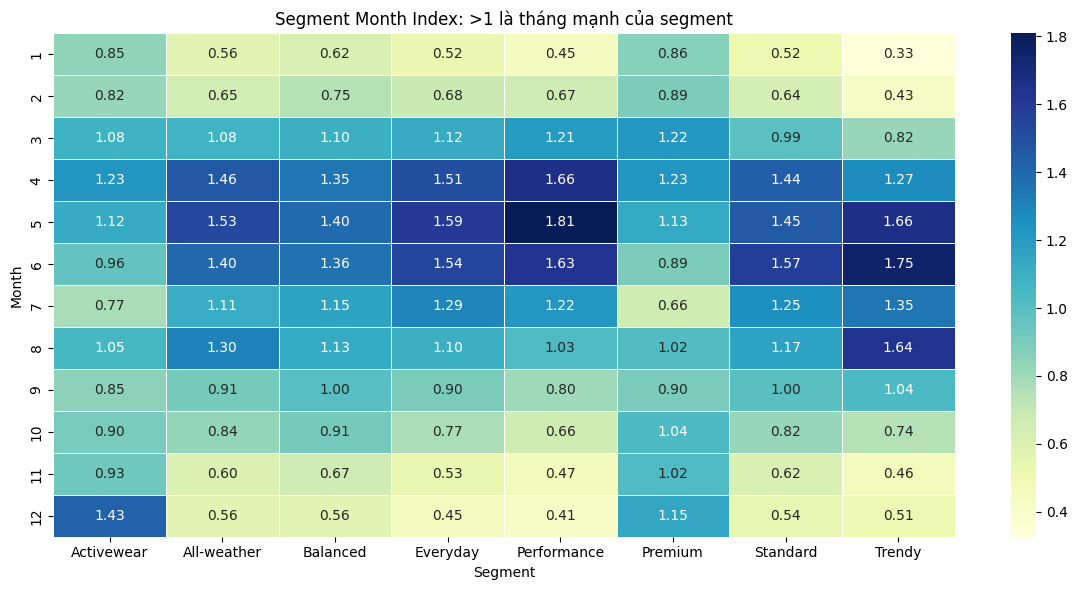

In [47]:
# ============================================================
# COMPACT SEGMENT ANALYSIS
# Phân tích Trendy / Everyday / Balanced ngắn gọn
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

DATA_DIR = "/kaggle/input/competitions/datathon-2026-round-1/"

orders = pd.read_csv(os.path.join(DATA_DIR, "orders.csv"), low_memory=False)
order_items = pd.read_csv(os.path.join(DATA_DIR, "order_items.csv"), low_memory=False)
products = pd.read_csv(os.path.join(DATA_DIR, "products.csv"), low_memory=False)
sales = pd.read_csv(os.path.join(DATA_DIR, "sales.csv"), low_memory=False)

orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")
sales["Date"] = pd.to_datetime(sales["Date"], errors="coerce")

# Merge transaction data
trans = (
    order_items
    .merge(orders[["order_id", "order_date"]], on="order_id", how="left")
    .merge(products[["product_id", "category", "segment", "cogs"]], on="product_id", how="left")
)

trans["Date"] = pd.to_datetime(trans["order_date"], errors="coerce")
trans = trans.dropna(subset=["Date", "category", "segment"]).copy()

for col in ["quantity", "unit_price", "discount_amount", "cogs"]:
    if col in trans.columns:
        trans[col] = pd.to_numeric(trans[col], errors="coerce").fillna(0)

trans["Revenue"] = trans["quantity"] * trans["unit_price"]
trans["COGS"] = trans["quantity"] * trans["cogs"]
trans["Profit"] = trans["Revenue"] - trans["COGS"]
trans["Discount"] = trans["discount_amount"] if "discount_amount" in trans.columns else 0

trans["year"] = trans["Date"].dt.year
trans["month"] = trans["Date"].dt.month
trans["segment"] = trans["segment"].astype(str).str.strip()
trans["category"] = trans["category"].astype(str).str.strip()

trans = trans[
    (trans["Date"] >= "2012-07-04") &
    (trans["Date"] <= "2022-12-31")
].copy()

print("Segments:", sorted(trans["segment"].unique()))


# ============================================================
# 1. Check khớp sales.csv
# ============================================================

daily_check = (
    trans.groupby("Date", as_index=False)
    .agg(
        revenue_items=("Revenue", "sum"),
        cogs_items=("COGS", "sum")
    )
)

check = sales.merge(daily_check, on="Date", how="left")

print("MAE Revenue check:", (check["Revenue"] - check["revenue_items"]).abs().mean())
print("MAE COGS check   :", (check["COGS"] - check["cogs_items"]).abs().mean())


# ============================================================
# 2. Segment Summary
# ============================================================

seg_summary = (
    trans.groupby("segment", as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        COGS=("COGS", "sum"),
        Profit=("Profit", "sum"),
        Discount=("Discount", "sum"),
        Units=("quantity", "sum"),
        Orders=("order_id", "nunique")
    )
)

seg_summary["Revenue_Share"] = seg_summary["Revenue"] / seg_summary["Revenue"].sum()
seg_summary["COGS_Revenue_Ratio"] = seg_summary["COGS"] / seg_summary["Revenue"]
seg_summary["Gross_Margin"] = seg_summary["Profit"] / seg_summary["Revenue"]
seg_summary["Discount_Profit_Ratio"] = seg_summary["Discount"] / seg_summary["Profit"]

seg_summary = seg_summary.sort_values("Revenue", ascending=False)

display(
    seg_summary.style.format({
        "Revenue": "{:,.2f}",
        "COGS": "{:,.2f}",
        "Profit": "{:,.2f}",
        "Discount": "{:,.2f}",
        "Units": "{:,.0f}",
        "Orders": "{:,.0f}",
        "Revenue_Share": "{:.2%}",
        "COGS_Revenue_Ratio": "{:.2%}",
        "Gross_Margin": "{:.2%}",
        "Discount_Profit_Ratio": "{:.3f}",
    }).background_gradient(
        subset=["Revenue_Share", "Gross_Margin", "Discount_Profit_Ratio"],
        cmap="YlGnBu"
    )
)


# ============================================================
# 3. Q2 Segment Summary
# ============================================================

q2 = trans[trans["month"].isin([4, 5, 6])].copy()

q2_seg = (
    q2.groupby("segment", as_index=False)
    .agg(
        Q2_Revenue=("Revenue", "sum"),
        Q2_COGS=("COGS", "sum"),
        Q2_Profit=("Profit", "sum"),
        Q2_Discount=("Discount", "sum"),
        Q2_Units=("quantity", "sum"),
        Q2_Orders=("order_id", "nunique")
    )
)

q2_seg["Q2_Revenue_Share"] = q2_seg["Q2_Revenue"] / q2_seg["Q2_Revenue"].sum()
q2_seg["Q2_COGS_Revenue_Ratio"] = q2_seg["Q2_COGS"] / q2_seg["Q2_Revenue"]
q2_seg["Q2_Gross_Margin"] = q2_seg["Q2_Profit"] / q2_seg["Q2_Revenue"]
q2_seg["Q2_Discount_Profit_Ratio"] = q2_seg["Q2_Discount"] / q2_seg["Q2_Profit"]

q2_seg = q2_seg.merge(
    seg_summary[["segment", "Revenue_Share"]],
    on="segment",
    how="left"
)

q2_seg["Q2_vs_Total_Lift"] = q2_seg["Q2_Revenue_Share"] / q2_seg["Revenue_Share"]

q2_seg = q2_seg.sort_values("Q2_Revenue", ascending=False)

display(
    q2_seg.style.format({
        "Q2_Revenue": "{:,.2f}",
        "Q2_COGS": "{:,.2f}",
        "Q2_Profit": "{:,.2f}",
        "Q2_Discount": "{:,.2f}",
        "Q2_Units": "{:,.0f}",
        "Q2_Orders": "{:,.0f}",
        "Q2_Revenue_Share": "{:.2%}",
        "Q2_COGS_Revenue_Ratio": "{:.2%}",
        "Q2_Gross_Margin": "{:.2%}",
        "Q2_Discount_Profit_Ratio": "{:.3f}",
        "Revenue_Share": "{:.2%}",
        "Q2_vs_Total_Lift": "{:.3f}",
    }).background_gradient(
        subset=["Q2_Revenue_Share", "Q2_vs_Total_Lift", "Q2_Gross_Margin"],
        cmap="YlGnBu"
    )
)


# ============================================================
# 4. Segment Month Index
# Index > 1: tháng đó mạnh hơn trung bình của segment
# ============================================================

seg_month = (
    trans.groupby(["segment", "month"], as_index=False)
    .agg(Revenue=("Revenue", "sum"))
)

seg_avg = (
    seg_month.groupby("segment", as_index=False)
    .agg(Avg_Month_Revenue=("Revenue", "mean"))
)

seg_month = seg_month.merge(seg_avg, on="segment", how="left")
seg_month["Segment_Month_Index"] = seg_month["Revenue"] / seg_month["Avg_Month_Revenue"]

seg_index_pivot = seg_month.pivot_table(
    index="month",
    columns="segment",
    values="Segment_Month_Index",
    fill_value=0
)

display(
    seg_index_pivot.style.format("{:.3f}")
    .background_gradient(cmap="YlGnBu")
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    seg_index_pivot,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5
)
plt.title("Segment Month Index: >1 là tháng mạnh của segment")
plt.xlabel("Segment")
plt.ylabel("Month")
plt.tight_layout()
plt.show()

### V35

In [48]:
# ============================================================
# V35 — Segment Redistribution đúng insight
# Base: submission_v33_stockout_q2_mid.csv
#
# Insight từ segment analysis:
# - Everyday: lớn nhất, Q2 lift > 1, margin tốt
# - Performance: Q2 lift mạnh nhất, month index tháng 4-6 rất cao
# - Balanced: lớn nhưng Q2 lift < 1, không boost mạnh
# - Trendy: Q2 mạnh nhưng share nhỏ
# ============================================================

import os
import numpy as np
import pandas as pd
from IPython.display import display

DATA_DIR = "/kaggle/input/competitions/datathon-2026-round-1/"
BEST_NOW = "submission_v33_stockout_q2_mid.csv"

best = pd.read_csv(BEST_NOW)
best["Date"] = pd.to_datetime(best["Date"])
best["month"] = best["Date"].dt.month
best["day"] = best["Date"].dt.day

orders = pd.read_csv(os.path.join(DATA_DIR, "orders.csv"), low_memory=False)
order_items = pd.read_csv(os.path.join(DATA_DIR, "order_items.csv"), low_memory=False)
products = pd.read_csv(os.path.join(DATA_DIR, "products.csv"), low_memory=False)

orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")

trans = (
    order_items
    .merge(orders[["order_id", "order_date"]], on="order_id", how="left")
    .merge(products[["product_id", "category", "segment", "cogs"]], on="product_id", how="left")
)

trans["Date"] = pd.to_datetime(trans["order_date"], errors="coerce")
trans = trans.dropna(subset=["Date", "segment"]).copy()

for col in ["quantity", "unit_price", "cogs"]:
    trans[col] = pd.to_numeric(trans[col], errors="coerce").fillna(0)

trans["Revenue"] = trans["quantity"] * trans["unit_price"]
trans["COGS"] = trans["quantity"] * trans["cogs"]

trans["year"] = trans["Date"].dt.year
trans["month"] = trans["Date"].dt.month
trans["day"] = trans["Date"].dt.day
trans["segment"] = trans["segment"].astype(str).str.strip()

trans = trans[
    (trans["Date"] >= "2012-07-04") &
    (trans["Date"] <= "2022-12-31")
].copy()

# ============================================================
# 1. Tạo peak profile theo segment trong Q2
# ============================================================

q2 = trans[trans["month"].isin([4, 5, 6])].copy()

seg_day = (
    q2.groupby(["year", "month", "day", "segment"], as_index=False)
    .agg(Revenue=("Revenue", "sum"))
)

seg_day_avg = (
    seg_day.groupby(["month", "day", "segment"], as_index=False)
    .agg(avg_revenue=("Revenue", "mean"))
)

seg_month_avg = (
    seg_day_avg.groupby(["month", "segment"], as_index=False)
    .agg(month_day_avg=("avg_revenue", "mean"))
)

seg_day_avg = seg_day_avg.merge(seg_month_avg, on=["month", "segment"], how="left")
seg_day_avg["day_index"] = seg_day_avg["avg_revenue"] / seg_day_avg["month_day_avg"]
seg_day_avg["peak_score"] = (seg_day_avg["day_index"] - 1).clip(lower=0)

def norm_peak(g):
    mx = g["peak_score"].max()
    g["peak_norm"] = 0 if mx <= 0 else g["peak_score"] / mx
    return g

seg_day_avg = (
    seg_day_avg
    .groupby(["month", "segment"], group_keys=False)
    .apply(norm_peak)
)

# Segment share trong từng tháng Q2
seg_month_share = (
    q2.groupby(["month", "segment"], as_index=False)
    .agg(Revenue=("Revenue", "sum"))
)

month_total = (
    seg_month_share.groupby("month", as_index=False)
    .agg(Month_Revenue=("Revenue", "sum"))
)

seg_month_share = seg_month_share.merge(month_total, on="month", how="left")
seg_month_share["segment_share"] = seg_month_share["Revenue"] / seg_month_share["Month_Revenue"]

seg_day_avg = seg_day_avg.merge(
    seg_month_share[["month", "segment", "segment_share"]],
    on=["month", "segment"],
    how="left"
)

# ============================================================
# 2. Hàm tạo redistribution
# ============================================================

def make_segment_redistribution(name, boost_map):
    sub = best[["Date", "Revenue", "COGS"]].copy()
    sub["month"] = best["month"]
    sub["day"] = best["day"]

    raw_mult = np.ones(len(sub))

    for i, row in sub.iterrows():
        m = row["month"]
        d = row["day"]

        if m not in [4, 5, 6]:
            continue

        profile = seg_day_avg[
            (seg_day_avg["month"] == m) &
            (seg_day_avg["day"] == d)
        ]

        extra = 0.0

        for seg, boost in boost_map.items():
            p = profile[profile["segment"] == seg]

            if len(p) == 0:
                continue

            share = float(p["segment_share"].iloc[0])
            peak = float(p["peak_norm"].iloc[0])

            extra += share * boost * peak

        raw_mult[i] = 1 + extra

    sub["raw_mult"] = raw_mult

    # Giữ tổng từng tháng 4/5/6 gần như không đổi
    for m in [4, 5, 6]:
        mask = sub["month"] == m
        old_total = sub.loc[mask, "Revenue"].sum()
        new_total = (sub.loc[mask, "Revenue"] * sub.loc[mask, "raw_mult"]).sum()

        if new_total > 0:
            correction = old_total / new_total
        else:
            correction = 1.0

        sub.loc[mask, "raw_mult"] *= correction

    base_ratio = np.where(
        best["Revenue"] > 0,
        best["COGS"] / best["Revenue"],
        0.85
    )
    base_ratio = np.clip(base_ratio, 0, 0.98)

    sub["Revenue"] = sub["Revenue"] * sub["raw_mult"]
    sub["COGS"] = sub["Revenue"] * base_ratio

    sub["Revenue"] = sub["Revenue"].clip(lower=0).round(2)
    sub["COGS"] = sub["COGS"].clip(lower=0).round(2)
    sub["COGS"] = np.minimum(sub["COGS"], sub["Revenue"] * 0.98)

    out = sub[["Date", "Revenue", "COGS"]].copy()

    filename = f"submission_v35_segment_{name}.csv"
    out.to_csv(filename, index=False)
    print("Saved:", filename)

    return filename

# ============================================================
# 3. Candidate settings dựa trên phân tích segment
# ============================================================

settings = {
    # An toàn nhất: Performance chính, Everyday phụ
    "performance_everyday_light": {
        "Performance": 0.040,
        "Everyday": 0.020,
    },

    # Mạnh hơn một chút
    "performance_everyday_mid": {
        "Performance": 0.060,
        "Everyday": 0.030,
    },

    # Tập trung Performance vì Q2 lift mạnh nhất
    "performance_focus": {
        "Performance": 0.080,
    },

    # Everyday lớn nhất, test riêng
    "everyday_focus": {
        "Everyday": 0.050,
    },

    # Có thêm Trendy nhẹ, vì Trendy tháng 5-6 rất mạnh nhưng share nhỏ
    "performance_everyday_trendy": {
        "Performance": 0.055,
        "Everyday": 0.025,
        "Trendy": 0.040,
    },

    # Liều hơn nhưng vẫn giữ tổng tháng
    "performance_everyday_yolo": {
        "Performance": 0.090,
        "Everyday": 0.045,
        "Trendy": 0.060,
    },
}

created_files = []

for name, boost_map in settings.items():
    created_files.append(make_segment_redistribution(name, boost_map))

# ============================================================
# 4. Compare với current best
# ============================================================

rows = []

for f in [BEST_NOW] + created_files:
    temp = pd.read_csv(f)
    temp["Date"] = pd.to_datetime(temp["Date"])
    temp["month"] = temp["Date"].dt.month

    merged = best[["Date", "Revenue", "COGS"]].merge(
        temp[["Date", "Revenue", "COGS"]],
        on="Date",
        suffixes=("_best", "_new")
    )

    q2_rev = temp[temp["month"].isin([4, 5, 6])]["Revenue"].sum()

    rows.append({
        "file": f,
        "Revenue_sum": temp["Revenue"].sum(),
        "COGS_sum": temp["COGS"].sum(),
        "COGS/Revenue_mean": (temp["COGS"] / temp["Revenue"]).replace([np.inf, -np.inf], np.nan).mean(),
        "Q2_Revenue_sum": q2_rev,
        "Q2_Revenue_share": q2_rev / temp["Revenue"].sum(),
        "Revenue_sum_diff_vs_best": temp["Revenue"].sum() - best["Revenue"].sum(),
        "Mean_abs_daily_Revenue_diff": (merged["Revenue_new"] - merged["Revenue_best"]).abs().mean(),
        "Max_abs_daily_Revenue_diff": (merged["Revenue_new"] - merged["Revenue_best"]).abs().max(),
    })

summary = pd.DataFrame(rows)

display(
    summary.style.format({
        "Revenue_sum": "{:,.2f}",
        "COGS_sum": "{:,.2f}",
        "COGS/Revenue_mean": "{:.4f}",
        "Q2_Revenue_sum": "{:,.2f}",
        "Q2_Revenue_share": "{:.3%}",
        "Revenue_sum_diff_vs_best": "{:,.2f}",
        "Mean_abs_daily_Revenue_diff": "{:,.2f}",
        "Max_abs_daily_Revenue_diff": "{:,.2f}",
    })
)

print("\nSubmit order đề xuất:")
print("1. submission_v35_segment_performance_everyday_light.csv")
print("2. Nếu tốt hơn: submission_v35_segment_performance_everyday_mid.csv")
print("3. Nếu light tệ: thử submission_v35_segment_performance_focus.csv")

Saved: submission_v35_segment_performance_everyday_light.csv
Saved: submission_v35_segment_performance_everyday_mid.csv
Saved: submission_v35_segment_performance_focus.csv
Saved: submission_v35_segment_everyday_focus.csv
Saved: submission_v35_segment_performance_everyday_trendy.csv
Saved: submission_v35_segment_performance_everyday_yolo.csv


,file,Revenue_sum,COGS_sum,COGS/Revenue_mean,Q2_Revenue_sum,Q2_Revenue_share,Revenue_sum_diff_vs_best,Mean_abs_daily_Revenue_diff,Max_abs_daily_Revenue_diff
0,submission_v33_stockout_q2_mid.csv,"2,344,691,784.37","1,984,173,039.99",0.8504,"1,155,571,362.47",49.285%,0.00,0.00,0.00
1,submission_v35_segment_performance_everyday_light.csv,"2,344,691,784.35","1,984,128,708.55",0.8504,"1,155,571,362.45",49.285%,-0.02,"7,917.09","182,521.93"
2,submission_v35_segment_performance_everyday_mid.csv,"2,344,691,784.40","1,984,106,636.71",0.8504,"1,155,571,362.50",49.285%,0.03,"11,858.68","273,408.80"
3,submission_v35_segment_performance_focus.csv,"2,344,691,784.38","1,984,131,066.78",0.8504,"1,155,571,362.48",49.285%,0.01,"7,992.99","187,924.71"
4,submission_v35_segment_everyday_focus.csv,"2,344,691,784.36","1,984,114,719.75",0.8504,"1,155,571,362.46",49.285%,-0.01,"9,794.49","221,247.41"
5,submission_v35_segment_performance_everyday_trendy.csv,"2,344,691,784.41","1,984,111,102.24",0.8504,"1,155,571,362.51",49.285%,0.04,"10,837.02","249,166.57"
6,submission_v35_segment_performance_everyday_yolo.csv,"2,344,691,784.34","1,984,067,746.64",0.8504,"1,155,571,362.44",49.285%,-0.03,"18,421.82","423,404.79"



Submit order đề xuất:
1. submission_v35_segment_performance_everyday_light.csv
2. Nếu tốt hơn: submission_v35_segment_performance_everyday_mid.csv
3. Nếu light tệ: thử submission_v35_segment_performance_focus.csv


In [52]:
# ============================================================
# V37 — Latent Demand Proxy: Web Traffic + Orders + Stockout
#
# Current best:
# submission_v33_stockout_q2_mid.csv
#
# Ý tưởng:
# - q2_mid đang best => Q2 latent demand đúng hướng.
# - q2_strong tệ => không boost Q2 bừa thêm.
# - V37 tìm ngày có demand proxy cao:
#     web traffic cao + orders cao nhưng revenue chưa tương xứng
# - Sau đó boost đúng các ngày latent-demand cao trong Q2.
# ============================================================

import os
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

DATA_DIR = "/kaggle/input/competitions/datathon-2026-round-1/"

BEST_NOW = "submission_v33_stockout_q2_mid.csv"

best = pd.read_csv(BEST_NOW)
best["Date"] = pd.to_datetime(best["Date"])
best["year"] = best["Date"].dt.year
best["month"] = best["Date"].dt.month
best["day"] = best["Date"].dt.day
best["dayofweek"] = best["Date"].dt.dayofweek

print("Current best:", BEST_NOW)


# ============================================================
# 1. Load data
# ============================================================

sales = pd.read_csv(os.path.join(DATA_DIR, "sales.csv"), low_memory=False)
orders = pd.read_csv(os.path.join(DATA_DIR, "orders.csv"), low_memory=False)
web = pd.read_csv(os.path.join(DATA_DIR, "web_traffic.csv"), low_memory=False)
inventory = pd.read_csv(os.path.join(DATA_DIR, "inventory.csv"), low_memory=False)

sales["Date"] = pd.to_datetime(sales["Date"], errors="coerce")
orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")


# ============================================================
# 2. Web traffic proxy
# Tự tìm cột date và numeric columns
# ============================================================

web_cols_lower = {c.lower(): c for c in web.columns}

date_candidates = ["date", "traffic_date", "visit_date", "snapshot_date"]
web_date_col = None

for c in date_candidates:
    if c in web_cols_lower:
        web_date_col = web_cols_lower[c]
        break

if web_date_col is None:
    raise ValueError(f"Không tìm thấy cột date trong web_traffic.csv. Columns: {web.columns.tolist()}")

web["Date"] = pd.to_datetime(web[web_date_col], errors="coerce")

numeric_cols = []
for c in web.columns:
    if c == web_date_col or c == "Date":
        continue
    if pd.api.types.is_numeric_dtype(web[c]):
        numeric_cols.append(c)

print("Web date col:", web_date_col)
print("Web numeric cols:", numeric_cols)

if len(numeric_cols) == 0:
    raise ValueError("web_traffic.csv không có cột numeric để tạo traffic proxy.")

web_daily = web[["Date"] + numeric_cols].copy()
web_daily = web_daily.dropna(subset=["Date"])

for c in numeric_cols:
    web_daily[c] = pd.to_numeric(web_daily[c], errors="coerce").fillna(0)

# Aggregate nếu có nhiều dòng/ngày
web_daily = (
    web_daily
    .groupby("Date", as_index=False)[numeric_cols]
    .sum()
)

# Tạo traffic_proxy bằng rank-normalized mean để tránh một cột scale quá lớn
for c in numeric_cols:
    web_daily[c + "_rank"] = web_daily[c].rank(pct=True)

rank_cols = [c + "_rank" for c in numeric_cols]
web_daily["traffic_proxy"] = web_daily[rank_cols].mean(axis=1)


# ============================================================
# 3. Orders proxy
# ============================================================

orders_daily = (
    orders
    .dropna(subset=["order_date"])
    .groupby("order_date", as_index=False)
    .agg(
        order_count=("order_id", "nunique"),
        customer_count=("customer_id", "nunique") if "customer_id" in orders.columns else ("order_id", "nunique")
    )
    .rename(columns={"order_date": "Date"})
)

orders_daily["Date"] = pd.to_datetime(orders_daily["Date"])


# ============================================================
# 4. Historical daily table
# ============================================================

hist = (
    sales[["Date", "Revenue", "COGS"]]
    .merge(web_daily[["Date", "traffic_proxy"]], on="Date", how="left")
    .merge(orders_daily[["Date", "order_count", "customer_count"]], on="Date", how="left")
)

hist["traffic_proxy"] = hist["traffic_proxy"].fillna(hist["traffic_proxy"].median())
hist["order_count"] = hist["order_count"].fillna(0)
hist["customer_count"] = hist["customer_count"].fillna(0)

hist["year"] = hist["Date"].dt.year
hist["month"] = hist["Date"].dt.month
hist["day"] = hist["Date"].dt.day
hist["dayofweek"] = hist["Date"].dt.dayofweek

# Web traffic bắt đầu từ 2013 nên dùng 2013-2022
hist = hist[
    (hist["Date"] >= "2013-01-01") &
    (hist["Date"] <= "2022-12-31")
].copy()

print("Historical proxy data:", hist.shape)
display(hist.head())


# ============================================================
# 5. Chuẩn hóa trong từng year-month
# Index > 1 nghĩa là cao hơn trung bình tháng đó
# ============================================================

def add_month_index(df, col):
    monthly_mean = df.groupby(["year", "month"])[col].transform("mean")
    return df[col] / monthly_mean.replace(0, np.nan)

hist["revenue_idx"] = add_month_index(hist, "Revenue")
hist["traffic_idx"] = add_month_index(hist, "traffic_proxy")
hist["order_idx"] = add_month_index(hist, "order_count")
hist["customer_idx"] = add_month_index(hist, "customer_count")

for c in ["revenue_idx", "traffic_idx", "order_idx", "customer_idx"]:
    hist[c] = hist[c].replace([np.inf, -np.inf], np.nan).fillna(1.0)
    hist[c] = hist[c].clip(0, 3)

# Demand proxy: traffic/orders cao
hist["demand_proxy_idx"] = (
    0.50 * hist["traffic_idx"] +
    0.35 * hist["order_idx"] +
    0.15 * hist["customer_idx"]
)

# Latent gap: demand proxy cao hơn revenue thực tế
hist["latent_gap"] = (hist["demand_proxy_idx"] - hist["revenue_idx"]).clip(lower=0)

# Làm mượt nhẹ: nếu revenue cũng rất cao thì vẫn cho tín hiệu nhưng nhỏ hơn
hist["latent_score_raw"] = hist["latent_gap"] * hist["demand_proxy_idx"]

# Winsorize để tránh vài ngày outlier quá mạnh
p99 = hist["latent_score_raw"].quantile(0.99)
hist["latent_score_raw"] = hist["latent_score_raw"].clip(upper=p99)


# ============================================================
# 6. Stockout monthly pressure từ inventory
# ============================================================

inventory["snapshot_date"] = pd.to_datetime(inventory["snapshot_date"], errors="coerce")
inventory["month"] = inventory["snapshot_date"].dt.month

for col in ["stockout_days", "stockout_flag", "fill_rate", "sell_through_rate", "days_of_supply"]:
    if col in inventory.columns:
        inventory[col] = pd.to_numeric(inventory[col], errors="coerce")

def minmax(s):
    s = s.astype(float)
    if s.max() == s.min():
        return s * 0
    return (s - s.min()) / (s.max() - s.min())

needed_inv_cols = ["stockout_days", "stockout_flag", "fill_rate", "sell_through_rate"]
for c in needed_inv_cols:
    if c not in inventory.columns:
        inventory[c] = np.nan

inv_month = (
    inventory
    .groupby("month", as_index=False)
    .agg(
        stockout_days=("stockout_days", "mean"),
        stockout_flag=("stockout_flag", "mean"),
        fill_rate=("fill_rate", "mean"),
        sell_through_rate=("sell_through_rate", "mean")
    )
)

inv_month["fill_gap"] = (1 - inv_month["fill_rate"]).clip(lower=0)

inv_month["stockout_days_norm"] = minmax(inv_month["stockout_days"].fillna(0))
inv_month["stockout_flag_norm"] = minmax(inv_month["stockout_flag"].fillna(0))
inv_month["fill_gap_norm"] = minmax(inv_month["fill_gap"].fillna(0))
inv_month["sell_through_norm"] = minmax(inv_month["sell_through_rate"].fillna(0))

inv_month["stockout_pressure"] = (
    0.35 * inv_month["stockout_days_norm"] +
    0.25 * inv_month["stockout_flag_norm"] +
    0.25 * inv_month["fill_gap_norm"] +
    0.15 * inv_month["sell_through_norm"]
)

mx = inv_month["stockout_pressure"].max()
if mx > 0:
    inv_month["stockout_pressure_norm"] = inv_month["stockout_pressure"] / mx
else:
    inv_month["stockout_pressure_norm"] = 0

print("Monthly stockout pressure:")
display(
    inv_month[["month", "stockout_pressure_norm"]]
    .style.format({"stockout_pressure_norm": "{:.3f}"})
    .background_gradient(subset=["stockout_pressure_norm"], cmap="YlOrRd")
)

stockout_map = dict(zip(inv_month["month"], inv_month["stockout_pressure_norm"]))


# ============================================================
# 7. Build latent profile theo month-day
# ============================================================

latent_profile = (
    hist
    .groupby(["month", "day"], as_index=False)
    .agg(
        latent_score=("latent_score_raw", "mean"),
        demand_proxy_idx=("demand_proxy_idx", "mean"),
        revenue_idx=("revenue_idx", "mean")
    )
)

# Normalize latent_score trong từng tháng về 0..1
def normalize_month(g):
    mx = g["latent_score"].max()
    if mx <= 0:
        g["latent_norm"] = 0
    else:
        g["latent_norm"] = g["latent_score"] / mx
    return g

latent_profile = (
    latent_profile
    .groupby("month", group_keys=False)
    .apply(normalize_month)
)

print("Top latent demand days historically:")
display(
    latent_profile
    .sort_values("latent_norm", ascending=False)
    .head(30)
    .style.format({
        "latent_score": "{:.4f}",
        "latent_norm": "{:.3f}",
        "demand_proxy_idx": "{:.3f}",
        "revenue_idx": "{:.3f}",
    })
)


# ============================================================
# 8. Merge latent profile vào forecast dates
# ============================================================

test_signal = best[["Date", "year", "month", "day"]].merge(
    latent_profile[["month", "day", "latent_norm"]],
    on=["month", "day"],
    how="left"
)

test_signal["latent_norm"] = test_signal["latent_norm"].fillna(0.0)
test_signal["stockout_pressure_norm"] = test_signal["month"].map(stockout_map).fillna(0.0)

# Chỉ dùng Q2 là chính vì các hướng ngoài Q2 đã tệ
test_signal["q2_flag"] = test_signal["month"].isin([4, 5, 6]).astype(int)

display(test_signal.head())


# ============================================================
# 9. Generate V37 variants
# ============================================================

base_ratio = np.where(
    best["Revenue"] > 0,
    best["COGS"] / best["Revenue"],
    0.85
)
base_ratio = np.clip(base_ratio, 0, 0.98)

def make_v37(name, base_extra, latent_weight, stockout_weight, q2_only=True, keep_month_total=False, year2024_extra=0.0):
    sub = best[["Date", "Revenue", "COGS"]].copy()

    latent = test_signal["latent_norm"].values
    stockout = test_signal["stockout_pressure_norm"].values
    months = test_signal["month"].values
    years = test_signal["year"].values

    mult = np.ones(len(sub))

    for i in range(len(sub)):
        m = months[i]

        if q2_only and m not in [4, 5, 6]:
            continue

        signal = (
            base_extra +
            latent_weight * latent[i] +
            stockout_weight * latent[i] * stockout[i]
        )

        if years[i] == 2024 and m in [4, 5, 6]:
            signal += year2024_extra

        mult[i] = 1 + signal

    sub["mult"] = mult

    # Optional: chỉ redistribute trong từng tháng, không đổi tổng tháng
    if keep_month_total:
        sub["month"] = months

        for m in [4, 5, 6]:
            mask = sub["month"] == m
            old_total = sub.loc[mask, "Revenue"].sum()
            new_total = (sub.loc[mask, "Revenue"] * sub.loc[mask, "mult"]).sum()

            correction = old_total / new_total if new_total > 0 else 1.0
            sub.loc[mask, "mult"] *= correction

    sub["Revenue"] = sub["Revenue"] * sub["mult"]
    sub["COGS"] = sub["Revenue"] * base_ratio

    sub["Revenue"] = sub["Revenue"].clip(lower=0)
    sub["COGS"] = sub["COGS"].clip(lower=0)
    sub["COGS"] = np.minimum(sub["COGS"], sub["Revenue"] * 0.98)

    sub["Revenue"] = sub["Revenue"].round(2)
    sub["COGS"] = sub["COGS"].round(2)

    out = sub[["Date", "Revenue", "COGS"]].copy()

    filename = f"submission_v37_latent_{name}.csv"
    out.to_csv(filename, index=False)
    print("Saved:", filename)

    return filename


created_files = []

# Nhóm A: redistribute daily shape, giữ tổng tháng
created_files.append(make_v37(
    name="redistribute_light",
    base_extra=0.000,
    latent_weight=0.050,
    stockout_weight=0.050,
    q2_only=True,
    keep_month_total=True
))

created_files.append(make_v37(
    name="redistribute_mid",
    base_extra=0.000,
    latent_weight=0.080,
    stockout_weight=0.080,
    q2_only=True,
    keep_month_total=True
))

# Nhóm B: boost latent days trong Q2, có tăng tổng nhẹ
created_files.append(make_v37(
    name="q2_latent_light",
    base_extra=0.000,
    latent_weight=0.015,
    stockout_weight=0.020,
    q2_only=True,
    keep_month_total=False
))

created_files.append(make_v37(
    name="q2_latent_mid",
    base_extra=0.002,
    latent_weight=0.025,
    stockout_weight=0.035,
    q2_only=True,
    keep_month_total=False
))

created_files.append(make_v37(
    name="q2_latent_strong",
    base_extra=0.005,
    latent_weight=0.040,
    stockout_weight=0.050,
    q2_only=True,
    keep_month_total=False
))

# Nhóm C: 2024 extra vì test 2024 có thể thiếu mạnh hơn
created_files.append(make_v37(
    name="q2_latent_2024",
    base_extra=0.001,
    latent_weight=0.020,
    stockout_weight=0.030,
    q2_only=True,
    keep_month_total=False,
    year2024_extra=0.008
))

# Nhóm D: cực liều, chỉ thử nếu các bản trên tốt
created_files.append(make_v37(
    name="q2_latent_yolo",
    base_extra=0.006,
    latent_weight=0.055,
    stockout_weight=0.075,
    q2_only=True,
    keep_month_total=False
))


# ============================================================
# 10. Compare with current best
# ============================================================

rows = []

for f in [BEST_NOW] + created_files:
    temp = pd.read_csv(f)
    temp["Date"] = pd.to_datetime(temp["Date"])
    temp["year"] = temp["Date"].dt.year
    temp["month"] = temp["Date"].dt.month

    merged = best[["Date", "Revenue", "COGS"]].merge(
        temp[["Date", "Revenue", "COGS"]],
        on="Date",
        suffixes=("_best", "_new")
    )

    q2_rev = temp[temp["month"].isin([4, 5, 6])]["Revenue"].sum()
    q2_2023 = temp[(temp["year"] == 2023) & (temp["month"].isin([4, 5, 6]))]["Revenue"].sum()
    q2_2024 = temp[(temp["year"] == 2024) & (temp["month"].isin([4, 5, 6]))]["Revenue"].sum()

    rows.append({
        "file": f,
        "Revenue_sum": temp["Revenue"].sum(),
        "COGS_sum": temp["COGS"].sum(),
        "COGS/Revenue_mean": (temp["COGS"] / temp["Revenue"]).replace([np.inf, -np.inf], np.nan).mean(),
        "Q2_Revenue_sum": q2_rev,
        "Q2_2023_Revenue": q2_2023,
        "Q2_2024_Revenue": q2_2024,
        "Q2_Revenue_share": q2_rev / temp["Revenue"].sum(),
        "Revenue_sum_diff_vs_best": temp["Revenue"].sum() - best["Revenue"].sum(),
        "Revenue_sum_diff_pct_vs_best": temp["Revenue"].sum() / best["Revenue"].sum() - 1,
        "Mean_abs_daily_Revenue_diff": (merged["Revenue_new"] - merged["Revenue_best"]).abs().mean(),
        "Max_abs_daily_Revenue_diff": (merged["Revenue_new"] - merged["Revenue_best"]).abs().max(),
    })

summary = pd.DataFrame(rows)

display(
    summary.style.format({
        "Revenue_sum": "{:,.2f}",
        "COGS_sum": "{:,.2f}",
        "COGS/Revenue_mean": "{:.4f}",
        "Q2_Revenue_sum": "{:,.2f}",
        "Q2_2023_Revenue": "{:,.2f}",
        "Q2_2024_Revenue": "{:,.2f}",
        "Q2_Revenue_share": "{:.3%}",
        "Revenue_sum_diff_vs_best": "{:,.2f}",
        "Revenue_sum_diff_pct_vs_best": "{:.3%}",
        "Mean_abs_daily_Revenue_diff": "{:,.2f}",
        "Max_abs_daily_Revenue_diff": "{:,.2f}",
    })
)

print("\nCurrent best:", BEST_NOW)
print("Submit order đề xuất:")
print("1. submission_v37_latent_q2_latent_light.csv")
print("2. Nếu light tốt hơn: submission_v37_latent_q2_latent_mid.csv")
print("3. Nếu light tệ: thử submission_v37_latent_redistribute_light.csv")
print("4. q2_latent_yolo chỉ thử nếu mid/strong tiếp tục tốt.")

Current best: submission_v33_stockout_q2_mid.csv
Web date col: date
Web numeric cols: ['sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration_sec']
Historical proxy data: (3652, 10)


,Date,Revenue,COGS,traffic_proxy,order_count,customer_count,year,month,day,dayofweek
181,2013-01-01,5304546.99,4156070.20,0.156572,288,283,2013,1,1,1
182,2013-01-02,1606940.44,1237497.84,0.101506,47,47,2013,1,2,2
183,2013-01-03,2281680.01,1832133.02,0.215964,81,80,2013,1,3,3
184,2013-01-04,2376895.46,1940747.07,0.251479,83,82,2013,1,4,4
185,2013-01-05,2509462.77,1977027.71,0.225164,78,77,2013,1,5,5


Monthly stockout pressure:


,month,stockout_pressure_norm
0,1,0.000
1,2,0.189
2,3,0.373
3,4,1.000
4,5,0.742
5,6,0.603
6,7,0.245
7,8,0.567
8,9,0.292
9,10,0.290


Top latent demand days historically:


,month,day,latent_score,demand_proxy_idx,revenue_idx,latent_norm
334,11,30,0.2358,1.228,1.104,1.000
297,10,24,0.1566,1.057,0.944,1.000
248,9,5,0.1426,0.890,0.746,1.000
185,7,4,0.2354,0.656,0.313,1.000
2,1,3,0.2874,0.877,0.543,1.000
95,4,5,0.2308,0.809,0.524,1.000
62,3,3,0.2395,0.690,0.345,1.000
59,2,29,0.3211,0.866,0.497,1.000
337,12,3,0.2141,0.802,0.542,1.000
178,6,27,0.1490,1.050,0.924,1.000


,Date,year,month,day,latent_norm,stockout_pressure_norm,q2_flag
0,2023-01-01,2023,1,1,0.738852,0.0,0
1,2023-01-02,2023,1,2,0.837336,0.0,0
2,2023-01-03,2023,1,3,1.000000,0.0,0
3,2023-01-04,2023,1,4,0.763474,0.0,0
4,2023-01-05,2023,1,5,0.374363,0.0,0


Saved: submission_v37_latent_redistribute_light.csv
Saved: submission_v37_latent_redistribute_mid.csv
Saved: submission_v37_latent_q2_latent_light.csv
Saved: submission_v37_latent_q2_latent_mid.csv
Saved: submission_v37_latent_q2_latent_strong.csv
Saved: submission_v37_latent_q2_latent_2024.csv
Saved: submission_v37_latent_q2_latent_yolo.csv


,file,Revenue_sum,COGS_sum,COGS/Revenue_mean,Q2_Revenue_sum,Q2_2023_Revenue,Q2_2024_Revenue,Q2_Revenue_share,Revenue_sum_diff_vs_best,Revenue_sum_diff_pct_vs_best,Mean_abs_daily_Revenue_diff,Max_abs_daily_Revenue_diff
0,submission_v33_stockout_q2_mid.csv,"2,344,691,784.37","1,984,173,039.99",0.8504,"1,155,571,362.47","577,657,015.52","577,914,346.95",49.285%,0.00,0.000%,0.00,0.00
1,submission_v37_latent_redistribute_light.csv,"2,344,691,784.39","1,984,541,290.19",0.8504,"1,155,571,362.49","577,711,609.86","577,859,752.63",49.285%,0.02,0.000%,"37,847.68","391,505.93"
2,submission_v37_latent_redistribute_mid.csv,"2,344,691,784.46","1,984,753,706.06",0.8504,"1,155,571,362.56","577,743,245.88","577,828,116.68",49.285%,0.09,0.000%,"59,677.02","617,637.51"
3,submission_v37_latent_q2_latent_light.csv,"2,354,754,672.45","1,992,634,490.71",0.8504,"1,165,634,250.55","582,709,238.63","582,925,011.92",49.501%,"10,062,888.08",0.429%,"18,362.93","171,695.36"
4,submission_v37_latent_q2_latent_mid.csv,"2,364,194,845.44","2,000,542,279.20",0.8504,"1,175,074,423.54","587,443,780.12","587,630,643.42",49.703%,"19,503,061.07",0.832%,"35,589.53","305,224.63"
5,submission_v37_latent_q2_latent_strong.csv,"2,376,463,133.36","2,010,810,789.53",0.8504,"1,187,342,711.46","593,595,738.26","593,746,973.20",49.963%,"31,771,348.99",1.355%,"57,976.91","476,815.83"
6,submission_v37_latent_q2_latent_2024.csv,"2,364,728,730.85","2,000,944,736.25",0.8504,"1,175,608,308.95","585,393,127.46","590,215,181.49",49.714%,"20,036,946.48",0.855%,"36,563.77","276,611.77"
7,submission_v37_latent_q2_latent_yolo.csv,"2,388,942,907.05","2,021,290,746.69",0.8504,"1,199,822,485.15","599,858,854.44","599,963,630.71",50.224%,"44,251,122.68",1.887%,"80,750.22","673,989.98"



Current best: submission_v33_stockout_q2_mid.csv
Submit order đề xuất:
1. submission_v37_latent_q2_latent_light.csv
2. Nếu light tốt hơn: submission_v37_latent_q2_latent_mid.csv
3. Nếu light tệ: thử submission_v37_latent_redistribute_light.csv
4. q2_latent_yolo chỉ thử nếu mid/strong tiếp tục tốt.


# SO SÁNH

,file,Revenue_sum,Revenue_mean,Revenue_max,COGS_sum,COGS_mean,COGS/Revenue_mean
0,best,"2,250,048,142.10","4,105,927.27","13,147,678.97","1,906,288,396.81","3,478,628.46",0.8504
1,new,"2,220,973,882.75","4,052,872.05","11,476,152.06","1,883,351,090.86","3,436,772.06",0.8504


Revenue sum diff: -29,074,259.35
Revenue sum diff pct: -1.29%
Mean abs daily diff: 106,747.80
Max abs daily diff: 1,671,526.91


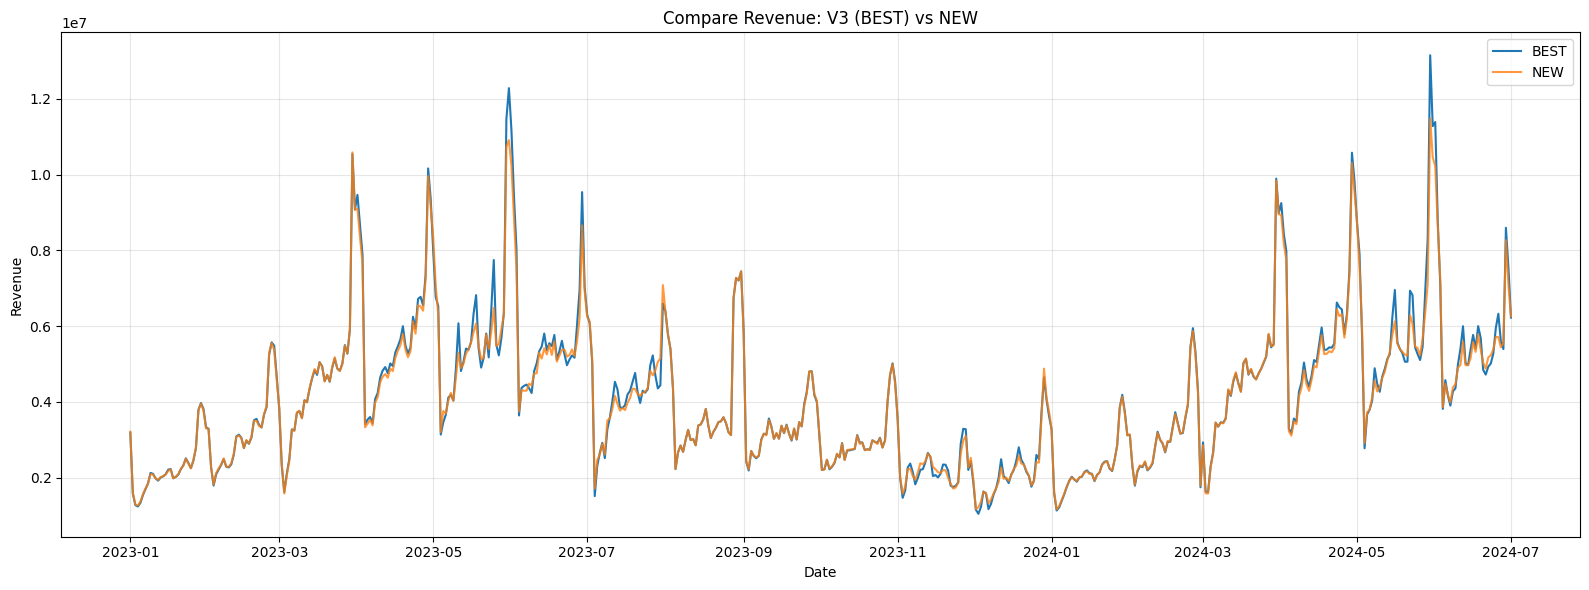


Top 15 ngày V6 lệch V4 nhiều nhất:


,Date,Revenue_v4,Revenue_v6,Revenue_diff,Revenue_diff_pct
515,2024-05-30 00:00:00,"13,147,678.97","11,476,152.06","-1,671,526.91",-12.71%
150,2023-05-31 00:00:00,"12,279,992.84","10,906,802.27","-1,373,190.57",-11.18%
144,2023-05-25 00:00:00,"7,744,521.15","6,482,165.15","-1,262,356.00",-16.30%
514,2024-05-29 00:00:00,"8,286,165.81","7,105,977.90","-1,180,187.91",-14.24%
517,2024-06-01 00:00:00,"11,385,563.84","10,218,027.67","-1,167,536.17",-10.25%
151,2023-06-01 00:00:00,"11,170,457.25","10,230,294.54","-940,162.71",-8.42%
179,2023-06-29 00:00:00,"9,536,138.37","8,658,455.05","-877,683.32",-9.20%
501,2024-05-16 00:00:00,"6,952,337.14","6,123,804.75","-828,532.39",-11.92%
516,2024-05-31 00:00:00,"11,276,968.73","10,456,910.67","-820,058.06",-7.27%
130,2023-05-11 00:00:00,"6,073,701.02","5,296,009.63","-777,691.39",-12.80%


In [49]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_FILE = "submission_v24_cat_month_streetwear_heavy.csv"
NEW_FILE = "submission.csv"   

if not os.path.exists(BASE_FILE):
    raise FileNotFoundError("Chưa có submission_v4_robust.csv để so sánh.")

base = pd.read_csv(BASE_FILE)
new = pd.read_csv(NEW_FILE)

base["Date"] = pd.to_datetime(base["Date"])
new["Date"] = pd.to_datetime(new["Date"])

merged = base.merge(new, on="Date", suffixes=("_v4", "_v6"))

merged["Revenue_diff"] = merged["Revenue_v6"] - merged["Revenue_v4"]
merged["Revenue_diff_pct"] = merged["Revenue_diff"] / merged["Revenue_v4"]

merged["COGS_diff"] = merged["COGS_v6"] - merged["COGS_v4"]
merged["COGS_diff_pct"] = merged["COGS_diff"] / merged["COGS_v4"]

summary = pd.DataFrame([
    {
        "file": "best",
        "Revenue_sum": merged["Revenue_v4"].sum(),
        "Revenue_mean": merged["Revenue_v4"].mean(),
        "Revenue_max": merged["Revenue_v4"].max(),
        "COGS_sum": merged["COGS_v4"].sum(),
        "COGS_mean": merged["COGS_v4"].mean(),
        "COGS/Revenue_mean": (merged["COGS_v4"] / merged["Revenue_v4"]).mean(),
    },
    {
        "file": "new",
        "Revenue_sum": merged["Revenue_v6"].sum(),
        "Revenue_mean": merged["Revenue_v6"].mean(),
        "Revenue_max": merged["Revenue_v6"].max(),
        "COGS_sum": merged["COGS_v6"].sum(),
        "COGS_mean": merged["COGS_v6"].mean(),
        "COGS/Revenue_mean": (merged["COGS_v6"] / merged["Revenue_v6"]).mean(),
    }
])

display(
    summary.style.format({
        "Revenue_sum": "{:,.2f}",
        "Revenue_mean": "{:,.2f}",
        "Revenue_max": "{:,.2f}",
        "COGS_sum": "{:,.2f}",
        "COGS_mean": "{:,.2f}",
        "COGS/Revenue_mean": "{:.4f}",
    })
)

print("Revenue sum diff:", f"{merged['Revenue_diff'].sum():,.2f}")
print("Revenue sum diff pct:", f"{merged['Revenue_v6'].sum() / merged['Revenue_v4'].sum() - 1:.2%}")
print("Mean abs daily diff:", f"{merged['Revenue_diff'].abs().mean():,.2f}")
print("Max abs daily diff:", f"{merged['Revenue_diff'].abs().max():,.2f}")

plt.figure(figsize=(16, 6))
plt.plot(merged["Date"], merged["Revenue_v4"], label="BEST")
plt.plot(merged["Date"], merged["Revenue_v6"], label="NEW", alpha=0.8)
plt.title("Compare Revenue: V3 (BEST) vs NEW")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 15 ngày V6 lệch V4 nhiều nhất:")
display(
    merged[["Date", "Revenue_v4", "Revenue_v6", "Revenue_diff", "Revenue_diff_pct"]]
    .assign(abs_diff=lambda x: x["Revenue_diff"].abs())
    .sort_values("abs_diff", ascending=False)
    .drop(columns="abs_diff")
    .head(15)
    .style.format({
        "Revenue_v4": "{:,.2f}",
        "Revenue_v6": "{:,.2f}",
        "Revenue_diff": "{:,.2f}",
        "Revenue_diff_pct": "{:.2%}"
    })
)

# CHỌN FILE NỘP

In [50]:
import os
import pandas as pd
import numpy as np

DATA_DIR = "/kaggle/input/competitions/datathon-2026-round-1/"

# =========================
# CHỌN FILE MUỐN SUBMIT
# =========================

CHOSEN_FILE = "submission_v33_stockout_q2_strong.csv"

# Có thể đổi thành:
# CHOSEN_FILE = "submission_v5_upgraded.csv"
# CHOSEN_FILE = "/kaggle/input/datasets/qtinhhtobie/forecast-v4/submission_v4_robust.csv"


# =========================
# LOAD SAMPLE + PRED
# =========================

sample = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))

if not os.path.exists(CHOSEN_FILE):
    raise FileNotFoundError(f"Không tìm thấy file: {CHOSEN_FILE}")

pred = pd.read_csv(CHOSEN_FILE)

print("Chosen file:", CHOSEN_FILE)
print("Sample shape:", sample.shape)
print("Pred shape:", pred.shape)
print("Sample columns:", sample.columns.tolist())
print("Pred columns:", pred.columns.tolist())


# =========================
# FORMAT LẠI ĐÚNG SAMPLE
# =========================

required_cols = ["Date", "Revenue", "COGS"]

for col in required_cols:
    if col not in pred.columns:
        raise ValueError(f"File prediction thiếu cột: {col}")

sample["Date_key"] = pd.to_datetime(sample["Date"])
pred["Date_key"] = pd.to_datetime(pred["Date"])

submission = sample[["Date", "Date_key"]].merge(
    pred[["Date_key", "Revenue", "COGS"]],
    on="Date_key",
    how="left"
)

if submission[["Revenue", "COGS"]].isna().any().any():
    missing = submission[submission[["Revenue", "COGS"]].isna().any(axis=1)]
    display(missing.head())
    raise ValueError("Có Date trong sample_submission không có prediction.")

submission["Revenue"] = pd.to_numeric(submission["Revenue"], errors="coerce")
submission["COGS"] = pd.to_numeric(submission["COGS"], errors="coerce")

submission["Revenue"] = submission["Revenue"].clip(lower=0)
submission["COGS"] = submission["COGS"].clip(lower=0)

# Constraint an toàn
submission["COGS"] = np.minimum(submission["COGS"], submission["Revenue"] * 0.98)

submission["Revenue"] = submission["Revenue"].round(2)
submission["COGS"] = submission["COGS"].round(2)

submission = submission[["Date", "Revenue", "COGS"]]


# =========================
# CHECK FORMAT
# =========================

assert submission.shape == sample[["Date", "Revenue", "COGS"]].shape
assert submission.columns.tolist() == ["Date", "Revenue", "COGS"]
assert not submission.isna().any().any()
assert (submission["Revenue"] >= 0).all()
assert (submission["COGS"] >= 0).all()
assert (submission["COGS"] <= submission["Revenue"] * 0.9800001).all()

display(submission.head())
display(submission.tail())

print("Revenue sum:", f"{submission['Revenue'].sum():,.2f}")
print("COGS sum:", f"{submission['COGS'].sum():,.2f}")
print("COGS/Revenue mean:", f"{(submission['COGS'] / submission['Revenue']).mean():.4f}")


# =========================
# SAVE FINAL SUBMISSION
# =========================

submission.to_csv("submission.csv", index=False)

print("\nSaved final file: submission.csv")
print("Ready to submit.")

Chosen file: submission_v33_stockout_q2_strong.csv
Sample shape: (548, 3)
Pred shape: (548, 3)
Sample columns: ['Date', 'Revenue', 'COGS']
Pred columns: ['Date', 'Revenue', 'COGS']


,Date,Revenue,COGS
0,2023-01-01,3189212.52,2987600.70
1,2023-01-02,1578775.23,1355870.59
2,2023-01-03,1275577.44,1034977.73
3,2023-01-04,1238152.53,998087.06
4,2023-01-05,1333006.80,1086192.61


,Date,Revenue,COGS
543,2024-06-27,5935791.26,5523115.69
544,2024-06-28,5742905.44,5611290.39
545,2024-06-29,9708344.26,8765366.92
546,2024-06-30,8247754.02,7358753.97
547,2024-07-01,6223484.13,5522183.70


Revenue sum: 2,361,847,373.69
COGS sum: 1,998,399,091.84
COGS/Revenue mean: 0.8504

Saved final file: submission.csv
Ready to submit.


In [51]:
import pandas as pd
import numpy as np

FILE_A = "submission_v33_stockout_q2_strong.csv"
FILE_B = "submission_v33_stockout_q2_mid.csv"   # hoặc file OPTIMIZED_5 nếu tên khác

a = pd.read_csv(FILE_A)
b = pd.read_csv(FILE_B)

a["Date"] = pd.to_datetime(a["Date"])
b["Date"] = pd.to_datetime(b["Date"])

cmp = a.merge(b, on="Date", suffixes=("_A", "_B"))

cmp["Revenue_diff"] = cmp["Revenue_A"] - cmp["Revenue_B"]
cmp["COGS_diff"] = cmp["COGS_A"] - cmp["COGS_B"]

print("Mean abs Revenue diff:", cmp["Revenue_diff"].abs().mean())
print("Max abs Revenue diff :", cmp["Revenue_diff"].abs().max())
print("Mean abs COGS diff   :", cmp["COGS_diff"].abs().mean())
print("Max abs COGS diff    :", cmp["COGS_diff"].abs().max())

display(
    cmp.sort_values("Revenue_diff", key=lambda s: s.abs(), ascending=False)
    .head(20)
)

Mean abs Revenue diff: 31305.819927007313
Max abs Revenue diff : 243591.41000000015
Mean abs COGS diff   : 25959.948631386847
Max abs COGS diff    : 196513.26999999955


,Date,Revenue_A,COGS_A,Revenue_B,COGS_B,Revenue_diff,COGS_diff
484,2024-04-29,12788549.09,10316946.76,12544957.68,10120433.49,243591.41,196513.27
515,2024-05-30,16776594.80,13512915.52,16539645.37,13322061.67,236949.43,190853.85
118,2023-04-29,12287045.06,9954852.53,12053006.11,9765236.29,234038.95,189616.24
485,2024-04-30,11496903.62,9252713.72,11277914.98,9076471.55,218988.64,176242.17
150,2023-05-31,15408806.00,12304356.79,15191174.96,12130572.40,217631.04,173784.39
90,2023-04-01,11050410.66,9977543.77,10839926.65,9787495.32,210484.01,190048.45
119,2023-04-30,10955956.67,8788527.78,10747271.78,8621127.25,208684.89,167400.53
149,2023-05-30,14628265.51,11939706.21,14421658.68,11771072.08,206606.83,168634.13
456,2024-04-01,10796287.97,9795207.00,10590644.39,9608631.63,205643.58,186575.37
516,2024-05-31,14150221.90,10977974.30,13950366.86,10822923.48,199855.04,155050.82


## 12. Business Recommendations

Dựa trên các bảng và biểu đồ ở trên, nhóm đề xuất các hướng hành động sau:

### 1. Tối ưu danh mục sản phẩm theo Revenue và Gross Margin

Không chỉ nhìn vào category có Revenue cao nhất, cần so sánh thêm Gross Margin. Nếu một category có Revenue share lớn nhưng Gross Margin thấp, doanh nghiệp nên kiểm soát discount, tối ưu giá bán và cân nhắc bundle với nhóm sản phẩm có margin cao hơn.

### 2. Quản trị promotion theo ROI thay vì chỉ theo doanh thu

Promotion cần được đánh giá bằng:

```python
promo_roi = promo_profit / total_discount
```

Category nào có Promotion ROI thấp cần được kiểm tra lại vì discount có thể đang ăn mòn Gross Profit.

### 3. Giảm tác động tiêu cực của returns

Category có `Refund / Revenue` hoặc `Unit Return Rate` cao cần được kiểm tra lại về chất lượng sản phẩm, size, mô tả sản phẩm, kỳ vọng khách hàng và chính sách đổi trả.

### 4. Tối ưu tồn kho theo stockout và overstock

Category có Revenue cao nhưng stockout days lớn có thể đang mất doanh thu do thiếu hàng. Category có overstock cao nhưng sell-through thấp nên được tối ưu tồn kho hoặc xử lý bằng promotion có chọn lọc.

### 5. Tối ưu traffic source theo computed CVR

Nguồn traffic có sessions cao nhưng computed CVR thấp cần kiểm tra lại chất lượng traffic hoặc trải nghiệm chuyển đổi. Nguồn có CVR cao nhưng volume thấp có thể là kênh tiềm năng để mở rộng.

### 6. Sử dụng forecasting để hỗ trợ vận hành

Mô hình forecasting được đánh giá trên validation năm 2022 bằng MAE, RMSE và R². Kết quả dự báo có thể hỗ trợ lập kế hoạch tồn kho, chuẩn bị ngân sách marketing, dự kiến nhu cầu theo mùa và theo dõi rủi ro Revenue giảm trong các giai đoạn thấp điểm.

Lưu ý: các khuyến nghị cụ thể như cắt giảm bao nhiêu phần trăm tồn kho hoặc tăng bao nhiêu ngân sách marketing cần được quyết định dựa trên số liệu thực tế từ bảng KPI, không nên ghi cứng nếu chưa có kiểm chứng định lượng.